# 06 — Presentation Asset Builder (Refactored)

Goal:
- Build presentation-ready assets for Slide 02 (Executive Summary)
- Reuse Stage 03–05 outputs only
- Export a single executive-summary panel figure plus supporting tables and bullet text

Output assets:
- presentation_assets/figures/slide_02_executive_summary_panel.png
- presentation_assets/tables/slide_02_top_industries.csv
- presentation_assets/tables/slide_02_industry_company_anchors.csv
- presentation_assets/tables/slide_02_mechanism_summary.csv
- presentation_assets/tables/slide_02_adoption_drivers.csv
- presentation_assets/tables/slide_02_adoption_risks.csv
- presentation_assets/reports/slide_02_executive_summary_bullets.md
- presentation_assets/reports/slide_02_executive_summary_metrics.json

Design principle:
This slide is an evidence-led summary rather than the final industry-mapping slide.
Industries are inferred reproducibly from dominant document topics, while overall tone,
mechanisms, and adoption conditions are derived from row-level sentiment contexts.

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import json
import math
import re
import textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
pd.set_option('display.max_colwidth', 240)

In [3]:
# ---------------------------------------------------------
# Presentation Asset Directories
# ---------------------------------------------------------

BASE_DIR = Path('/content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen')
OUT_DIR = BASE_DIR / 'output'

PRESENTATION_DIR = BASE_DIR / 'presentation_assets'
FIG_DIR = PRESENTATION_DIR / 'figures'
TAB_DIR = PRESENTATION_DIR / 'tables'
REPORT_DIR = PRESENTATION_DIR / 'reports'

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print('Presentation asset directory:', PRESENTATION_DIR)

Presentation asset directory: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets


In [4]:
# ---------------------------------------------------------
# Stage 03–05 Input Paths
# ---------------------------------------------------------

CLEAN_AI_DOCS_PARQUET = OUT_DIR / '02D_sentence_train' / 'clean_ai_docs.parquet'
TOPIC_SUMMARY_CSV = OUT_DIR / '03_topic_modeling' / 'topic_summary.csv'
DOCS_WITH_TOPIC_DISTRIBUTION_PARQUET = OUT_DIR / '03_topic_modeling' / 'docs_with_topic_distribution.parquet'
ROW_LEVEL_PREDICTIONS_PARQUET = OUT_DIR / '05_sentiment_inference' / 'entity_context_sentiment_predictions.parquet'
ENTITY_SENTIMENT_SUMMARY_PARQUET = OUT_DIR / '05_sentiment_inference' / 'entity_sentiment_summary.parquet'
ENTITY_TYPE_SENTIMENT_SUMMARY_PARQUET = OUT_DIR / '05_sentiment_inference' / 'entity_type_sentiment_summary.parquet'
TOPIC_SENTIMENT_SUMMARY_PARQUET = OUT_DIR / '05_sentiment_inference' / 'topic_sentiment_summary.parquet'

required_paths = [
    CLEAN_AI_DOCS_PARQUET,
    TOPIC_SUMMARY_CSV,
    DOCS_WITH_TOPIC_DISTRIBUTION_PARQUET,
    ROW_LEVEL_PREDICTIONS_PARQUET,
    ENTITY_SENTIMENT_SUMMARY_PARQUET,
    ENTITY_TYPE_SENTIMENT_SUMMARY_PARQUET,
]
for path in required_paths:
    assert path.exists(), f'Missing required file: {path}'

print('All required paths exist.')
print('topic_sentiment_summary exists:', TOPIC_SENTIMENT_SUMMARY_PARQUET.exists())

All required paths exist.
topic_sentiment_summary exists: True


In [5]:
# ---------------------------------------------------------
# Helper Functions
# ---------------------------------------------------------


def normalize_text(text: str) -> str:
    return re.sub(r'\s+', ' ', str(text or '')).strip().lower()



def wrap_text(text: str, width: int = 30) -> str:
    return '\n'.join(textwrap.wrap(str(text), width=width))



def save_fig(fig: plt.Figure, path: Path, dpi: int = 220) -> None:
    fig.savefig(path, dpi=dpi, bbox_inches='tight', facecolor='white')
    print(f'Saved figure: {path}')



def save_json(obj, path: Path) -> None:
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)
    print(f'Saved json: {path}')



def build_dominant_doc_topic(df_doc_topics: pd.DataFrame) -> pd.DataFrame:
    df = df_doc_topics.copy()
    df = df[df['topic_id'].ne(-1)].copy()
    df = df.sort_values(
        ['doc_id', 'topic_block_share_within_doc', 'n_blocks', 'mean_topic_prob'],
        ascending=[True, False, False, False],
    )
    df = df.drop_duplicates(subset=['doc_id']).reset_index(drop=True)
    return df



def assign_first_matching_category(text: str, mapping_rules: list[tuple[str, list[str]]], default: str = 'Other') -> str:
    text_norm = normalize_text(text)
    for category, patterns in mapping_rules:
        for p in patterns:
            if re.search(p, text_norm):
                return category
    return default



def add_regex_indicator_columns(df: pd.DataFrame, text_col: str, pattern_map: dict[str, list[str]], prefix: str) -> pd.DataFrame:
    out = df.copy()
    text_series = out[text_col].fillna('').astype(str)
    for name, patterns in pattern_map.items():
        regex = '|'.join(f'(?:{p})' for p in patterns)
        out[f'{prefix}{name}'] = text_series.str.contains(regex, case=False, regex=True)
    return out



def count_indicator_columns(df: pd.DataFrame, prefix: str, min_count: int = 1) -> pd.DataFrame:
    indicator_cols = [c for c in df.columns if c.startswith(prefix)]
    rows = []
    n_total = len(df)
    for col in indicator_cols:
        count = int(df[col].sum())
        if count >= min_count:
            rows.append(
                {
                    'category': col.replace(prefix, ''),
                    'n_rows': count,
                    'row_share': count / n_total if n_total else 0.0,
                }
            )
    return pd.DataFrame(rows).sort_values(['n_rows', 'category'], ascending=[False, True]).reset_index(drop=True)



def summarize_probabilities(df: pd.DataFrame) -> dict:
    return {
        'prob_negative_mean': float(df['prob_negative'].mean()),
        'prob_mixed_mean': float(df['prob_mixed_or_unclear'].mean()),
        'prob_positive_mean': float(df['prob_positive'].mean()),
    }



def build_bullets(
    industry_summary: pd.DataFrame,
    overall_shares: pd.DataFrame,
    mechanisms: pd.DataFrame,
    drivers: pd.DataFrame,
    risks: pd.DataFrame,
    industry_company_anchors: pd.DataFrame,
) -> list[str]:
    top_industries = industry_summary.head(5)['industry'].tolist()
    top_industry_text = ', '.join(top_industries[:4]) if top_industries else 'No dominant industry pattern detected'

    if not overall_shares.empty:
        top_label = overall_shares.iloc[0]['pred_sentiment_label']
        top_pct = overall_shares.iloc[0]['share_pct']
        pos_pct = overall_shares.loc[overall_shares['pred_sentiment_label'].eq('positive'), 'share_pct']
        mix_pct = overall_shares.loc[overall_shares['pred_sentiment_label'].eq('mixed_or_unclear'), 'share_pct']
        neg_pct = overall_shares.loc[overall_shares['pred_sentiment_label'].eq('negative'), 'share_pct']
        pos_pct = float(pos_pct.iloc[0]) if len(pos_pct) else 0.0
        mix_pct = float(mix_pct.iloc[0]) if len(mix_pct) else 0.0
        neg_pct = float(neg_pct.iloc[0]) if len(neg_pct) else 0.0
    else:
        top_label, top_pct, pos_pct, mix_pct, neg_pct = 'unknown', 0.0, 0.0, 0.0, 0.0

    top_mechanisms = mechanisms.head(3)['category'].str.replace('_', ' ', regex=False).tolist()
    mechanism_text = ', '.join(top_mechanisms) if top_mechanisms else 'No dominant mechanism pattern detected'

    top_drivers = drivers.head(3)['category'].str.replace('_', ' ', regex=False).tolist()
    driver_text = ', '.join(top_drivers) if top_drivers else 'No consistent driver pattern detected'

    top_risks = risks.head(3)['category'].str.replace('_', ' ', regex=False).tolist()
    risk_text = ', '.join(top_risks) if top_risks else 'No consistent risk pattern detected'

    anchors = (
        industry_company_anchors
        .groupby('industry')['top_companies']
        .first()
        .head(3)
        .to_dict()
    )
    anchor_parts = [f"{industry}: {companies}" for industry, companies in anchors.items() if str(companies).strip()]
    anchor_text = '; '.join(anchor_parts) if anchor_parts else 'No stable company anchors detected'

    bullets = [
        f"Industries with the strongest AI exposure signals are {top_industry_text}.",
        f"Overall reporting tone is led by {top_label} coverage ({top_pct:.1f}%), with positive={pos_pct:.1f}%, mixed/unclear={mix_pct:.1f}%, negative={neg_pct:.1f}%.",
        f"The most common reported impact mechanisms are {mechanism_text}.",
        f"Company evidence anchors are strongest in {anchor_text}.",
        f"Adoption success is most often associated with {driver_text}.",
        f"Adoption friction is most often associated with {risk_text}.",
    ]
    return bullets

In [6]:
# ---------------------------------------------------------
# Load Core Tables
# ---------------------------------------------------------

df_docs = pd.read_parquet(
    CLEAN_AI_DOCS_PARQUET,
    columns=['doc_id', 'date', 'domain', 'n_clean_blocks', 'n_content_sentences', 'clean_ai_doc_len'],
)

df_topic_summary = pd.read_csv(TOPIC_SUMMARY_CSV)
df_doc_topics = pd.read_parquet(
    DOCS_WITH_TOPIC_DISTRIBUTION_PARQUET,
    columns=[
        'doc_id',
        'topic_id',
        'n_blocks',
        'mean_topic_prob',
        'sum_topic_text_len',
        'doc_topic_total_blocks',
        'topic_block_share_within_doc',
    ],
)

df_pred = pd.read_parquet(
    ROW_LEVEL_PREDICTIONS_PARQUET,
    columns=[
        'row_uid',
        'doc_id',
        'date',
        'year_month',
        'domain',
        'canonical_entity',
        'final_type',
        'context_text',
        'pred_sentiment_label',
        'pred_confidence',
        'prob_negative',
        'prob_mixed_or_unclear',
        'prob_positive',
    ],
)

df_entity_summary = pd.read_parquet(
    ENTITY_SENTIMENT_SUMMARY_PARQUET,
    columns=[
        'canonical_entity', 'final_type', 'n_rows', 'n_docs', 'n_domains',
        'pred_confidence_mean', 'hard_label_mode', 'sentiment_index',
        'directional_confidence', 'impact_score', 'abs_sentiment_index',
    ],
)

df_entity_type_summary = pd.read_parquet(ENTITY_TYPE_SENTIMENT_SUMMARY_PARQUET)

for df_name, df_obj in [
    ('df_docs', df_docs),
    ('df_topic_summary', df_topic_summary),
    ('df_doc_topics', df_doc_topics),
    ('df_pred', df_pred),
    ('df_entity_summary', df_entity_summary),
    ('df_entity_type_summary', df_entity_type_summary),
]:
    print(df_name, df_obj.shape)

df_docs (181008, 6)
df_topic_summary (72, 13)
df_doc_topics (271309, 7)
df_pred (560998, 13)
df_entity_summary (264291, 11)
df_entity_type_summary (4, 17)


In [7]:
# ---------------------------------------------------------
# Dominant Topic per Document
# ---------------------------------------------------------

df_doc_topic_main = build_dominant_doc_topic(df_doc_topics)

topic_keep_cols = [
    c for c in ['topic_id', 'topic_name', 'top_keywords', 'n_docs', 'n_blocks', 'avg_topic_prob', 'include_in_analysis']
    if c in df_topic_summary.columns
]

df_doc_topic_main = df_doc_topic_main.merge(
    df_topic_summary[topic_keep_cols].rename(columns={'n_docs': 'topic_docs_global', 'n_blocks': 'topic_blocks_global'}),
    on='topic_id',
    how='left',
)

if 'include_in_analysis' in df_doc_topic_main.columns:
    df_doc_topic_main = df_doc_topic_main[df_doc_topic_main['include_in_analysis'].fillna(True)].copy()

df_doc_topic_main['topic_text_for_mapping'] = (
    df_doc_topic_main['topic_name'].fillna('')
    + ' || '
    + df_doc_topic_main['top_keywords'].fillna('')
)

print('dominant doc-topic table:', df_doc_topic_main.shape)
display(df_doc_topic_main.head())

dominant doc-topic table: (120253, 14)


,doc_id,topic_id,n_blocks,mean_topic_prob,sum_topic_text_len,doc_topic_total_blocks,topic_block_share_within_doc,topic_name,top_keywords,topic_docs_global,topic_blocks_global,avg_topic_prob,include_in_analysis,topic_text_for_mapping
0,0,10,1,0.88899,1977,1,1.00,10_ai network_smart_agents ai_long term,"ai network, smart, agents ai, long term, prediction, projects, decisions, decentralized, real time, predictions",3368,6439,0.701978,True,"10_ai network_smart_agents ai_long term || ai network, smart, agents ai, long term, prediction, projects, decisions, decentralized, real time, predictions"
1,5,42,1,1.00000,1991,1,1.00,42_artificially intelligent_conversational ai_tech giant_ai chatbot,"artificially intelligent, conversational ai, tech giant, ai chatbot, similar technology, language model, artificially, conversational, planning, chatgpt rival",1175,2628,0.806955,True,"42_artificially intelligent_conversational ai_tech giant_ai chatbot || artificially intelligent, conversational ai, tech giant, ai chatbot, similar technology, language model, artificially, conversational, planning, chatgpt rival"
2,6,41,1,1.00000,2066,2,0.50,41_ai capabilities_ai feature_ai features_ai companion,"ai capabilities, ai feature, ai features, ai companion, tech giant, ai chatbot, ai assistant, software giant, devices, apps",1487,2523,0.877792,True,"41_ai capabilities_ai feature_ai features_ai companion || ai capabilities, ai feature, ai features, ai companion, tech giant, ai chatbot, ai assistant, software giant, devices, apps"
3,7,11,1,1.00000,81,4,0.25,11_aware ai_artificial general intelligence_ai algorithms_advanced ai systems,"aware ai, artificial general intelligence, ai algorithms, advanced ai systems, limitations ai, ai robots, ai self, ai development, ai significant, ai robot",4881,6402,0.868462,True,"11_aware ai_artificial general intelligence_ai algorithms_advanced ai systems || aware ai, artificial general intelligence, ai algorithms, advanced ai systems, limitations ai, ai robots, ai self, ai development, ai significant, ai robot"
4,9,3,1,1.00000,2290,1,1.00,3_ai generated content_ai generated images_disinformation_media platforms,"ai generated content, ai generated images, disinformation, media platforms, meta, democracy, threat, social media platforms, tiktok, synthetic",5681,13174,0.861556,True,"3_ai generated content_ai generated images_disinformation_media platforms || ai generated content, ai generated images, disinformation, media platforms, meta, democracy, threat, social media platforms, tiktok, synthetic"


In [8]:
# ---------------------------------------------------------
# Topic-to-Industry Mapping for Slide 02
# ---------------------------------------------------------
# Reproducible, light-weight, and intentionally conservative.
# This is an executive-summary layer, not the final detailed industry framework.

INDUSTRY_RULES = [
    ('Healthcare & life sciences', [
        r'health', r'medical', r'clinical', r'diagnostic', r'hospital', r'provider', r'pharma', r'life sciences', r'biotech'
    ]),
    ('Enterprise software & productivity', [
        r'enterprise', r'workflow', r'productivity', r'copilot', r'assistant', r'chatbot', r'crm', r'coding', r'developer', r'software'
    ]),
    ('Media, marketing & content', [
        r'content', r'creative', r'image', r'video', r'media', r'search', r'marketing', r'advertis', r'design', r'creator'
    ]),
    ('Finance, legal & compliance', [
        r'finance', r'bank', r'trading', r'fintech', r'insurance', r'legal', r'law', r'compliance', r'governance', r'privacy', r'regulat'
    ]),
    ('Education & knowledge work', [
        r'education', r'learning', r'tutor', r'research', r'academic', r'writing', r'knowledge'
    ]),
    ('Semiconductors & AI infrastructure', [
        r'gpu', r'nvidia', r'intel', r'chip', r'semiconductor', r'cloud', r'data center', r'compute', r'cpu', r'infrastructure'
    ]),
    ('Customer service & operations', [
        r'customer service', r'call center', r'voice', r'contact center', r'order', r'operations', r'fulfillment', r'support'
    ]),
]


df_doc_topic_main['industry'] = df_doc_topic_main['topic_text_for_mapping'].map(
    lambda x: assign_first_matching_category(x, INDUSTRY_RULES, default='Other')
)

print(df_doc_topic_main['industry'].value_counts(dropna=False).head(15))

industry
Enterprise software & productivity    34745
Semiconductors & AI infrastructure    30574
Other                                 21760
Media, marketing & content            11634
Healthcare & life sciences            10044
Finance, legal & compliance            5605
Education & knowledge work             4408
Customer service & operations          1483
Name: count, dtype: int64


In [9]:
# ---------------------------------------------------------
# Join Dominant Industry onto Row-Level Sentiment Predictions
# ---------------------------------------------------------

df_pred = df_pred.merge(
    df_doc_topic_main[['doc_id', 'topic_id', 'topic_name', 'industry']],
    on='doc_id',
    how='left',
)

df_pred['industry'] = df_pred['industry'].fillna('Other')

print('row-level predictions after topic/industry join:', df_pred.shape)
print(df_pred[['topic_id', 'industry']].head())

row-level predictions after topic/industry join: (560998, 16)
   topic_id industry
0       NaN    Other
1       NaN    Other
2       NaN    Other
3       NaN    Other
4       NaN    Other


In [10]:
# ---------------------------------------------------------
# Industry Summary for the Executive Summary Slide
# ---------------------------------------------------------

industry_summary = (
    df_pred.groupby('industry', dropna=False)
    .agg(
        n_rows=('row_uid', 'size'),
        n_docs=('doc_id', 'nunique'),
        n_domains=('domain', 'nunique'),
        prob_negative_mean=('prob_negative', 'mean'),
        prob_mixed_mean=('prob_mixed_or_unclear', 'mean'),
        prob_positive_mean=('prob_positive', 'mean'),
        pred_confidence_mean=('pred_confidence', 'mean'),
    )
    .reset_index()
)
industry_summary['sentiment_index'] = industry_summary['prob_positive_mean'] - industry_summary['prob_negative_mean']
industry_summary['directional_confidence'] = 1.0 - industry_summary['prob_mixed_mean']
industry_summary['evidence_score'] = np.log1p(industry_summary['n_docs']) * industry_summary['directional_confidence']
industry_summary['impact_score'] = industry_summary['evidence_score'] * industry_summary['sentiment_index']
industry_summary['coverage_share_docs'] = industry_summary['n_docs'] / industry_summary['n_docs'].sum()
industry_summary = industry_summary.sort_values(['evidence_score', 'n_docs', 'n_rows'], ascending=[False, False, False]).reset_index(drop=True)

industry_summary.to_csv(TAB_DIR / 'slide_02_top_industries.csv', index=False)
print('Saved:', TAB_DIR / 'slide_02_top_industries.csv')
display(industry_summary.head(10))

Saved: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/tables/slide_02_top_industries.csv


,industry,n_rows,n_docs,n_domains,prob_negative_mean,prob_mixed_mean,prob_positive_mean,pred_confidence_mean,sentiment_index,directional_confidence,evidence_score,impact_score,coverage_share_docs
0,Other,223979,60877,3811,0.132298,0.293201,0.574501,0.852593,0.442202,0.706799,7.786545,3.443229,0.446804
1,Healthcare & life sciences,44605,8919,1319,0.085876,0.207212,0.706912,0.859553,0.621035,0.792788,7.211241,4.478436,0.065461
2,Semiconductors & AI infrastructure,106686,23393,2495,0.152939,0.297063,0.549999,0.856537,0.397060,0.702937,7.071712,2.807894,0.171692
3,Enterprise software & productivity,106530,25095,2609,0.182318,0.334235,0.483448,0.857058,0.301130,0.665765,6.744511,2.030975,0.184183
4,Education & knowledge work,13751,3751,825,0.094895,0.266814,0.638291,0.851594,0.543396,0.733186,6.034155,3.278937,0.027530
5,"Media, marketing & content",40279,8565,1792,0.246039,0.370616,0.383345,0.846716,0.137306,0.629384,5.699420,0.782563,0.062862
6,"Finance, legal & compliance",20645,4491,1185,0.182269,0.418595,0.399136,0.858790,0.216867,0.581405,4.889650,1.060405,0.032961
7,Customer service & operations,4523,1159,629,0.277460,0.350708,0.371832,0.852894,0.094372,0.649292,4.581517,0.432368,0.008506


In [11]:
# ---------------------------------------------------------
# Company Anchors per Industry
# ---------------------------------------------------------

company_anchor_summary = (
    df_pred[df_pred['final_type'].eq('company')]
    .groupby(['industry', 'canonical_entity'], dropna=False)
    .agg(
        n_rows=('row_uid', 'size'),
        n_docs=('doc_id', 'nunique'),
        n_domains=('domain', 'nunique'),
        prob_negative_mean=('prob_negative', 'mean'),
        prob_mixed_mean=('prob_mixed_or_unclear', 'mean'),
        prob_positive_mean=('prob_positive', 'mean'),
    )
    .reset_index()
)
company_anchor_summary['sentiment_index'] = company_anchor_summary['prob_positive_mean'] - company_anchor_summary['prob_negative_mean']
company_anchor_summary = company_anchor_summary.sort_values(['industry', 'n_docs', 'n_rows'], ascending=[True, False, False])

industry_company_anchors = (
    company_anchor_summary.groupby('industry', dropna=False)
    .head(3)
    .groupby('industry', dropna=False)
    .apply(lambda x: ', '.join(x['canonical_entity'].astype(str).tolist()))
    .reset_index(name='top_companies')
)

industry_company_anchors.to_csv(TAB_DIR / 'slide_02_industry_company_anchors.csv', index=False)
print('Saved:', TAB_DIR / 'slide_02_industry_company_anchors.csv')
display(industry_company_anchors.head(10))

/tmp/ipykernel_6365/722651447.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: ', '.join(x['canonical_entity'].astype(str).tolist()))


Saved: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/tables/slide_02_industry_company_anchors.csv


,industry,top_companies
0,Customer service & operations,"Caldecott Music Group, Futureverse, Music Streamer"
1,Education & knowledge work,"Alliancehcm, Data Science 4 Everyone, Digital Academy"
2,Enterprise software & productivity,"AI Or Not, AI4Chat, Adore Me"
3,"Finance, legal & compliance","Alkami, American Bankers Association, Bancorp"
4,Healthcare & life sciences,"3Sixty, AESOP, AEYE Health"
5,"Media, marketing & content","2moons, Actualization AI, Agileblue"
6,Other,"24-7 Intouch, 360 Security Technology, 3DAPARTMENT.com"
7,Semiconductors & AI infrastructure,"ABB Technology Ventures, AMI, AORUS"


In [12]:
# ---------------------------------------------------------
# Overall Sentiment Tone
# ---------------------------------------------------------

overall_shares = (
    df_pred['pred_sentiment_label']
    .value_counts(dropna=False, normalize=True)
    .rename_axis('pred_sentiment_label')
    .reset_index(name='share')
)
overall_shares['share_pct'] = overall_shares['share'] * 100.0

label_order = ['positive', 'mixed_or_unclear', 'negative']
overall_shares['pred_sentiment_label'] = pd.Categorical(overall_shares['pred_sentiment_label'], categories=label_order, ordered=True)
overall_shares = overall_shares.sort_values('pred_sentiment_label').reset_index(drop=True)

overall_prob_means = summarize_probabilities(df_pred)
print(overall_shares)
print(overall_prob_means)

  pred_sentiment_label     share  share_pct
0             positive  0.589041  58.904132
1     mixed_or_unclear  0.306769  30.676936
2             negative  0.104189  10.418932
{'prob_negative_mean': 0.15228982269763947, 'prob_mixed_mean': 0.3048800230026245, 'prob_positive_mean': 0.542830228805542}


In [13]:
# ---------------------------------------------------------
# Mechanism Coding from Context Text
# ---------------------------------------------------------

MECHANISM_PATTERNS = {
    'automation': [r'\bautomate\b', r'\bautomation\b', r'\breplace\b', r'\bautonomous\b', r'\blabor[- ]?saving\b'],
    'augmentation': [r'\baugment\b', r'\bassist\b', r'\bcopilot\b', r'\bhelp workers\b', r'\bproductivity\b'],
    'workflow_redesign': [r'\bworkflow\b', r'\bprocess\b', r'\bintegrat', r'\bembedded\b', r'\bdeployment\b', r'\boperations\b'],
    'cost_reduction': [r'\bcost\b', r'\bsaving\b', r'\befficien', r'\bmargin\b', r'\breduce spend\b', r'\blower cost\b'],
    'customer_service_scaling': [r'\bcustomer service\b', r'\bsupport\b', r'\bchatbot\b', r'\bcall center\b', r'\bvoice\b', r'\bordering\b'],
    'content_generation': [r'\bgenerate\b', r'\bgeneration\b', r'\bdraft\b', r'\bwrite\b', r'\bimage\b', r'\bvideo\b', r'\bcontent\b'],
    'decision_support': [r'\brecommend\b', r'\bpredict\b', r'\banaly', r'\btriage\b', r'\bdiagnos', r'\bdecision\b'],
    'regulation_risk': [r'\bregulat', r'\bcompliance\b', r'\bprivacy\b', r'\bcopyright\b', r'\bip\b', r'\bgovernance\b', r'\blegal\b'],
}

df_mech = add_regex_indicator_columns(df_pred, 'context_text', MECHANISM_PATTERNS, prefix='mech_')
mechanism_summary = count_indicator_columns(df_mech, prefix='mech_', min_count=25)
mechanism_summary.to_csv(TAB_DIR / 'slide_02_mechanism_summary.csv', index=False)
print('Saved:', TAB_DIR / 'slide_02_mechanism_summary.csv')
display(mechanism_summary)

Saved: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/tables/slide_02_mechanism_summary.csv


,category,n_rows,row_share
0,workflow_redesign,123963,0.220969
1,content_generation,115569,0.206006
2,decision_support,105570,0.188182
3,customer_service_scaling,83351,0.148576
4,cost_reduction,70607,0.125860
5,regulation_risk,67510,0.120339
6,automation,48150,0.085829
7,augmentation,27439,0.048911


In [14]:
# ---------------------------------------------------------
# Adoption Drivers and Risks from Context Text
# ---------------------------------------------------------

DRIVER_PATTERNS = {
    'clear_roi_efficiency': [r'\broi\b', r'\bcost\b', r'\befficien', r'\bproductivity\b', r'\bmargin\b', r'\breturn\b'],
    'enterprise_integration': [r'\bintegrat', r'\bworkflow\b', r'\bplatform\b', r'\benterprise\b', r'\bdeployment\b', r'\bembedded\b'],
    'data_infrastructure': [r'\bdata\b', r'\bcloud\b', r'\binfrastructure\b', r'\bgpu\b', r'\bcompute\b', r'\bpipeline\b'],
    'human_in_the_loop': [r'\bhuman[- ]in[- ]the[- ]loop\b', r'\breview\b', r'\boversight\b', r'\bassist\b', r'\bsupervision\b'],
    'regulatory_clarity': [r'\bapproved\b', r'\bpolicy\b', r'\bcompliance\b', r'\bgovernance\b', r'\bstandards\b'],
    'customer_value_speed': [r'\bfaster\b', r'\bresponse\b', r'\bscale\b', r'\bpersonaliz', r'\bbetter experience\b'],
}

RISK_PATTERNS = {
    'hallucination_reliability': [r'\bhallucinat', r'\berror\b', r'\binaccur', r'\breliab', r'\bunsafe\b'],
    'privacy_security': [r'\bprivacy\b', r'\bsecurity\b', r'\bdata leak\b', r'\bbreach\b', r'\bcyber\b'],
    'legal_ip': [r'\bcopyright\b', r'\bip\b', r'\blawsuit\b', r'\blegal\b', r'\binfringe\b'],
    'regulatory_friction': [r'\bregulat', r'\bban\b', r'\brestrict', r'\bcompliance\b', r'\bgov', r'\bpolicy\b'],
    'labor_resistance': [r'\blayoff\b', r'\bjob cut\b', r'\bunion\b', r'\bresistance\b', r'\bdisplace\b'],
    'workflow_misfit': [r'\bpoor fit\b', r'\bnot ready\b', r'\bintegration issue\b', r'\bfriction\b', r'\bcomplex\b'],
}

positive_like = df_pred[df_pred['pred_sentiment_label'].eq('positive')].copy()
negative_or_unclear = df_pred[df_pred['pred_sentiment_label'].isin(['negative', 'mixed_or_unclear'])].copy()

df_driver = add_regex_indicator_columns(positive_like, 'context_text', DRIVER_PATTERNS, prefix='driver_')
df_risk = add_regex_indicator_columns(negative_or_unclear, 'context_text', RISK_PATTERNS, prefix='risk_')

driver_summary = count_indicator_columns(df_driver, prefix='driver_', min_count=15)
risk_summary = count_indicator_columns(df_risk, prefix='risk_', min_count=15)

driver_summary.to_csv(TAB_DIR / 'slide_02_adoption_drivers.csv', index=False)
risk_summary.to_csv(TAB_DIR / 'slide_02_adoption_risks.csv', index=False)
print('Saved:', TAB_DIR / 'slide_02_adoption_drivers.csv')
print('Saved:', TAB_DIR / 'slide_02_adoption_risks.csv')
display(driver_summary)
display(risk_summary)

Saved: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/tables/slide_02_adoption_drivers.csv
Saved: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/tables/slide_02_adoption_risks.csv


,category,n_rows,row_share
0,data_infrastructure,117955,0.356952
1,enterprise_integration,115708,0.350152
2,clear_roi_efficiency,61798,0.187011
3,customer_value_speed,54229,0.164106
4,regulatory_clarity,22968,0.069505
5,human_in_the_loop,11971,0.036226


,category,n_rows,row_share
0,regulatory_friction,44166,0.191570
1,privacy_security,24388,0.105783
2,legal_ip,13470,0.058426
3,hallucination_reliability,7618,0.033043
4,workflow_misfit,7406,0.032124
5,labor_resistance,4436,0.019241


In [15]:
# ---------------------------------------------------------
# Executive Summary Bullets and Metric Pack
# ---------------------------------------------------------

industry_summary_display = industry_summary.merge(industry_company_anchors, on='industry', how='left')

bullets = build_bullets(
    industry_summary=industry_summary_display,
    overall_shares=overall_shares,
    mechanisms=mechanism_summary,
    drivers=driver_summary,
    risks=risk_summary,
    industry_company_anchors=industry_company_anchors,
)

metrics_pack = {
    'n_clean_ai_docs': int(df_docs['doc_id'].nunique()),
    'n_row_level_sentiment_predictions': int(df_pred['row_uid'].nunique()),
    'n_unique_entities_in_row_predictions': int(df_pred['canonical_entity'].nunique()),
    'n_industries_detected_for_slide_02': int(industry_summary['industry'].nunique()),
    'overall_sentiment_prob_means': overall_prob_means,
    'top_industries': industry_summary_display.head(8).to_dict(orient='records'),
    'top_mechanisms': mechanism_summary.head(8).to_dict(orient='records'),
    'top_drivers': driver_summary.head(8).to_dict(orient='records'),
    'top_risks': risk_summary.head(8).to_dict(orient='records'),
    'bullets': bullets,
}

bullet_md = '# Executive Summary — Slide 02\n\n' + '\n'.join([f'- {b}' for b in bullets]) + '\n'
(REPORT_DIR / 'slide_02_executive_summary_bullets.md').write_text(bullet_md, encoding='utf-8')
save_json(metrics_pack, REPORT_DIR / 'slide_02_executive_summary_metrics.json')
print('Saved:', REPORT_DIR / 'slide_02_executive_summary_bullets.md')
print(bullet_md)

Saved json: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/reports/slide_02_executive_summary_metrics.json
Saved: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/reports/slide_02_executive_summary_bullets.md
# Executive Summary — Slide 02

- Industries with the strongest AI exposure signals are Other, Healthcare & life sciences, Semiconductors & AI infrastructure, Enterprise software & productivity.
- Overall reporting tone is led by positive coverage (58.9%), with positive=58.9%, mixed/unclear=30.7%, negative=10.4%.
- The most common reported impact mechanisms are workflow redesign, content generation, decision support.
- Company evidence anchors are strongest in Customer service & operations: Caldecott Music Group, Futureverse, Music Streamer; Education & knowledge work: Alliancehcm, Data Science 4 Everyone, Digital Academy; Enterprise software & productivity: AI Or Not, AI4Chat, Adore Me.
- Adoption success is most often associated with d

Saved figure: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/figures/slide_02_executive_summary_panel.png


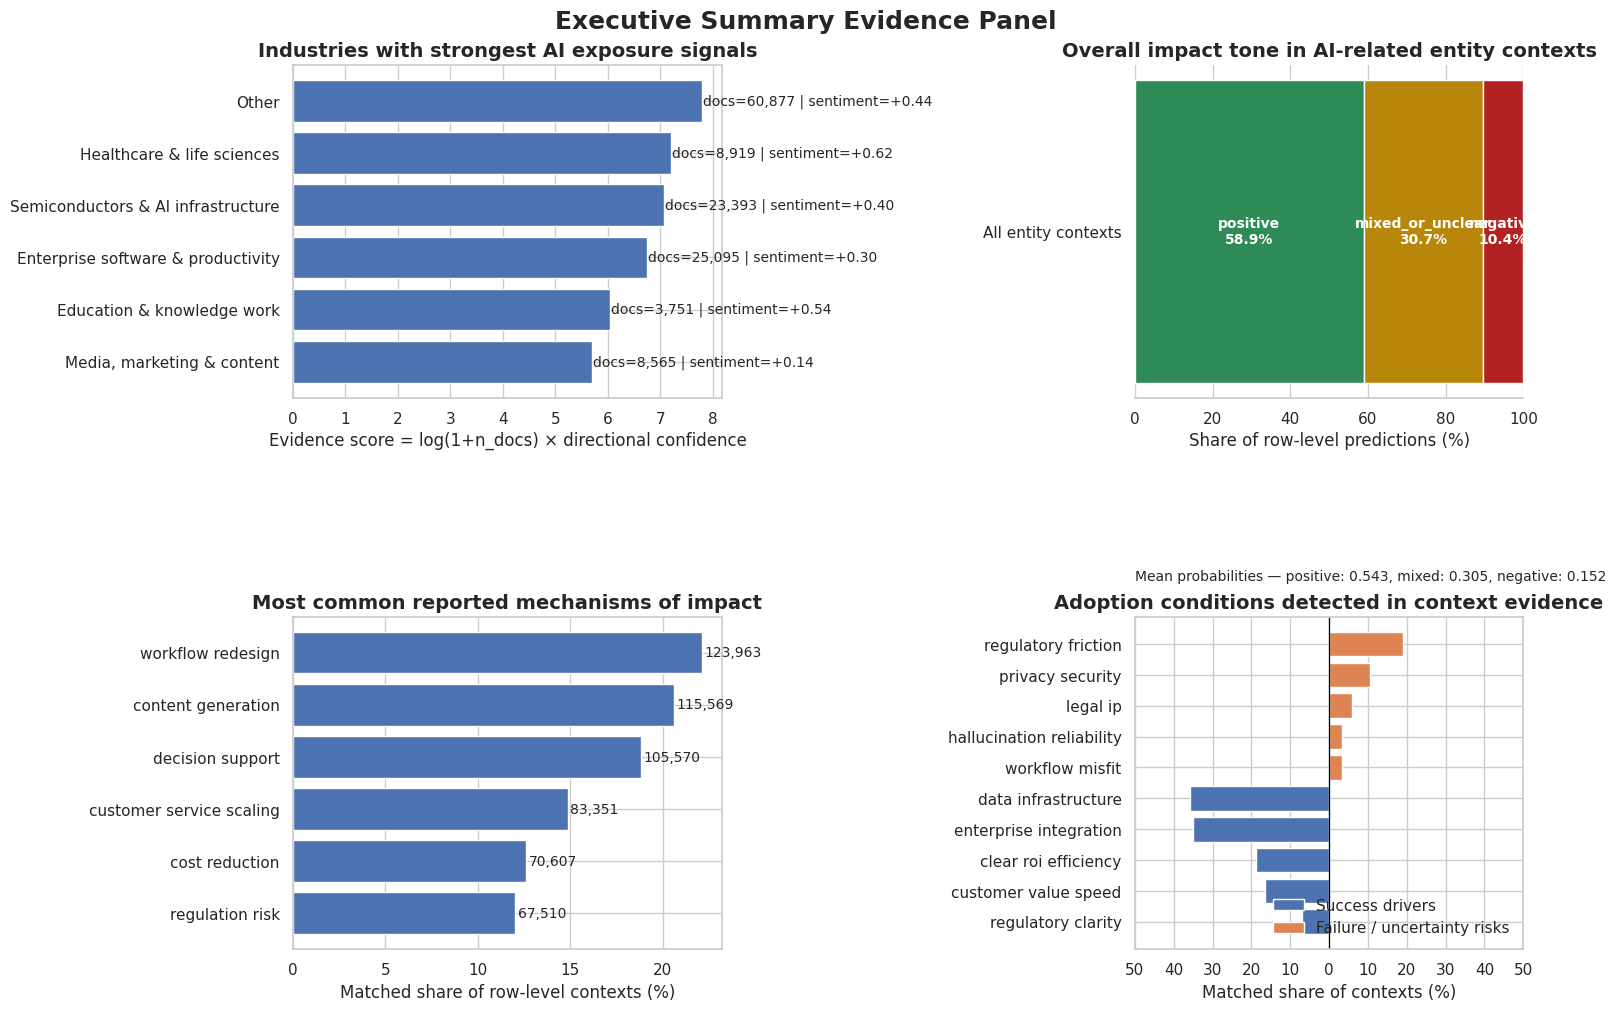

In [16]:
# ---------------------------------------------------------
# Executive Summary Panel Figure
# ---------------------------------------------------------

plot_industries = industry_summary_display.head(6).copy()
plot_industries = plot_industries.sort_values('evidence_score', ascending=True)

plot_mechanisms = mechanism_summary.head(6).copy()
plot_mechanisms = plot_mechanisms.sort_values('n_rows', ascending=True)

plot_drivers = driver_summary.head(5).copy().sort_values('n_rows', ascending=True)
plot_risks = risk_summary.head(5).copy().sort_values('n_rows', ascending=True)

fig = plt.figure(figsize=(16, 10), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], width_ratios=[1.05, 0.95])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# Panel A: Industries most likely to be impacted
ax1.barh(plot_industries['industry'], plot_industries['evidence_score'])
ax1.set_title('Industries with strongest AI exposure signals', fontsize=14, weight='bold')
ax1.set_xlabel('Evidence score = log(1+n_docs) × directional confidence')
ax1.set_ylabel('')
for i, (_, row) in enumerate(plot_industries.iterrows()):
    label = f"docs={int(row['n_docs']):,} | sentiment={row['sentiment_index']:+.2f}"
    ax1.text(row['evidence_score'] + 0.02, i, label, va='center', fontsize=10)

# Panel B: Overall tone
color_map = {
    'positive': '#2E8B57',
    'mixed_or_unclear': '#B8860B',
    'negative': '#B22222',
}
left = 0.0
for _, row in overall_shares.iterrows():
    ax2.barh(['All entity contexts'], [row['share_pct']], left=left, color=color_map[row['pred_sentiment_label']])
    ax2.text(left + row['share_pct'] / 2, 0, f"{row['pred_sentiment_label']}\n{row['share_pct']:.1f}%", ha='center', va='center', color='white', fontsize=10, weight='bold')
    left += row['share_pct']
ax2.set_xlim(0, 100)
ax2.set_title('Overall impact tone in AI-related entity contexts', fontsize=14, weight='bold')
ax2.set_xlabel('Share of row-level predictions (%)')
ax2.set_ylabel('')
ax2.spines[['top', 'right', 'left']].set_visible(False)
ax2.text(
    0.0,
    -0.55,
    (
        f"Mean probabilities — positive: {overall_prob_means['prob_positive_mean']:.3f}, "
        f"mixed: {overall_prob_means['prob_mixed_mean']:.3f}, "
        f"negative: {overall_prob_means['prob_negative_mean']:.3f}"
    ),
    transform=ax2.transAxes,
    fontsize=10,
)

# Panel C: Main mechanisms
ax3.barh(
    plot_mechanisms['category'].str.replace('_', ' ', regex=False),
    plot_mechanisms['row_share'] * 100,
)
ax3.set_title('Most common reported mechanisms of impact', fontsize=14, weight='bold')
ax3.set_xlabel('Matched share of row-level contexts (%)')
ax3.set_ylabel('')
for i, (_, row) in enumerate(plot_mechanisms.iterrows()):
    ax3.text(row['row_share'] * 100 + 0.15, i, f"{row['n_rows']:,}", va='center', fontsize=10)

# Panel D: Drivers vs risks
max_val = max(
    plot_drivers['row_share'].max() * 100 if not plot_drivers.empty else 0,
    plot_risks['row_share'].max() * 100 if not plot_risks.empty else 0,
)

ax4.barh(
    plot_drivers['category'].str.replace('_', ' ', regex=False),
    -plot_drivers['row_share'] * 100,
    label='Success drivers',
)
ax4.barh(
    plot_risks['category'].str.replace('_', ' ', regex=False),
    plot_risks['row_share'] * 100,
    label='Failure / uncertainty risks',
)
ax4.set_xlim(-(max_val * 1.25), max_val * 1.25)
ax4.axvline(0, color='black', linewidth=0.9)
ax4.set_title('Adoption conditions detected in context evidence', fontsize=14, weight='bold')
ax4.set_xlabel('Matched share of contexts (%)')
ax4.set_ylabel('')
ax4.legend(frameon=False, loc='lower right')
ax4.set_xticks(ax4.get_xticks())
ax4.set_xticklabels([f'{abs(x):.0f}' for x in ax4.get_xticks()])

fig.suptitle('Executive Summary Evidence Panel', fontsize=18, weight='bold')
save_fig(fig, FIG_DIR / 'slide_02_executive_summary_panel.png', dpi=240)
plt.show()

In [17]:
# ---------------------------------------------------------
# PPT-Ready Preview Tables
# ---------------------------------------------------------

print('\nTop industries for Slide 02:')
display(
    industry_summary_display[
        ['industry', 'n_docs', 'n_rows', 'evidence_score', 'sentiment_index', 'top_companies']
    ].head(8)
)

print('\nExecutive summary bullets:')
for i, bullet in enumerate(bullets, start=1):
    print(f'{i}. {bullet}')


Top industries for Slide 02:


,industry,n_docs,n_rows,evidence_score,sentiment_index,top_companies
0,Other,60877,223979,7.786545,0.442202,"24-7 Intouch, 360 Security Technology, 3DAPARTMENT.com"
1,Healthcare & life sciences,8919,44605,7.211241,0.621035,"3Sixty, AESOP, AEYE Health"
2,Semiconductors & AI infrastructure,23393,106686,7.071712,0.397060,"ABB Technology Ventures, AMI, AORUS"
3,Enterprise software & productivity,25095,106530,6.744511,0.301130,"AI Or Not, AI4Chat, Adore Me"
4,Education & knowledge work,3751,13751,6.034155,0.543396,"Alliancehcm, Data Science 4 Everyone, Digital Academy"
5,"Media, marketing & content",8565,40279,5.699420,0.137306,"2moons, Actualization AI, Agileblue"
6,"Finance, legal & compliance",4491,20645,4.889650,0.216867,"Alkami, American Bankers Association, Bancorp"
7,Customer service & operations,1159,4523,4.581517,0.094372,"Caldecott Music Group, Futureverse, Music Streamer"



Executive summary bullets:
1. Industries with the strongest AI exposure signals are Other, Healthcare & life sciences, Semiconductors & AI infrastructure, Enterprise software & productivity.
2. Overall reporting tone is led by positive coverage (58.9%), with positive=58.9%, mixed/unclear=30.7%, negative=10.4%.
3. The most common reported impact mechanisms are workflow redesign, content generation, decision support.
4. Company evidence anchors are strongest in Customer service & operations: Caldecott Music Group, Futureverse, Music Streamer; Education & knowledge work: Alliancehcm, Data Science 4 Everyone, Digital Academy; Enterprise software & productivity: AI Or Not, AI4Chat, Adore Me.
5. Adoption success is most often associated with data infrastructure, enterprise integration, clear roi efficiency.
6. Adoption friction is most often associated with regulatory friction, privacy security, legal ip.


In [18]:
# ---------------------------------------------------------
# Optional: compact text file for direct PPT paste
# ---------------------------------------------------------

#plain_text = '\n'.join([f'• {b}' for b in bullets]) + '\n'
#(REPORT_DIR / 'slide_02_executive_summary_bullets.txt').write_text(plain_text, encoding='utf-8')
#print('Saved:', REPORT_DIR / 'slide_02_executive_summary_bullets.txt')
#print(plain_text)

# Slide 02 — Executive Summary Panel

This section prepares the presentation-ready summary visualization used in the Executive Summary slide.

The figure summarizes four core findings derived from the NLP pipeline:

1. Industries most exposed to AI-related discussion
2. Overall sentiment distribution
3. Dominant mechanisms of AI impact
4. Adoption enablers and barriers

The goal is to provide a high-level overview for a business-oriented audience before the technical methodology is presented.

In [19]:
# ---------------------------------------------------------
# Load previously generated presentation tables
# ---------------------------------------------------------

industry_table = pd.read_csv(TAB_DIR / "slide_02_top_industries.csv")
mechanism_table = pd.read_csv(TAB_DIR / "slide_02_mechanism_summary.csv")
driver_table = pd.read_csv(TAB_DIR / "slide_02_adoption_drivers.csv")
risk_table = pd.read_csv(TAB_DIR / "slide_02_adoption_risks.csv")

sentiment_json = json.load(
    open(REPORT_DIR / "slide_02_executive_summary_metrics.json")
)

industry_table.head()

,industry,n_rows,n_docs,n_domains,prob_negative_mean,prob_mixed_mean,prob_positive_mean,pred_confidence_mean,sentiment_index,directional_confidence,evidence_score,impact_score,coverage_share_docs
0,Other,223979,60877,3811,0.132298,0.293201,0.574501,0.852593,0.442202,0.706799,7.786545,3.443229,0.446804
1,Healthcare & life sciences,44605,8919,1319,0.085876,0.207212,0.706912,0.859553,0.621035,0.792788,7.211241,4.478436,0.065461
2,Semiconductors & AI infrastructure,106686,23393,2495,0.152939,0.297063,0.549998,0.856537,0.397060,0.702937,7.071712,2.807894,0.171692
3,Enterprise software & productivity,106530,25095,2609,0.182318,0.334235,0.483448,0.857058,0.301130,0.665765,6.744511,2.030975,0.184183
4,Education & knowledge work,13751,3751,825,0.094895,0.266814,0.638291,0.851594,0.543396,0.733186,6.034155,3.278937,0.027530


In [20]:
# ---------------------------------------------------------
# Prepare industry ranking (exclude "Other")
# ---------------------------------------------------------

industry_plot = (
    industry_table
    .loc[industry_table["industry"] != "Other"]
    .copy()
)

industry_plot["rank_score"] = (
    industry_plot["impact_score"] * np.log1p(industry_plot["n_docs"])
)

industry_plot = (
    industry_plot
    .sort_values("rank_score", ascending=False)
    .head(5)
)

industry_plot

,industry,n_rows,n_docs,n_domains,prob_negative_mean,prob_mixed_mean,prob_positive_mean,pred_confidence_mean,sentiment_index,directional_confidence,evidence_score,impact_score,coverage_share_docs,rank_score
1,Healthcare & life sciences,44605,8919,1319,0.085876,0.207212,0.706912,0.859553,0.621035,0.792788,7.211241,4.478436,0.065461,40.736079
2,Semiconductors & AI infrastructure,106686,23393,2495,0.152939,0.297063,0.549998,0.856537,0.397060,0.702937,7.071712,2.807894,0.171692,28.248069
4,Education & knowledge work,13751,3751,825,0.094895,0.266814,0.638291,0.851594,0.543396,0.733186,6.034155,3.278937,0.027530,26.985797
3,Enterprise software & productivity,106530,25095,2609,0.182318,0.334235,0.483448,0.857058,0.301130,0.665765,6.744511,2.030975,0.184183,20.574715
6,"Finance, legal & compliance",20645,4491,1185,0.182269,0.418595,0.399136,0.858790,0.216867,0.581405,4.889650,1.060405,0.032961,8.918059


In [21]:
# ---------------------------------------------------------
# Prepare mechanism ranking
# ---------------------------------------------------------

mechanism_plot = (
    mechanism_table
    .sort_values("row_share", ascending=False)
    .head(5)
)

mechanism_plot

,category,n_rows,row_share
0,workflow_redesign,123963,0.220969
1,content_generation,115569,0.206006
2,decision_support,105570,0.188182
3,customer_service_scaling,83351,0.148576
4,cost_reduction,70607,0.125860


In [22]:
# ---------------------------------------------------------
# Prepare adoption drivers / risks
# ---------------------------------------------------------

driver_plot = (
    driver_table
    .sort_values("row_share", ascending=False)
    .head(4)
)

risk_plot = (
    risk_table
    .sort_values("row_share", ascending=False)
    .head(4)
)

In [23]:
# ---------------------------------------------------------
# Sentiment distribution (robust version)
# ---------------------------------------------------------

print("Available keys in sentiment_json:")
print(sentiment_json.keys())

print("Falling back to computing distribution from predictions")

pred_counts = df_pred["pred_sentiment_label"].value_counts(normalize=True)

pos = pred_counts.get("positive",0)
mix = pred_counts.get("mixed_or_unclear",0)
neg = pred_counts.get("negative",0)

sentiment_dist = pd.DataFrame({
    "label": ["Positive", "Mixed / Unclear", "Negative"],
    "share": [pos, mix, neg]
})

sentiment_dist

Available keys in sentiment_json:
dict_keys(['n_clean_ai_docs', 'n_row_level_sentiment_predictions', 'n_unique_entities_in_row_predictions', 'n_industries_detected_for_slide_02', 'overall_sentiment_prob_means', 'top_industries', 'top_mechanisms', 'top_drivers', 'top_risks', 'bullets'])
Falling back to computing distribution from predictions


,label,share
0,Positive,0.589041
1,Mixed / Unclear,0.306769
2,Negative,0.104189


Saved figure: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/figures/slide_02_executive_summary_panel.png


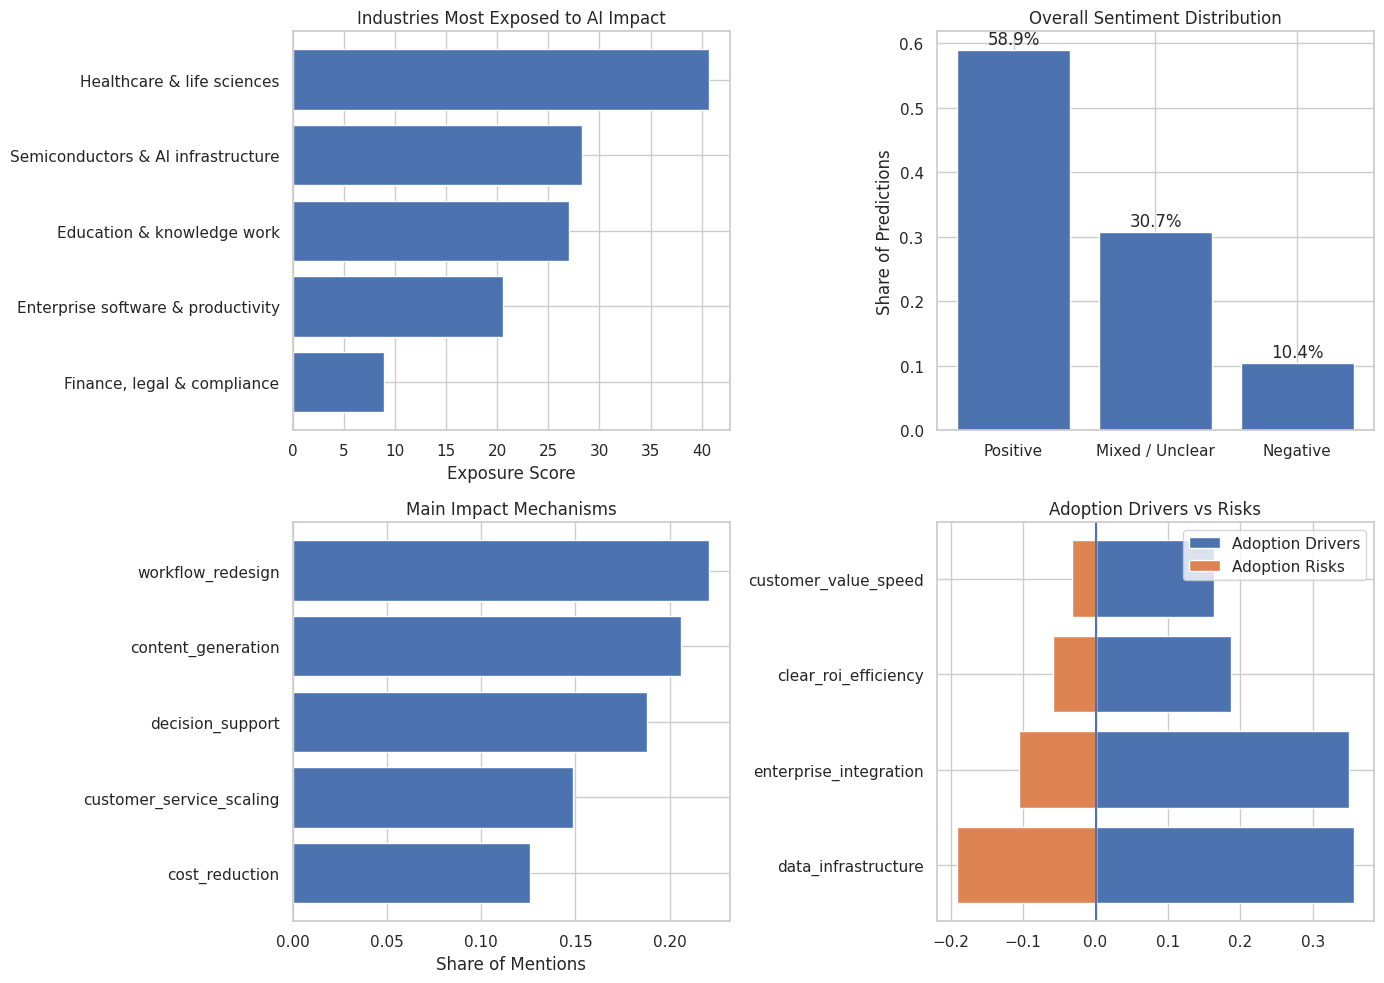

In [24]:
# ---------------------------------------------------------
# Executive Summary Panel
# ---------------------------------------------------------

fig = plt.figure(figsize=(14,10))

gs = fig.add_gridspec(2,2)

# ---------------------------------------------------------
# Industries
# ---------------------------------------------------------

ax1 = fig.add_subplot(gs[0,0])

ax1.barh(
    industry_plot["industry"],
    industry_plot["rank_score"]
)

ax1.set_title("Industries Most Exposed to AI Impact")
ax1.set_xlabel("Exposure Score")

ax1.invert_yaxis()

# ---------------------------------------------------------
# Sentiment distribution
# ---------------------------------------------------------

ax2 = fig.add_subplot(gs[0,1])

ax2.bar(
    sentiment_dist["label"],
    sentiment_dist["share"]
)

ax2.set_title("Overall Sentiment Distribution")
ax2.set_ylabel("Share of Predictions")

for i,v in enumerate(sentiment_dist["share"]):
    ax2.text(i, v+0.01, f"{v:.1%}", ha="center")

# ---------------------------------------------------------
# Mechanisms
# ---------------------------------------------------------

ax3 = fig.add_subplot(gs[1,0])

ax3.barh(
    mechanism_plot["category"],
    mechanism_plot["row_share"]
)

ax3.set_title("Main Impact Mechanisms")

ax3.set_xlabel("Share of Mentions")

ax3.invert_yaxis()

# ---------------------------------------------------------
# Adoption drivers vs risks
# ---------------------------------------------------------

ax4 = fig.add_subplot(gs[1,1])

y_pos = np.arange(len(driver_plot))

ax4.barh(
    y_pos,
    driver_plot["row_share"],
    label="Adoption Drivers"
)

ax4.barh(
    y_pos,
    -risk_plot["row_share"],
    label="Adoption Risks"
)

ax4.set_yticks(y_pos)

ax4.set_yticklabels(driver_plot["category"])

ax4.set_title("Adoption Drivers vs Risks")

ax4.axvline(0)

ax4.legend()

plt.tight_layout()

save_path = FIG_DIR / "slide_02_executive_summary_panel.png"

plt.savefig(save_path, dpi=300, bbox_inches="tight")

print("Saved figure:", save_path)

plt.show()

# Slide 05 — Dataset Overview

This section verifies the basic corpus statistics used in the Dataset Overview slide.

The slide summarizes:
- total number of articles
- date range
- language composition
- source diversity derived from URL domains
- article length distribution
- retained clean AI documents for downstream analysis

In [25]:
# ---------------------------------------------------------
# Slide 05 — Load raw source data
# ---------------------------------------------------------

from urllib.parse import urlparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = BASE_DIR / "data"
RAW_LOCAL_PATH = DATA_DIR / "news_final_project.parquet"

assert RAW_LOCAL_PATH.exists(), f"Missing file: {RAW_LOCAL_PATH}"

df_raw = pd.read_parquet(RAW_LOCAL_PATH)

print("Raw dataset shape:")
print(df_raw.shape)
print("\nColumns:")
print(df_raw.columns.tolist())

display(df_raw.head(3))

Raw dataset shape:
(199989, 5)

Columns:
['url', 'date', 'language', 'title', 'text']


,url,date,language,title,text
0,https://blockworks.co/price/bad,2025-06-23,en,"Bad Idea AI Price (BAD), Market Cap, Price Today & Chart History - Blockworks","Bad Idea AI Price (BAD), Market Cap, Price Today & Chart History - BlockworksOpen menuBrandsnewsletterspodcastseventsroundtablestoken transparencyetf trackerpricesresearchanalyticshomepricesBad Idea AI price (BAD)Bad Idea AIBADLive Bad ..."
1,https://boingboing.net/2024/07/01/this-ai-video-of-gymnastics-might-be-the-freakiest-ive-seen-yet.html,2024-07-01,en,This AI video of gymnastics might be the freakiest I've seen yet - Boing Boing,\n\nThis AI video of gymnastics might be the freakiest I've seen yet - Boing Boing\n\n \n\t\t\t\t\tMENU \n\n\t\t\t\t\t\tSEARCH \n\n\t\t\t\t\t\tSTORE \n\n\n\t\t\t\t\t\t\tMENU ...
2,https://boingboing.net/2024/09/18/if-using-ai-feels-like-a-chore-try-this.html,2024-09-22,en,"If using AI feels like a chore, try this - Boing Boing","\n\nIf using AI feels like a chore, try this - Boing Boing\n \n\t\t\t\t\tMENU \n\n\t\t\t\t\t\tSEARCH \n\n\t\t\t\t\t\tSTORE \n\n\n\t\t\t\t\t\t\tMENU \n\t\t\t\t\t..."


In [26]:
# ---------------------------------------------------------
# Slide 05 — Verify overview statistics
# ---------------------------------------------------------

# Basic counts
n_articles = len(df_raw)

date_series = pd.to_datetime(df_raw["date"], errors="coerce")
date_min = date_series.min()
date_max = date_series.max()

# Language distribution
language_counts = (
    df_raw["language"]
    .fillna("missing")
    .value_counts(dropna=False)
    .rename_axis("language")
    .reset_index(name="n_articles")
)

# Domain extraction from URL
df_raw["domain"] = (
    df_raw["url"]
    .astype(str)
    .map(lambda x: urlparse(x).netloc.lower().replace("www.", ""))
)

n_domains = df_raw["domain"].nunique(dropna=True)

top_domains = (
    df_raw["domain"]
    .value_counts(dropna=True)
    .head(15)
    .rename_axis("domain")
    .reset_index(name="n_articles")
)

# Article length in characters
df_raw["article_length_chars"] = df_raw["text"].astype(str).str.len()

length_stats = (
    df_raw["article_length_chars"]
    .describe()
    .to_frame(name="value")
)

# Clean AI docs count for footnote / bridge to next slides
clean_path = OUT_DIR / "clean_ai_docs.parquet"
n_clean_docs = None

if clean_path.exists():
    df_clean = pd.read_parquet(clean_path)
    n_clean_docs = len(df_clean)

print("\nDataset Overview Summary")
print("----------------------------")
print(f"Total articles: {n_articles:,}")
print(f"Date range: {date_min.date()} → {date_max.date()}")
print(f"Unique domains: {n_domains:,}")

if n_clean_docs is not None:
    print(f"Documents retained after cleaning: {n_clean_docs:,}")

print("\nLanguage distribution")
display(language_counts)

print("\nArticle length summary (characters)")
display(length_stats)

print("\nTop domains")
display(top_domains)


Dataset Overview Summary
----------------------------
Total articles: 199,989
Date range: 2022-01-01 → 2026-02-10
Unique domains: 5,675

Language distribution


,language,n_articles
0,en,199989



Article length summary (characters)


,value
count,199989.000000
mean,9098.766462
std,7264.733714
min,21.000000
25%,5245.000000
50%,7622.000000
75%,11390.000000
max,580772.000000



Top domains


,domain,n_articles
0,rawpixel.com,7315
1,menafn.com,4094
2,einpresswire.com,3829
3,citylife.capetown,3265
4,prnewswire.com,2857
5,nasdaq.com,2548
6,mexc.co,2317
7,livemint.com,1865
8,economictimes.indiatimes.com,1701
9,business-standard.com,1687


In [27]:
# ---------------------------------------------------------
# Slide 05 — Summary table for PPT
# ---------------------------------------------------------

primary_language = language_counts.iloc[0]["language"]
primary_language_share = language_counts.iloc[0]["n_articles"] / n_articles

dataset_overview_table = pd.DataFrame({
    "metric": [
        "Total articles",
        "Date range start",
        "Date range end",
        "Unique domains",
        "Primary language",
        "Primary language share",
        "Median article length (chars)",
        "Mean article length (chars)"
    ],
    "value": [
        f"{n_articles:,}",
        str(date_min.date()),
        str(date_max.date()),
        f"{n_domains:,}",
        str(primary_language),
        f"{primary_language_share:.1%}",
        f"{df_raw['article_length_chars'].median():,.0f}",
        f"{df_raw['article_length_chars'].mean():,.0f}"
    ]
})

display(dataset_overview_table)

save_table_path = TAB_DIR / "slide_05_dataset_overview_table.csv"
dataset_overview_table.to_csv(save_table_path, index=False)
print("Saved:", save_table_path)

,metric,value
0,Total articles,"199,989"
1,Date range start,2022-01-01
2,Date range end,2026-02-10
3,Unique domains,"5,675"
4,Primary language,en
5,Primary language share,100.0%
6,Median article length (chars),"7,622"
7,Mean article length (chars),"9,099"


Saved: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/tables/slide_05_dataset_overview_table.csv


Saved: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/figures/slide_05_article_length_distribution_improved.png


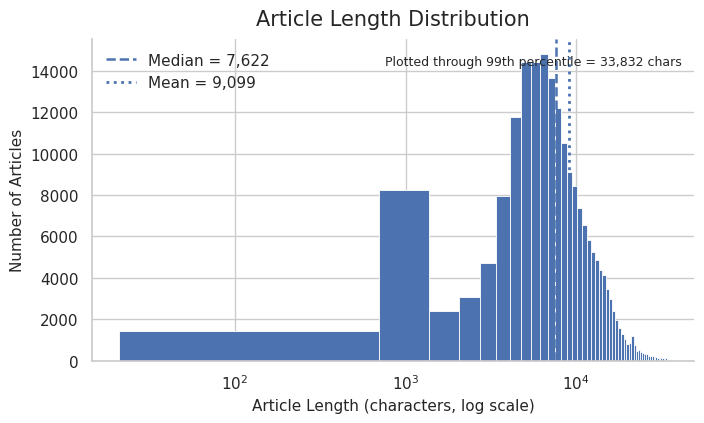

In [28]:
# ---------------------------------------------------------
# Slide 05 — Improved figure: article length distribution
# ---------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

length = df_raw["article_length_chars"].dropna().astype(float)

median_len = length.median()
mean_len = length.mean()
p99_len = length.quantile(0.99)

# p99
length_plot = length[length <= p99_len]

fig, ax = plt.subplots(figsize=(7.2, 4.4))

ax.hist(length_plot, bins=50, edgecolor="white", linewidth=0.6)

ax.set_xscale("log")
ax.set_title("Article Length Distribution", fontsize=15, pad=10)
ax.set_xlabel("Article Length (characters, log scale)", fontsize=11)
ax.set_ylabel("Number of Articles", fontsize=11)

# mean / median markers
ax.axvline(median_len, linestyle="--", linewidth=1.8, label=f"Median = {median_len:,.0f}")
ax.axvline(mean_len, linestyle=":", linewidth=2.0, label=f"Mean = {mean_len:,.0f}")

# annotation
ax.text(
    0.98, 0.95,
    f"Plotted through 99th percentile = {p99_len:,.0f} chars",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9
)

ax.legend(frameon=False, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

save_path = FIG_DIR / "slide_05_article_length_distribution_improved.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print("Saved:", save_path)

plt.show()

In [29]:
# ---------------------------------------------------------
# Slide 05 — PPT-ready text snippets
# ---------------------------------------------------------

overview_lines = [
    f"{n_articles:,} news articles",
    f"Date range: {date_min.date()} to {date_max.date()}",
    f"{n_domains:,} unique domains derived from article URLs",
    f"Primary language: {primary_language} ({primary_language_share:.1%})"
]

if n_clean_docs is not None:
    overview_lines.append(
        f"After AI filtering and cleaning: {n_clean_docs:,} documents retained"
    )

print("Slide 05 text lines:\n")
for line in overview_lines:
    print("-", line)

Slide 05 text lines:

- 199,989 news articles
- Date range: 2022-01-01 to 2026-02-10
- 5,675 unique domains derived from article URLs
- Primary language: en (100.0%)


In [30]:
# ---------------------------------------------------------
# Slide 07 — Stage 02 cleaning/filtering counts
# Real paths verified from 02A–02D notebooks
# ---------------------------------------------------------

import pandas as pd
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen")
DATA_DIR = BASE_DIR / "data"
OUT_DIR = BASE_DIR / "output"

RAW_PARQUET = DATA_DIR / "news_final_project.parquet"

DOCS_02A = OUT_DIR / "02A_block_sample" / "docs.parquet"
BLOCK_LABELS_02A = OUT_DIR / "02A_block_sample" / "block_labels.parquet"

AI_BLOCKS_02B = OUT_DIR / "02B_block_train" / "ai_blocks.parquet"

CONTENT_SENTENCES_02D = OUT_DIR / "02D_sentence_train" / "content_sentences.parquet"
CLEAN_BLOCKS_02D = OUT_DIR / "02D_sentence_train" / "clean_ai_blocks.parquet"
CLEAN_DOCS_02D = OUT_DIR / "02D_sentence_train" / "clean_ai_docs.parquet"

for p in [
    RAW_PARQUET, DOCS_02A, AI_BLOCKS_02B,
    CONTENT_SENTENCES_02D, CLEAN_BLOCKS_02D, CLEAN_DOCS_02D
]:
    print(p, "->", p.exists())

# -----------------------------
# raw documents
# -----------------------------
df_raw = pd.read_parquet(RAW_PARQUET, columns=["url", "date", "language", "title", "text"])
n_raw_docs = len(df_raw)

# -----------------------------
# 02A minimally filtered docs
# -----------------------------
df_docs_02a = pd.read_parquet(DOCS_02A)
n_docs_02a = len(df_docs_02a)

# -----------------------------
# 02B retained AI-relevant blocks
# -----------------------------
df_ai_blocks = pd.read_parquet(AI_BLOCKS_02B)
n_ai_blocks = len(df_ai_blocks)
n_docs_with_ai_blocks = df_ai_blocks["doc_id"].nunique()

# -----------------------------
# 02D retained content sentences
# -----------------------------
df_content_sentences = pd.read_parquet(CONTENT_SENTENCES_02D)
n_content_sentences = len(df_content_sentences)
n_docs_with_content_sentences = df_content_sentences["doc_id"].nunique()

# -----------------------------
# 02D rebuilt clean blocks
# -----------------------------
df_clean_blocks = pd.read_parquet(CLEAN_BLOCKS_02D)
n_clean_blocks = len(df_clean_blocks)
n_docs_with_clean_blocks = df_clean_blocks["doc_id"].nunique()

# -----------------------------
# 02D rebuilt clean docs
# -----------------------------
df_clean_docs = pd.read_parquet(CLEAN_DOCS_02D)
n_clean_docs = len(df_clean_docs)

stage07_counts = pd.DataFrame({
    "stage": [
        "Raw Documents",
        "02A Minimal Filtered Documents",
        "Documents with AI-Relevant Blocks",
        "Clean AI Documents",
        "AI-Relevant Blocks",
        "Retained Content Sentences",
        "Clean AI Blocks"
    ],
    "count": [
        n_raw_docs,
        n_docs_02a,
        n_docs_with_ai_blocks,
        n_clean_docs,
        n_ai_blocks,
        n_content_sentences,
        n_clean_blocks
    ],
    "unit": [
        "documents",
        "documents",
        "documents",
        "documents",
        "blocks",
        "sentences",
        "blocks"
    ]
})

display(stage07_counts)

stage07_counts.to_csv(
    BASE_DIR / "presentation_assets" / "tables" / "slide_07_cleaning_counts.csv",
    index=False
)

/content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/data/news_final_project.parquet -> True
/content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/output/02A_block_sample/docs.parquet -> True
/content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/output/02B_block_train/ai_blocks.parquet -> True
/content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/output/02D_sentence_train/content_sentences.parquet -> True
/content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/output/02D_sentence_train/clean_ai_blocks.parquet -> True
/content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/output/02D_sentence_train/clean_ai_docs.parquet -> True


,stage,count,unit
0,Raw Documents,199989,documents
1,02A Minimal Filtered Documents,197984,documents
2,Documents with AI-Relevant Blocks,194112,documents
3,Clean AI Documents,181008,documents
4,AI-Relevant Blocks,1184289,blocks
5,Retained Content Sentences,4586024,sentences
6,Clean AI Blocks,731989,blocks


Saved: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/figures/slide_07_doc_retention.png


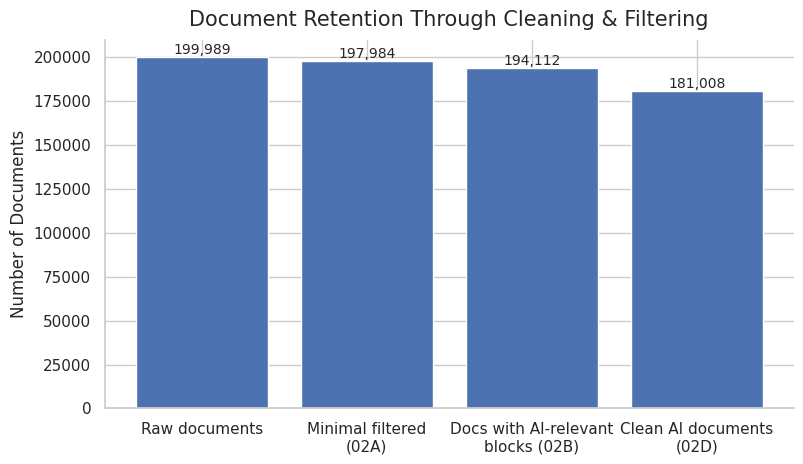

In [31]:
# ---------------------------------------------------------
# Slide 07 — Document-level retention chart
# ---------------------------------------------------------

import matplotlib.pyplot as plt

doc_retention = pd.DataFrame({
    "stage": [
        "Raw documents",
        "Minimal filtered\n(02A)",
        "Docs with AI-relevant\nblocks (02B)",
        "Clean AI documents\n(02D)"
    ],
    "count": [
        n_raw_docs,
        n_docs_02a,
        n_docs_with_ai_blocks,
        n_clean_docs
    ]
})

fig, ax = plt.subplots(figsize=(8.2, 4.8))

bars = ax.bar(doc_retention["stage"], doc_retention["count"])

ax.set_title("Document Retention Through Cleaning & Filtering", fontsize=15, pad=10)
ax.set_ylabel("Number of Documents")

for bar, val in zip(bars, doc_retention["count"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{val:,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

save_path = BASE_DIR / "presentation_assets" / "figures" / "slide_07_doc_retention.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print("Saved:", save_path)

plt.show()

Saved: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/figures/slide_07_text_unit_retention.png


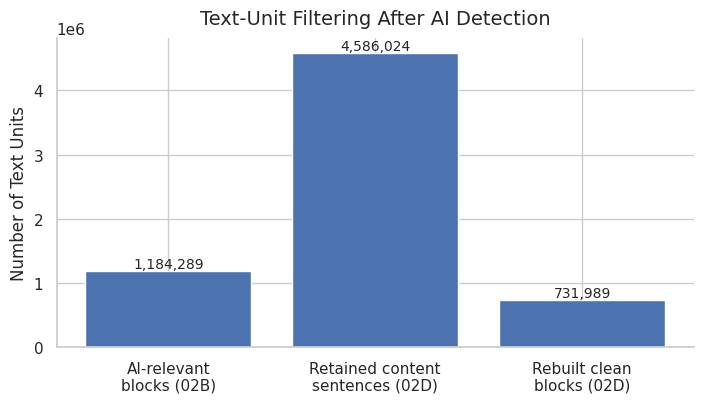

In [32]:
# ---------------------------------------------------------
# Slide 07 — Text-unit retention chart
# ---------------------------------------------------------

unit_retention = pd.DataFrame({
    "stage": [
        "AI-relevant\nblocks (02B)",
        "Retained content\nsentences (02D)",
        "Rebuilt clean\nblocks (02D)"
    ],
    "count": [
        n_ai_blocks,
        n_content_sentences,
        n_clean_blocks
    ]
})

fig, ax = plt.subplots(figsize=(7.2, 4.2))

bars = ax.bar(unit_retention["stage"], unit_retention["count"])

ax.set_title("Text-Unit Filtering After AI Detection", fontsize=14, pad=10)
ax.set_ylabel("Number of Text Units")

for bar, val in zip(bars, unit_retention["count"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{val:,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

save_path = BASE_DIR / "presentation_assets" / "figures" / "slide_07_text_unit_retention.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print("Saved:", save_path)

plt.show()

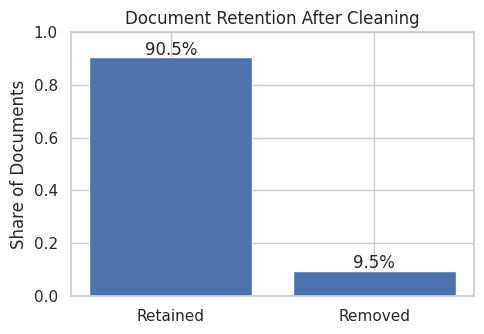

In [33]:
import matplotlib.pyplot as plt

raw_docs = 199989
clean_docs = 181008

retention = clean_docs / raw_docs
removed = 1 - retention

labels = ["Retained", "Removed"]
values = [retention, removed]

plt.figure(figsize=(5,3.5))

plt.bar(labels, values)

plt.title("Document Retention After Cleaning")
plt.ylabel("Share of Documents")

for i,v in enumerate(values):
    plt.text(i, v + 0.01, f"{v*100:.1f}%", ha="center")

plt.ylim(0,1)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "slide_08_retention_ratio.png",
    dpi=300
)

plt.show()

In [34]:
# ---------------------------------------------------------
# Slide 08 — Two-stage cleaning audit metrics
# ---------------------------------------------------------

raw_docs = 199989
docs_after_block_filter = 194112
clean_ai_docs = 181008

ai_blocks = 1184289
content_sentences = 4586024
clean_ai_blocks = 731989

audit_metrics = pd.DataFrame({
    "metric": [
        "Raw documents",
        "Documents with AI-relevant blocks",
        "Clean AI documents",
        "Stage-1 doc retention",
        "Stage-2 doc retention",
        "End-to-end doc retention",
        "AI-relevant blocks",
        "Retained content sentences",
        "Clean AI blocks"
    ],
    "value": [
        raw_docs,
        docs_after_block_filter,
        clean_ai_docs,
        docs_after_block_filter / raw_docs,
        clean_ai_docs / docs_after_block_filter,
        clean_ai_docs / raw_docs,
        ai_blocks,
        content_sentences,
        clean_ai_blocks
    ]
})

display(audit_metrics)

audit_metrics.to_csv(TAB_DIR / "slide_08_audit_metrics.csv", index=False)

,metric,value
0,Raw documents,1.999890e+05
1,Documents with AI-relevant blocks,1.941120e+05
2,Clean AI documents,1.810080e+05
3,Stage-1 doc retention,9.706134e-01
4,Stage-2 doc retention,9.324926e-01
5,End-to-end doc retention,9.050898e-01
6,AI-relevant blocks,1.184289e+06
7,Retained content sentences,4.586024e+06
8,Clean AI blocks,7.319890e+05


Saved: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/figures/slide_08_audit_strip.png


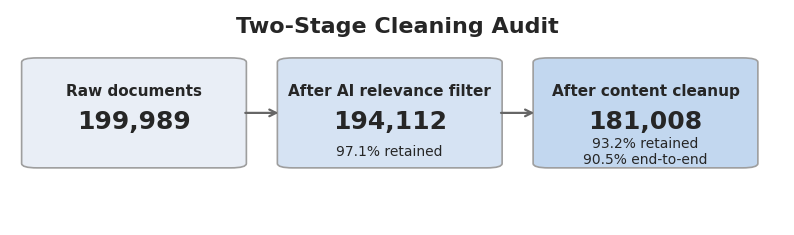

In [35]:
# ---------------------------------------------------------
# Slide 08 — PPT-style audit strip
# ---------------------------------------------------------

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

stages = [
    ("Raw documents", "199,989", ""),
    ("After AI relevance filter", "194,112", "97.1% retained"),
    ("After content cleanup", "181,008", "93.2% retained\n90.5% end-to-end"),
]

fig, ax = plt.subplots(figsize=(10, 2.8))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

x_positions = [0.03, 0.36, 0.69]
box_w = 0.26
box_h = 0.48

for i, ((title, value, sub), x) in enumerate(zip(stages, x_positions)):
    box = FancyBboxPatch(
        (x, 0.28), box_w, box_h,
        boxstyle="round,pad=0.015,rounding_size=0.02",
        linewidth=1.2,
        edgecolor="#9E9E9E",
        facecolor=["#E9EEF6", "#D6E3F3", "#C2D7EF"][i]
    )
    ax.add_patch(box)

    ax.text(x + box_w/2, 0.62, title, ha="center", va="center", fontsize=11, weight="bold")
    ax.text(x + box_w/2, 0.48, value, ha="center", va="center", fontsize=18, weight="bold")
    if sub:
        ax.text(x + box_w/2, 0.34, sub, ha="center", va="center", fontsize=10)

# arrows
for x1, x2 in [(0.29, 0.36), (0.62, 0.69)]:
    ax.annotate(
        "", xy=(x2-0.01, 0.52), xytext=(x1+0.01, 0.52),
        arrowprops=dict(arrowstyle="->", lw=1.6, color="#666666")
    )

ax.text(0.5, 0.92, "Two-Stage Cleaning Audit", ha="center", va="center", fontsize=16, weight="bold")

save_path = FIG_DIR / "slide_08_audit_strip.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight", transparent=False)
print("Saved:", save_path)
plt.show()

# Slide 10 — Topic Landscape Overview

This section summarizes the topic detection results at the block level.

Outputs prepared for the slide:
- a bar chart of the largest topics
- a compact summary table with topic id, label, size, and interpretation

The slide is designed to provide a high-level overview before topic trends and topic interpretation are discussed in later slides.

In [36]:
# ---------------------------------------------------------
# Slide 10 — Inspect topic summary schema
# ---------------------------------------------------------

print("df_topic_summary shape:", df_topic_summary.shape)
print("df_topic_summary columns:")
print(df_topic_summary.columns.tolist())

display(df_topic_summary.head(5))

df_topic_summary shape: (72, 13)
df_topic_summary columns:
['topic_id', 'n_blocks', 'n_docs', 'n_domains', 'topic_name', 'top_keywords', 'avg_topic_prob', 'avg_topic_text_len', 'is_noise_topic', 'human_label', 'super_topic', 'include_in_analysis', 'notes']


,topic_id,n_blocks,n_docs,n_domains,topic_name,top_keywords,avg_topic_prob,avg_topic_text_len,is_noise_topic,human_label,super_topic,include_in_analysis,notes
0,0,25667,12974,1271,0_gpu_net_nvidia_intel,"gpu, net, nvidia, intel, dell, gaming, computing, gpus, rtx, cpu",0.962727,963.547123,0,NaN,NaN,True,NaN
1,1,24660,11026,1532,1_ai platform_device_providers_ai healthcare,"ai platform, device, providers, ai healthcare, provider, digital health, professionals, monitoring, insight, care",0.865960,989.170762,0,NaN,NaN,True,NaN
2,2,22287,12234,1991,2_ai chatbot_chatgpt plus_chatgpt ai_ai model,"ai chatbot, chatgpt plus, chatgpt ai, ai model, thinking, chatbots, chatbot, asked chatgpt, plus, topics",0.894194,896.966034,0,NaN,NaN,True,NaN
3,3,13174,5681,1480,3_ai generated content_ai generated images_disinformation_media platforms,"ai generated content, ai generated images, disinformation, media platforms, meta, democracy, threat, social media platforms, tiktok, synthetic",0.861556,776.295810,0,NaN,NaN,True,NaN
4,4,11959,6182,1202,4_ai overviews_ai features_google ai_ai chatbot,"ai overviews, ai features, google ai, ai chatbot, ai model, tech giant, google deepmind, apps, chatbot, seo",0.897742,818.690024,0,NaN,NaN,True,NaN


In [37]:
# ---------------------------------------------------------
# Slide 10 — Build topic landscape table
# ---------------------------------------------------------

topic_tbl = df_topic_summary.copy()

# ---- likely column mapping ----
topic_id_col = "topic_id" if "topic_id" in topic_tbl.columns else None

label_candidates = ["topic_name", "topic_label", "label", "topic"]
size_candidates = ["topic_blocks_global", "size", "n_blocks", "count", "topic_size"]
keywords_candidates = ["top_keywords", "keywords"]
docs_candidates = ["topic_docs_global", "n_docs", "doc_count"]

label_col = next((c for c in label_candidates if c in topic_tbl.columns), None)
size_col = next((c for c in size_candidates if c in topic_tbl.columns), None)
keywords_col = next((c for c in keywords_candidates if c in topic_tbl.columns), None)
docs_col = next((c for c in docs_candidates if c in topic_tbl.columns), None)

assert label_col is not None, "No topic label column found."
assert size_col is not None, "No topic size column found."

keep_cols = [c for c in [topic_id_col, label_col, size_col, docs_col, keywords_col] if c is not None]
topic_tbl = topic_tbl[keep_cols].copy()

rename_map = {
    label_col: "topic_label",
    size_col: "topic_size_blocks"
}
if topic_id_col is not None:
    rename_map[topic_id_col] = "topic_id"
if docs_col is not None:
    rename_map[docs_col] = "topic_size_docs"
if keywords_col is not None:
    rename_map[keywords_col] = "top_keywords"

topic_tbl = topic_tbl.rename(columns=rename_map)

# keep only analysis topics if such a flag exists
if "include_in_analysis" in df_topic_summary.columns:
    topic_tbl = topic_tbl.loc[df_topic_summary["include_in_analysis"].fillna(False)].copy()

topic_tbl = topic_tbl.sort_values("topic_size_blocks", ascending=False).reset_index(drop=True)

display(topic_tbl.head(10))

,topic_id,topic_label,topic_size_blocks,topic_size_docs,top_keywords
0,0,0_gpu_net_nvidia_intel,25667,12974,"gpu, net, nvidia, intel, dell, gaming, computing, gpus, rtx, cpu"
1,1,1_ai platform_device_providers_ai healthcare,24660,11026,"ai platform, device, providers, ai healthcare, provider, digital health, professionals, monitoring, insight, care"
2,2,2_ai chatbot_chatgpt plus_chatgpt ai_ai model,22287,12234,"ai chatbot, chatgpt plus, chatgpt ai, ai model, thinking, chatbots, chatbot, asked chatgpt, plus, topics"
3,3,3_ai generated content_ai generated images_disinformation_media platforms,13174,5681,"ai generated content, ai generated images, disinformation, media platforms, meta, democracy, threat, social media platforms, tiktok, synthetic"
4,4,4_ai overviews_ai features_google ai_ai chatbot,11959,6182,"ai overviews, ai features, google ai, ai chatbot, ai model, tech giant, google deepmind, apps, chatbot, seo"
5,5,5_smart_ai data centers_algorithm_prediction,9467,5242,"smart, ai data centers, algorithm, prediction, predict, ai data, computing, forecasting, 2030, nasa"
6,6,6_ai skills_ai work_automated_automation,8469,4693,"ai skills, ai work, automated, automation, ai jobs, ai job, replaced ai, jobs ai, skill, skilled"
7,7,7_ai chatbot_robot_ai company_media platform,7950,4122,"ai chatbot, robot, ai company, media platform, chatbot, ai startup, tesla, interview, maker, social media platform"
8,9,9_ai research_ai assistant_ai model_ai chatbot,7688,4307,"ai research, ai assistant, ai model, ai chatbot, smart, superintelligence, scale ai, big tech, language model, chatbots"
9,8,8_free ai_ai powered video_ai image_options,7435,3188,"free ai, ai powered video, ai image, options, enables, ai image generator, accessible, generators, content creators, interface"


In [38]:
# ---------------------------------------------------------
# Slide 10 — Generate short topic interpretations
# ---------------------------------------------------------

def make_interpretation(row):
    label = str(row.get("topic_label", ""))
    keywords = str(row.get("top_keywords", ""))

    text = label.replace("_", " ")
    if "||" in text:
        text = text.split("||")[0].strip()

    # fallback to keywords if label is messy
    if len(text) > 90 or text.lower() == "nan":
        text = keywords

    # keep it short for PPT
    text = text[:85].strip(" ,;:-")
    return text

topic_tbl["interpretation"] = topic_tbl.apply(make_interpretation, axis=1)

display(topic_tbl.head(10))

,topic_id,topic_label,topic_size_blocks,topic_size_docs,top_keywords,interpretation
0,0,0_gpu_net_nvidia_intel,25667,12974,"gpu, net, nvidia, intel, dell, gaming, computing, gpus, rtx, cpu",0 gpu net nvidia intel
1,1,1_ai platform_device_providers_ai healthcare,24660,11026,"ai platform, device, providers, ai healthcare, provider, digital health, professionals, monitoring, insight, care",1 ai platform device providers ai healthcare
2,2,2_ai chatbot_chatgpt plus_chatgpt ai_ai model,22287,12234,"ai chatbot, chatgpt plus, chatgpt ai, ai model, thinking, chatbots, chatbot, asked chatgpt, plus, topics",2 ai chatbot chatgpt plus chatgpt ai ai model
3,3,3_ai generated content_ai generated images_disinformation_media platforms,13174,5681,"ai generated content, ai generated images, disinformation, media platforms, meta, democracy, threat, social media platforms, tiktok, synthetic",3 ai generated content ai generated images disinformation media platforms
4,4,4_ai overviews_ai features_google ai_ai chatbot,11959,6182,"ai overviews, ai features, google ai, ai chatbot, ai model, tech giant, google deepmind, apps, chatbot, seo",4 ai overviews ai features google ai ai chatbot
5,5,5_smart_ai data centers_algorithm_prediction,9467,5242,"smart, ai data centers, algorithm, prediction, predict, ai data, computing, forecasting, 2030, nasa",5 smart ai data centers algorithm prediction
6,6,6_ai skills_ai work_automated_automation,8469,4693,"ai skills, ai work, automated, automation, ai jobs, ai job, replaced ai, jobs ai, skill, skilled",6 ai skills ai work automated automation
7,7,7_ai chatbot_robot_ai company_media platform,7950,4122,"ai chatbot, robot, ai company, media platform, chatbot, ai startup, tesla, interview, maker, social media platform",7 ai chatbot robot ai company media platform
8,9,9_ai research_ai assistant_ai model_ai chatbot,7688,4307,"ai research, ai assistant, ai model, ai chatbot, smart, superintelligence, scale ai, big tech, language model, chatbots",9 ai research ai assistant ai model ai chatbot
9,8,8_free ai_ai powered video_ai image_options,7435,3188,"free ai, ai powered video, ai image, options, enables, ai image generator, accessible, generators, content creators, interface",8 free ai ai powered video ai image options


Saved: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/figures/slide_10_topic_landscape_bar.png


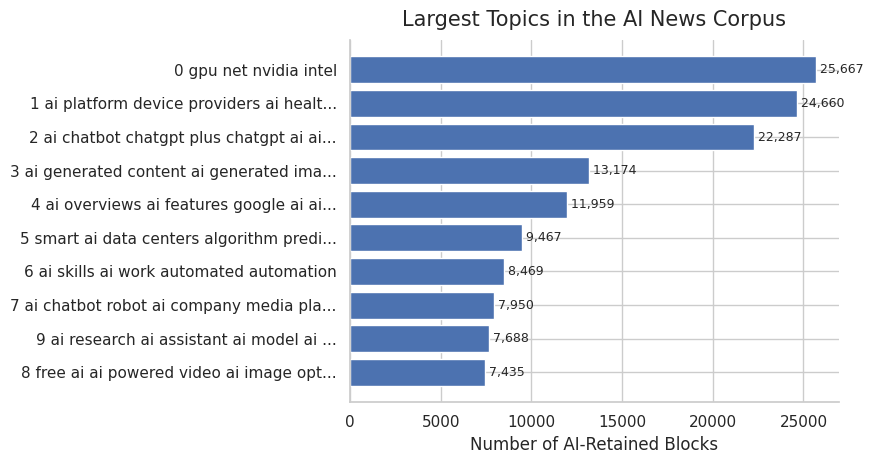

In [39]:
# ---------------------------------------------------------
# Slide 10 — Main figure: top topic size bar chart
# ---------------------------------------------------------

plot_tbl = topic_tbl.head(10).copy()

# shorter display labels
def short_label(x, max_len=42):
    x = str(x).replace("_", " ")
    if "||" in x:
        x = x.split("||")[0].strip()
    return x if len(x) <= max_len else x[:max_len-3] + "..."

plot_tbl["plot_label"] = plot_tbl["topic_label"].map(short_label)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8.8, 4.8))

bars = ax.barh(plot_tbl["plot_label"], plot_tbl["topic_size_blocks"])

ax.invert_yaxis()
ax.set_title("Largest Topics in the AI News Corpus", fontsize=15, pad=10)
ax.set_xlabel("Number of AI-Retained Blocks")
ax.set_ylabel("")

for bar, val in zip(bars, plot_tbl["topic_size_blocks"]):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f" {val:,.0f}",
        va="center",
        fontsize=9
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

save_path = FIG_DIR / "slide_10_topic_landscape_bar.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print("Saved:", save_path)

plt.show()

In [40]:
# ---------------------------------------------------------
# Slide 10 — Optional presentation labels
# ---------------------------------------------------------

presentation_topic_table = topic_tbl.head(8).copy()

presentation_topic_table["presentation_label"] = (
    presentation_topic_table["topic_label"]
    .astype(str)
    .str.replace("_", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

presentation_topic_table["presentation_label"] = presentation_topic_table["presentation_label"].map(
    lambda x: x.split("||")[0].strip() if "||" in x else x
)

display(
    presentation_topic_table[
        [c for c in ["topic_id", "presentation_label", "topic_size_blocks", "interpretation"] if c in presentation_topic_table.columns]
    ]
)

,topic_id,presentation_label,topic_size_blocks,interpretation
0,0,0 gpu net nvidia intel,25667,0 gpu net nvidia intel
1,1,1 ai platform device providers ai healthcare,24660,1 ai platform device providers ai healthcare
2,2,2 ai chatbot chatgpt plus chatgpt ai ai model,22287,2 ai chatbot chatgpt plus chatgpt ai ai model
3,3,3 ai generated content ai generated images disinformation media platforms,13174,3 ai generated content ai generated images disinformation media platforms
4,4,4 ai overviews ai features google ai ai chatbot,11959,4 ai overviews ai features google ai ai chatbot
5,5,5 smart ai data centers algorithm prediction,9467,5 smart ai data centers algorithm prediction
6,6,6 ai skills ai work automated automation,8469,6 ai skills ai work automated automation
7,7,7 ai chatbot robot ai company media platform,7950,7 ai chatbot robot ai company media platform


In [41]:
# ---------------------------------------------------------
# Slide 10 — Semantic topic landscape (presentation-grade)
# ---------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# -----------------------------
# 1. topic grouping map
# -----------------------------
meta_topic_map = {
    "Chatbots, Assistants & Consumer AI": [2, 4, 16, 18, 19, 29, 33, 41, 42, 43, 47, 48, 52, 64],
    "AI Infrastructure & Compute": [0, 5, 34, 49, 58],
    "Enterprise Platforms & Adoption": [7, 20, 23, 28, 30, 36, 39, 44, 45, 50, 55, 60, 62],
    "Agents, Frontier Models & AGI": [9, 10, 11, 13, 24, 46, 57],
    "Governance, Regulation, Safety & Security": [14, 15, 26, 31, 32, 37, 51, 59, 63, 65, 66],
    "Synthetic Media & Creator Tools": [3, 8, 17, 21, 61, 68, 53],
    "Healthcare & Life Sciences": [1],
    "Work, Skills & Automation": [6, 22, 35, 40, 67, 70],
    "Education": [12],
    "Finance, Legal & Compliance": [25, 69],
    "Other / Unclustered": [27, 38, 54, 56],
}

meta_topic_interpretation = {
    "Chatbots, Assistants & Consumer AI": "Conversational AI, assistants, and consumer-facing AI features",
    "AI Infrastructure & Compute": "GPUs, chips, compute, and data-center infrastructure",
    "Enterprise Platforms & Adoption": "Enterprise platforms, providers, startups, and adoption narratives",
    "Agents, Frontier Models & AGI": "Agents, frontier models, AGI, and advanced assistant discourse",
    "Governance, Regulation, Safety & Security": "Regulation, oversight, safety, security, and AI risk",
    "Synthetic Media & Creator Tools": "Generated media, creator tools, and synthetic content applications",
    "Healthcare & Life Sciences": "Healthcare platforms, providers, and digital-health applications",
    "Work, Skills & Automation": "Jobs, skills, automation, and AI readiness",
    "Education": "Education and student-oriented AI use cases",
    "Finance, Legal & Compliance": "Financial, legal, and compliance-adjacent AI applications",
    "Other / Unclustered": "Residual or weakly clustered topics",
}

# -----------------------------
# 2. use only analysis topics
# -----------------------------
topic_src = df_topic_summary.copy()

if "include_in_analysis" in topic_src.columns:
    topic_src = topic_src.loc[topic_src["include_in_analysis"].fillna(False)].copy()

topic_sizes = (
    topic_src[["topic_id", "n_blocks"]]
    .rename(columns={"n_blocks": "topic_size_blocks"})
    .copy()
)

# -----------------------------
# 3. aggregate to meta-topics
# -----------------------------
rows = []
all_grouped_topic_ids = set()

for meta_topic, topic_ids in meta_topic_map.items():
    all_grouped_topic_ids.update(topic_ids)

    subset = topic_sizes.loc[topic_sizes["topic_id"].isin(topic_ids)].copy()
    rows.append({
        "meta_topic": meta_topic,
        "topic_size_blocks": subset["topic_size_blocks"].sum(),
        "n_topics_merged": subset["topic_id"].nunique(),
        "topic_ids": ", ".join([f"T{x}" for x in sorted(subset["topic_id"].tolist())]),
        "interpretation": meta_topic_interpretation[meta_topic]
    })

meta_tbl = pd.DataFrame(rows)

# optional safety catch: any included topic not explicitly grouped
unassigned = topic_sizes.loc[~topic_sizes["topic_id"].isin(all_grouped_topic_ids)].copy()
if len(unassigned) > 0:
    meta_tbl = pd.concat([
        meta_tbl,
        pd.DataFrame([{
            "meta_topic": "Unassigned Topics",
            "topic_size_blocks": unassigned["topic_size_blocks"].sum(),
            "n_topics_merged": unassigned["topic_id"].nunique(),
            "topic_ids": ", ".join([f"T{x}" for x in sorted(unassigned["topic_id"].tolist())]),
            "interpretation": "Topics not assigned to a stable semantic group"
        }])
    ], ignore_index=True)

meta_tbl = meta_tbl.sort_values("topic_size_blocks", ascending=False).reset_index(drop=True)

display(meta_tbl)

,meta_topic,topic_size_blocks,n_topics_merged,topic_ids,interpretation
0,"Chatbots, Assistants & Consumer AI",69386,14,"T2, T4, T16, T18, T19, T29, T33, T41, T42, T43, T47, T48, T52, T64","Conversational AI, assistants, and consumer-facing AI features"
1,AI Infrastructure & Compute,43195,5,"T0, T5, T34, T49, T58","GPUs, chips, compute, and data-center infrastructure"
2,Enterprise Platforms & Adoption,39176,13,"T7, T20, T23, T28, T30, T36, T39, T44, T45, T50, T55, T60, T62","Enterprise platforms, providers, startups, and adoption narratives"
3,"Agents, Frontier Models & AGI",34436,7,"T9, T10, T11, T13, T24, T46, T57","Agents, frontier models, AGI, and advanced assistant discourse"
4,"Governance, Regulation, Safety & Security",32911,11,"T14, T15, T26, T31, T32, T37, T51, T59, T63, T65, T66","Regulation, oversight, safety, security, and AI risk"
5,Synthetic Media & Creator Tools,32806,7,"T3, T8, T17, T21, T53, T61, T68","Generated media, creator tools, and synthetic content applications"
6,Healthcare & Life Sciences,24660,1,T1,"Healthcare platforms, providers, and digital-health applications"
7,"Work, Skills & Automation",17976,6,"T6, T22, T35, T40, T67, T70","Jobs, skills, automation, and AI readiness"
8,Other / Unclustered,9251,4,"T27, T38, T54, T56",Residual or weakly clustered topics
9,Education,5773,1,T12,Education and student-oriented AI use cases


Saved: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/figures/slide_10_meta_topic_landscape.png


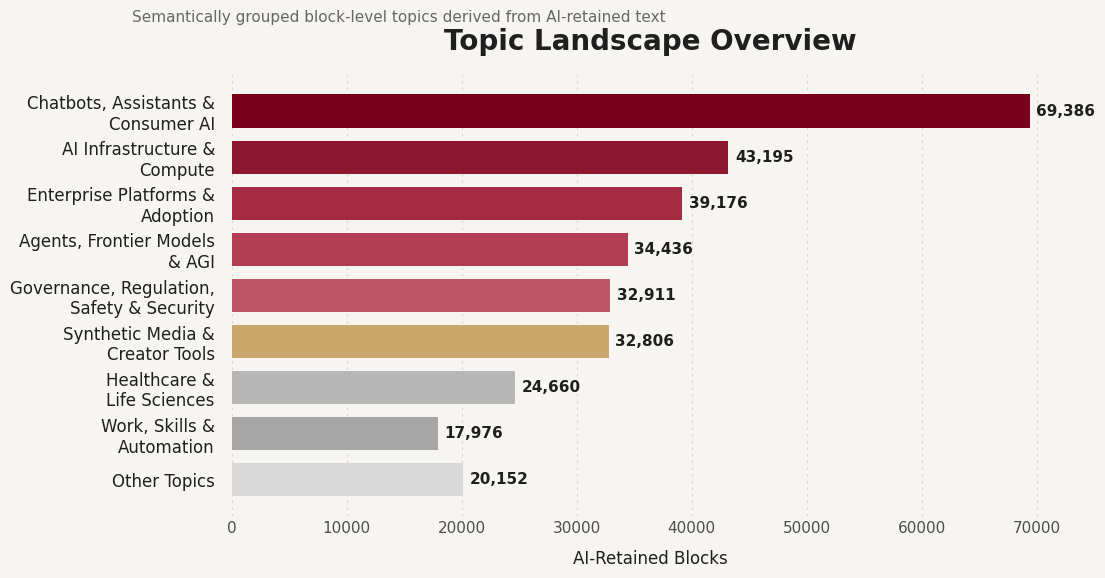

In [42]:
# ---------------------------------------------------------
# Slide 10 — Polished meta-topic bar chart for PPT
# ---------------------------------------------------------

plot_tbl = meta_tbl.copy()

# keep top 8 as main categories; merge the remainder
top_n = 8
top_tbl = plot_tbl.head(top_n).copy()
tail_tbl = plot_tbl.iloc[top_n:].copy()

if len(tail_tbl) > 0:
    tail_row = pd.DataFrame([{
        "meta_topic": "Other Topics",
        "topic_size_blocks": tail_tbl["topic_size_blocks"].sum(),
        "n_topics_merged": tail_tbl["n_topics_merged"].sum(),
        "topic_ids": "",
        "interpretation": "Smaller or less central topic groups"
    }])
    plot_tbl = pd.concat([top_tbl, tail_row], ignore_index=True)
else:
    plot_tbl = top_tbl.copy()

# short display labels
plot_tbl["display_label"] = plot_tbl["meta_topic"].replace({
    "Governance, Regulation, Safety & Security": "Governance, Regulation,\nSafety & Security",
    "Chatbots, Assistants & Consumer AI": "Chatbots, Assistants &\nConsumer AI",
    "Enterprise Platforms & Adoption": "Enterprise Platforms &\nAdoption",
    "Agents, Frontier Models & AGI": "Agents, Frontier Models\n& AGI",
    "Synthetic Media & Creator Tools": "Synthetic Media &\nCreator Tools",
    "AI Infrastructure & Compute": "AI Infrastructure &\nCompute",
    "Healthcare & Life Sciences": "Healthcare &\nLife Sciences",
    "Work, Skills & Automation": "Work, Skills &\nAutomation",
    "Other Topics": "Other Topics"
})

# colors
base_color = "#7A0019"         # UChicago maroon
secondary_color = "#C9A66B"    # muted gold
neutral_color = "#D9D9D9"
text_dark = "#1F1F1F"
bg = "#F7F5F2"

colors = [
    base_color, "#8E1730", "#A52A42", "#B33E54",
    "#C05767", "#C9A66B", "#B7B7B7", "#A6A6A6", neutral_color
][:len(plot_tbl)]

fig, ax = plt.subplots(figsize=(11.2, 6.2), facecolor=bg)
ax.set_facecolor(bg)

y = np.arange(len(plot_tbl))
bars = ax.barh(
    y,
    plot_tbl["topic_size_blocks"],
    color=colors,
    height=0.72,
    edgecolor="none"
)

# clean axis
ax.set_yticks(y)
ax.set_yticklabels(plot_tbl["display_label"], fontsize=12, color=text_dark)
ax.invert_yaxis()

ax.set_xlabel("AI-Retained Blocks", fontsize=12, color=text_dark, labelpad=10)
ax.set_title(
    "Topic Landscape Overview",
    fontsize=20,
    fontweight="bold",
    color=text_dark,
    pad=18
)

# remove spines
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

# subtle x-grid only
ax.xaxis.grid(True, linestyle=(0, (2, 4)), linewidth=0.8, color="#D6D0C8")
ax.yaxis.grid(False)
ax.set_axisbelow(True)

# tick styling
ax.tick_params(axis="x", labelsize=11, colors="#4D4D4D", length=0)
ax.tick_params(axis="y", length=0, pad=12)

# value labels
max_val = plot_tbl["topic_size_blocks"].max()
for bar, val in zip(bars, plot_tbl["topic_size_blocks"]):
    ax.text(
        bar.get_width() + max_val * 0.008,
        bar.get_y() + bar.get_height()/2,
        f"{val:,.0f}",
        va="center",
        ha="left",
        fontsize=11,
        color=text_dark,
        fontweight="bold"
    )

# subtitle
fig.text(
    0.125, 0.91,
    "Semantically grouped block-level topics derived from AI-retained text",
    fontsize=11,
    color="#666666"
)

plt.tight_layout(rect=[0, 0, 1, 0.93])

save_path = FIG_DIR / "slide_10_meta_topic_landscape.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor=bg)
print("Saved:", save_path)

plt.show()

In [43]:
# ---------------------------------------------------------
# Slide 10 — Compact PPT-ready meta-topic table
# ---------------------------------------------------------

ppt_meta_table = plot_tbl.copy()
ppt_meta_table["size"] = ppt_meta_table["topic_size_blocks"].map(lambda x: f"{x:,.0f}")

ppt_meta_table = ppt_meta_table[[
    "meta_topic", "size", "n_topics_merged", "interpretation"
]].rename(columns={
    "meta_topic": "Meta-Topic",
    "size": "Size",
    "n_topics_merged": "Merged Topics",
    "interpretation": "Interpretation"
})

display(ppt_meta_table)

save_table_path = TAB_DIR / "slide_10_meta_topic_table.csv"
ppt_meta_table.to_csv(save_table_path, index=False)
print("Saved:", save_table_path)

,Meta-Topic,Size,Merged Topics,Interpretation
0,"Chatbots, Assistants & Consumer AI","69,386",14,"Conversational AI, assistants, and consumer-facing AI features"
1,AI Infrastructure & Compute,"43,195",5,"GPUs, chips, compute, and data-center infrastructure"
2,Enterprise Platforms & Adoption,"39,176",13,"Enterprise platforms, providers, startups, and adoption narratives"
3,"Agents, Frontier Models & AGI","34,436",7,"Agents, frontier models, AGI, and advanced assistant discourse"
4,"Governance, Regulation, Safety & Security","32,911",11,"Regulation, oversight, safety, security, and AI risk"
5,Synthetic Media & Creator Tools,"32,806",7,"Generated media, creator tools, and synthetic content applications"
6,Healthcare & Life Sciences,"24,660",1,"Healthcare platforms, providers, and digital-health applications"
7,"Work, Skills & Automation","17,976",6,"Jobs, skills, automation, and AI readiness"
8,Other Topics,"20,152",7,Smaller or less central topic groups


Saved: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/tables/slide_10_meta_topic_table.csv


In [44]:
# ---------------------------------------------------------
# Slide 11 — Prepare topic text for semantic map
# ---------------------------------------------------------

topic_map_tbl = df_topic_summary.copy()

topic_map_tbl = topic_map_tbl.loc[
    topic_map_tbl["include_in_analysis"].fillna(False)
].copy()

topic_map_tbl["topic_text"] = (
    topic_map_tbl["topic_name"].astype(str).str.replace("_", " ", regex=False)
    + " || "
    + topic_map_tbl["top_keywords"].astype(str)
)

topic_map_tbl = topic_map_tbl.sort_values("n_blocks", ascending=False).reset_index(drop=True)

display(topic_map_tbl[["topic_id", "n_blocks", "topic_name", "top_keywords"]].head(10))

,topic_id,n_blocks,topic_name,top_keywords
0,0,25667,0_gpu_net_nvidia_intel,"gpu, net, nvidia, intel, dell, gaming, computing, gpus, rtx, cpu"
1,1,24660,1_ai platform_device_providers_ai healthcare,"ai platform, device, providers, ai healthcare, provider, digital health, professionals, monitoring, insight, care"
2,2,22287,2_ai chatbot_chatgpt plus_chatgpt ai_ai model,"ai chatbot, chatgpt plus, chatgpt ai, ai model, thinking, chatbots, chatbot, asked chatgpt, plus, topics"
3,3,13174,3_ai generated content_ai generated images_disinformation_media platforms,"ai generated content, ai generated images, disinformation, media platforms, meta, democracy, threat, social media platforms, tiktok, synthetic"
4,4,11959,4_ai overviews_ai features_google ai_ai chatbot,"ai overviews, ai features, google ai, ai chatbot, ai model, tech giant, google deepmind, apps, chatbot, seo"
5,5,9467,5_smart_ai data centers_algorithm_prediction,"smart, ai data centers, algorithm, prediction, predict, ai data, computing, forecasting, 2030, nasa"
6,6,8469,6_ai skills_ai work_automated_automation,"ai skills, ai work, automated, automation, ai jobs, ai job, replaced ai, jobs ai, skill, skilled"
7,7,7950,7_ai chatbot_robot_ai company_media platform,"ai chatbot, robot, ai company, media platform, chatbot, ai startup, tesla, interview, maker, social media platform"
8,9,7688,9_ai research_ai assistant_ai model_ai chatbot,"ai research, ai assistant, ai model, ai chatbot, smart, superintelligence, scale ai, big tech, language model, chatbots"
9,8,7435,8_free ai_ai powered video_ai image_options,"free ai, ai powered video, ai image, options, enables, ai image generator, accessible, generators, content creators, interface"


In [45]:
# ---------------------------------------------------------
# Slide 11 — Topic embeddings and UMAP
# ---------------------------------------------------------

from sentence_transformers import SentenceTransformer
import umap.umap_ as umap
from sklearn.cluster import KMeans

embed_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

topic_embeddings = embed_model.encode(
    topic_map_tbl["topic_text"].tolist(),
    show_progress_bar=True
)

umap_model = umap.UMAP(
    n_neighbors=10,
    min_dist=0.20,
    n_components=2,
    metric="cosine",
    random_state=42
)

topic_2d = umap_model.fit_transform(topic_embeddings)

topic_map_tbl["umap_x"] = topic_2d[:, 0]
topic_map_tbl["umap_y"] = topic_2d[:, 1]

# small number of visual clusters for coloring
kmeans = KMeans(n_clusters=6, random_state=42, n_init=20)
topic_map_tbl["cluster_id"] = kmeans.fit_predict(topic_embeddings)

display(topic_map_tbl[["topic_id", "n_blocks", "umap_x", "umap_y", "cluster_id"]].head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,topic_id,n_blocks,umap_x,umap_y,cluster_id
0,0,25667,9.220443,-3.003456,5
1,1,24660,7.905430,-4.152671,1
2,2,22287,5.651595,-4.352137,0
3,3,13174,7.839074,-2.594649,5
4,4,11959,6.550146,-3.911568,0


In [46]:
# ---------------------------------------------------------
# Slide 11 — Presentation labels
# ---------------------------------------------------------

topic_label_map = {
    0: "GPU / Nvidia / Intel",
    1: "AI healthcare platforms",
    2: "Chatbots / foundation models",
    3: "Generated content / disinformation",
    4: "Google AI features / search",
    5: "Data centers / prediction",
    6: "Work / skills / automation",
    7: "Robots / AI companies",
    8: "AI image / video tools",
    9: "AI research / assistants",
    10: "Smart agents / long-term AI",
    11: "AGI / advanced AI systems",
    12: "AI education",
    13: "AGI / OpenAI / research staff",
    14: "AI security",
    15: "AI regulation",
}

topic_map_tbl["presentation_label"] = topic_map_tbl["topic_id"].map(topic_label_map)

# fallback
topic_map_tbl["presentation_label"] = topic_map_tbl["presentation_label"].fillna(
    topic_map_tbl["topic_id"].map(lambda x: f"T{x}")
)

Saved: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/figures/slide_11_topic_semantic_map.png


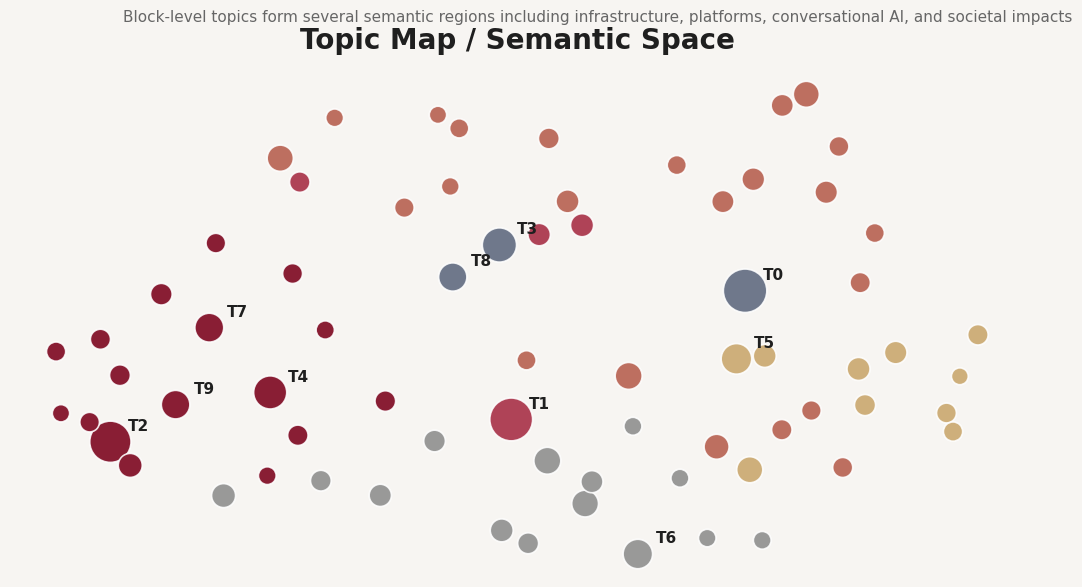

In [47]:
# ---------------------------------------------------------
# Slide 11 — Presentation-grade semantic map
# ---------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np

bg = "#F7F5F2"
text_dark = "#1F1F1F"

cluster_palette = {
    0: "#7A0019",
    1: "#A52A42",
    2: "#C9A66B",
    3: "#8C8C8C",
    4: "#B55D4C",
    5: "#5C677D",
}

fig, ax = plt.subplots(figsize=(10.5, 6.3), facecolor=bg)
ax.set_facecolor(bg)

# bubble sizes scaled by topic size
sizes = 80 + 900 * (topic_map_tbl["n_blocks"] / topic_map_tbl["n_blocks"].max())**0.8

for cid, grp in topic_map_tbl.groupby("cluster_id"):
    ax.scatter(
        grp["umap_x"],
        grp["umap_y"],
        s=sizes.loc[grp.index],
        color=cluster_palette.get(cid, "#999999"),
        alpha=0.88,
        edgecolors="white",
        linewidths=1.2
    )

# label only largest representative topics
label_tbl = topic_map_tbl.head(10).copy()

for _, row in label_tbl.iterrows():
    ax.text(
        row["umap_x"] + 0.10,
        row["umap_y"] + 0.10,
        f"T{int(row['topic_id'])}",
        fontsize=11,
        fontweight="bold",
        color=text_dark
    )

ax.set_title("Topic Map / Semantic Space", fontsize=20, fontweight="bold", color=text_dark, pad=16)
fig.text(
    0.125, 0.91,
    "Block-level topics form several semantic regions including infrastructure, platforms, conversational AI, and societal impacts",
    fontsize=11,
    color="#666666"
)

# remove axes completely
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.93])

save_path = FIG_DIR / "slide_11_topic_semantic_map.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor=bg)
print("Saved:", save_path)

plt.show()

In [48]:
# ---------------------------------------------------------
# Slide 11 — Representative topic legend table
# ---------------------------------------------------------

legend_tbl = topic_map_tbl.sort_values("n_blocks", ascending=False).head(10).copy()
legend_tbl["Topic ID"] = legend_tbl["topic_id"].map(lambda x: f"T{x}")

legend_tbl = legend_tbl[["Topic ID", "presentation_label", "n_blocks", "cluster_id"]].rename(columns={
    "presentation_label": "Representative Topic",
    "n_blocks": "Size",
    "cluster_id": "Cluster"
})

display(legend_tbl)

legend_tbl.to_csv(TAB_DIR / "slide_11_topic_map_legend.csv", index=False)

,Topic ID,Representative Topic,Size,Cluster
0,T0,GPU / Nvidia / Intel,25667,5
1,T1,AI healthcare platforms,24660,1
2,T2,Chatbots / foundation models,22287,0
3,T3,Generated content / disinformation,13174,5
4,T4,Google AI features / search,11959,0
5,T5,Data centers / prediction,9467,2
6,T6,Work / skills / automation,8469,3
7,T7,Robots / AI companies,7950,0
8,T9,AI research / assistants,7688,0
9,T8,AI image / video tools,7435,5


In [49]:
# ---------------------------------------------------------
# Slide 12 — Load topic_time_panel from notebook 03 output
# ---------------------------------------------------------

topic_time_path = BASE_DIR / "output" / "03_topic_modeling" / "topic_time_panel.parquet"
topic_time_panel = pd.read_parquet(topic_time_path)

print("topic_time_panel shape:", topic_time_panel.shape)
print("columns:", topic_time_panel.columns.tolist())

display(topic_time_panel.head())

topic_time_panel shape: (3454, 6)
columns: ['year_month', 'topic_id', 'n_blocks', 'n_docs', 'n_domains', 'mean_topic_prob']


,year_month,topic_id,n_blocks,n_docs,n_domains,mean_topic_prob
0,2022-01,-1,935,497,255,0.000000
1,2022-01,1,355,171,120,0.842258
2,2022-01,9,160,79,77,0.461010
3,2022-01,18,135,18,18,0.800822
4,2022-01,55,124,25,6,0.945812


In [50]:
# ---------------------------------------------------------
# Slide 12 — Topic trends over time (grouped + smoothed)
# ---------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tt = topic_time_panel.copy()

# time
tt["year_month"] = pd.to_datetime(tt["year_month"].astype(str))

# valid topic
tt = tt.loc[tt["topic_id"] != -1].copy()

# ---------------------------------------------------------
# super-topic grouping
# ---------------------------------------------------------
topic_group_map = {
    "Conversational AI & Consumer Features": [2, 4, 16, 18, 19, 29, 33, 41, 42, 43, 47, 48, 52, 64],
    "Infrastructure & Compute": [0, 5, 34, 49, 58],
    "Enterprise Adoption & Platforms": [1, 7, 20, 23, 28, 30, 36, 39, 44, 45, 50, 55, 60, 62],
    "Governance, Safety & Regulation": [3, 14, 15, 26, 31, 32, 37, 51, 59, 63, 65, 66, 69],
    "Work, Skills & Automation": [6, 22, 35, 40, 67, 70],
}

topic_to_group = {}
for group_name, tids in topic_group_map.items():
    for tid in tids:
        topic_to_group[tid] = group_name

tt["topic_group"] = tt["topic_id"].map(topic_to_group).fillna("Other Topics")

# concat
group_time = (
    tt.groupby(["year_month", "topic_group"], as_index=False)["n_blocks"]
      .sum()
)

panel = (
    group_time.pivot_table(
        index="year_month",
        columns="topic_group",
        values="n_blocks",
        aggfunc="sum",
        fill_value=0
    )
    .sort_index()
)

ordered_cols = [
    "Conversational AI & Consumer Features",
    "Infrastructure & Compute",
    "Enterprise Adoption & Platforms",
    "Governance, Safety & Regulation",
    "Work, Skills & Automation",
    "Other Topics"
]
panel = panel.reindex(columns=[c for c in ordered_cols if c in panel.columns])

# share
panel_share = panel.div(panel.sum(axis=1), axis=0).fillna(0)

# 3-month rolling mean
panel_share_smooth = panel_share.rolling(window=3, min_periods=1).mean()

display(panel_share_smooth.tail())

topic_group,Conversational AI & Consumer Features,Infrastructure & Compute,Enterprise Adoption & Platforms,"Governance, Safety & Regulation","Work, Skills & Automation",Other Topics
year_month,,,,,,
2025-10-01,0.189155,0.157693,0.159585,0.109282,0.060649,0.323637
2025-11-01,0.162305,0.181366,0.158708,0.113399,0.059531,0.324689
2025-12-01,0.152998,0.177219,0.157735,0.122988,0.058154,0.330906
2026-01-01,0.145765,0.176209,0.167205,0.128639,0.063886,0.318296
2026-02-01,0.142983,0.158381,0.188517,0.151316,0.068087,0.290717


Saved: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/figures/slide_12_topic_trends_over_time_share.png


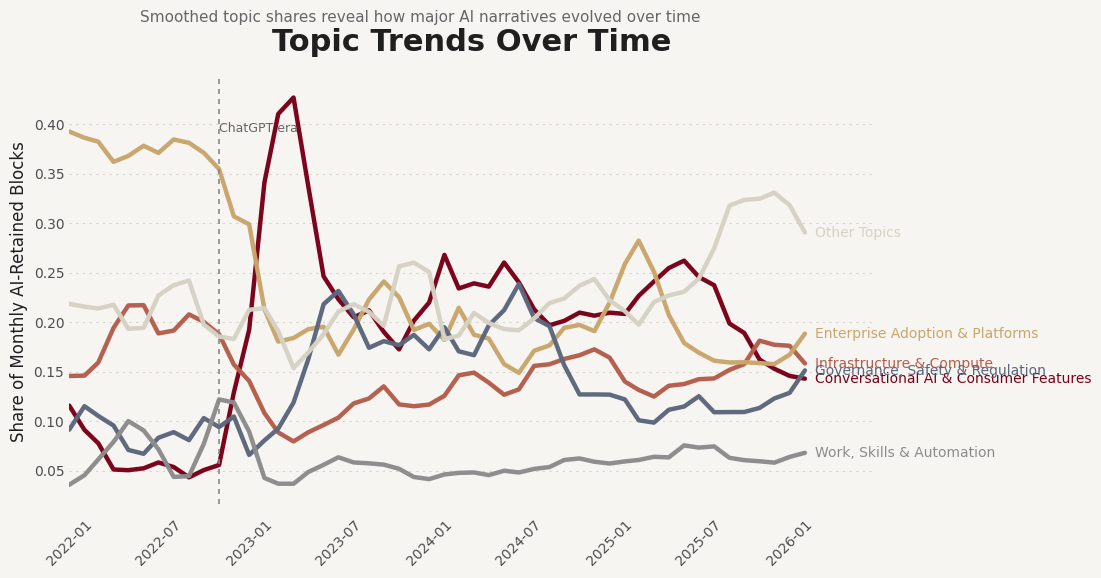

In [51]:
# ---------------------------------------------------------
# Slide 12 — Polished share-of-topic trends chart
# ---------------------------------------------------------

bg = "#F7F5F2"
text_dark = "#1F1F1F"
grid = "#D8D2C8"

palette = {
    "Conversational AI & Consumer Features": "#7A0019",
    "Infrastructure & Compute": "#B55D4C",
    "Enterprise Adoption & Platforms": "#C9A66B",
    "Governance, Safety & Regulation": "#5C677D",
    "Work, Skills & Automation": "#8C8C8C",
    "Other Topics": "#D6D2C4",
}

fig, ax = plt.subplots(figsize=(11.8, 6.2), facecolor=bg)
ax.set_facecolor(bg)

for col in panel_share_smooth.columns:
    ax.plot(
        panel_share_smooth.index,
        panel_share_smooth[col],
        linewidth=3.2,
        color=palette.get(col, "#999999"),
        alpha=0.98
    )

# end label
for col in panel_share_smooth.columns:
    x_last = panel_share_smooth.index[-1]
    y_last = panel_share_smooth[col].iloc[-1]
    ax.text(
        x_last + pd.Timedelta(days=20),
        y_last,
        col,
        fontsize=10,
        color=palette.get(col, "#999999"),
        va="center"
    )

# timestamp
ax.axvline(pd.Timestamp("2022-11-01"), color="#888888", linestyle=(0, (3, 3)), linewidth=1.2)
ax.text(
    pd.Timestamp("2022-11-01"),
    panel_share_smooth.max().max() * 0.92,
    "ChatGPT era",
    fontsize=9,
    color="#666666"
)

# topic
ax.set_title("Topic Trends Over Time", fontsize=22, fontweight="bold", color=text_dark, pad=20)
fig.text(
    0.125, 0.91,
    "Smoothed topic shares reveal how major AI narratives evolved over time",
    fontsize=11,
    color="#666666"
)

ax.set_ylabel("Share of Monthly AI-Retained Blocks", fontsize=12, color=text_dark)
ax.set_xlabel("")

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

ax.yaxis.grid(True, linestyle=(0, (2, 4)), linewidth=0.8, color=grid)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

ax.tick_params(axis="x", labelsize=10, colors="#4D4D4D", rotation=45)
ax.tick_params(axis="y", labelsize=10, colors="#4D4D4D", length=0)

xmin = panel_share_smooth.index.min()
xmax = panel_share_smooth.index.max() + pd.Timedelta(days=140)
ax.set_xlim(xmin, xmax)

plt.tight_layout(rect=[0, 0, 0.94, 0.93])

save_path = FIG_DIR / "slide_12_topic_trends_over_time_share.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor=bg)
print("Saved:", save_path)

plt.show()

In [52]:
# ---------------------------------------------------------
# Slide 15 — Use analysis-ready entity assets
# ---------------------------------------------------------

mentions_path = BASE_DIR / "output/04_entity_extraction/04B_analysis_entities/entity_analysis_mentions.parquet"
summary_path = BASE_DIR / "output/04_entity_extraction/04B_analysis_entities/entity_analysis_summary.parquet"

df_entity_mentions = pd.read_parquet(mentions_path)
df_entity_summary = pd.read_parquet(summary_path)

# keep only final analysis entities
df_entity_summary_keep = df_entity_summary.loc[
    df_entity_summary["keep_for_analysis"].fillna(False)
].copy()

keep_keys = set(
    df_entity_summary_keep["canonical_key"].tolist()
) if "canonical_key" in df_entity_summary_keep.columns else None

if keep_keys is not None and "canonical_key" in df_entity_mentions.columns:
    df_entity_mentions_keep = df_entity_mentions.loc[
        df_entity_mentions["canonical_key"].isin(keep_keys)
    ].copy()
else:
    # fallback by canonical_entity
    keep_entities = set(df_entity_summary_keep["canonical_entity"].tolist())
    df_entity_mentions_keep = df_entity_mentions.loc[
        df_entity_mentions["canonical_entity"].isin(keep_entities)
    ].copy()

print("mentions keep:", df_entity_mentions_keep.shape)
print("summary keep:", df_entity_summary_keep.shape)

mentions keep: (2631588, 26)
summary keep: (288026, 7)


In [53]:
# ---------------------------------------------------------
# Slide 15 — Entity landscape statistics
# ---------------------------------------------------------

# 1) mentions by final type
mentions_by_type = (
    df_entity_mentions_keep
    .groupby("final_type")
    .size()
    .sort_values(ascending=False)
    .rename("mentions")
    .reset_index()
)

# 2) unique canonical entities by final type
unique_by_type = (
    df_entity_summary_keep
    .groupby("final_type")["canonical_entity"]
    .nunique()
    .sort_values(ascending=False)
    .rename("unique_entities")
    .reset_index()
)

# 3) top entities by document coverage
top_entities = (
    df_entity_summary_keep[
        ["canonical_entity", "final_type", "n_docs", "n_rows", "n_domains", "confidence_mean"]
    ]
    .sort_values(["n_docs", "n_rows"], ascending=False)
    .head(10)
    .copy()
)

display(mentions_by_type)
display(unique_by_type)
display(top_entities)

,final_type,mentions
0,company,1196610
1,technology,608860
2,person,471851
3,government_institution,354267


,final_type,unique_entities
0,person,119510
1,technology,81931
2,company,50226
3,government_institution,36359


,canonical_entity,final_type,n_docs,n_rows,n_domains,confidence_mean
0,OpenAI,company,36066,143535,2581,0.791745
1,Google,company,26450,95393,2436,0.830863
2,United States,government_institution,22616,43770,2379,0.758239
3,Microsoft,company,22556,74596,2131,0.833017
4,ChatGPT,technology,18994,57857,2567,0.744122
5,Generative Ai,technology,14046,44467,1690,0.824542
6,Machine Learning,technology,12633,28361,1841,0.823382
7,Nvidia,company,11569,48132,1354,0.851885
8,Meta,company,9346,28938,1561,0.782230
9,Sam Altman,person,8969,14639,1437,0.951198


/tmp/ipykernel_6365/2963715422.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.90])


Saved: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/figures/slide_15_entity_landscape_overview.png


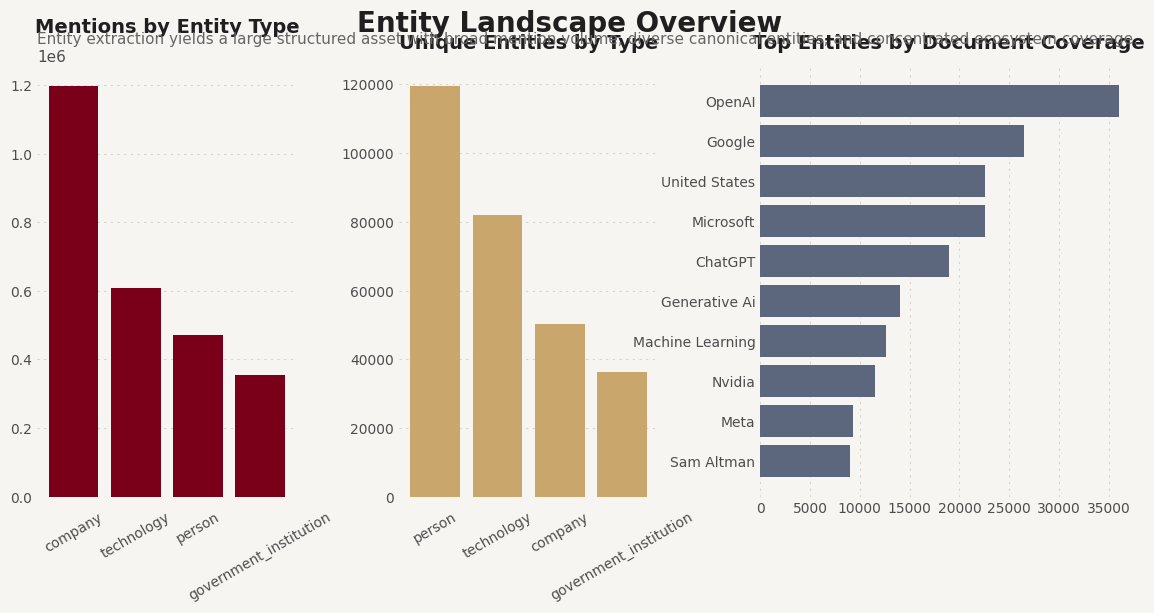

In [54]:
# ---------------------------------------------------------
# Slide 15 — Presentation-grade entity landscape overview
# ---------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np

bg = "#F7F5F2"
text_dark = "#1F1F1F"
grid = "#D8D2C8"

maroon = "#7A0019"
gold = "#C9A66B"
slate = "#5C677D"

fig = plt.figure(figsize=(14.2, 5.6), facecolor=bg)
gs = fig.add_gridspec(1, 3, width_ratios=[1.0, 1.0, 1.45], wspace=0.34)

# -----------------------------
# panel 1: mentions by type
# -----------------------------
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(bg)

ax1.bar(
    mentions_by_type["final_type"].astype(str),
    mentions_by_type["mentions"],
    color=maroon,
    edgecolor="none"
)

ax1.set_title("Mentions by Entity Type", fontsize=14, fontweight="bold", color=text_dark, pad=12)
ax1.tick_params(axis="x", rotation=30, labelsize=10, colors="#4D4D4D")
ax1.tick_params(axis="y", labelsize=10, colors="#4D4D4D", length=0)
ax1.yaxis.grid(True, linestyle=(0, (2, 4)), linewidth=0.8, color=grid)
ax1.xaxis.grid(False)
ax1.set_axisbelow(True)
for spine in ["top", "right", "left", "bottom"]:
    ax1.spines[spine].set_visible(False)

# -----------------------------
# panel 2: unique entities by type
# -----------------------------
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(bg)

ax2.bar(
    unique_by_type["final_type"].astype(str),
    unique_by_type["unique_entities"],
    color=gold,
    edgecolor="none"
)

ax2.set_title("Unique Entities by Type", fontsize=14, fontweight="bold", color=text_dark, pad=12)
ax2.tick_params(axis="x", rotation=30, labelsize=10, colors="#4D4D4D")
ax2.tick_params(axis="y", labelsize=10, colors="#4D4D4D", length=0)
ax2.yaxis.grid(True, linestyle=(0, (2, 4)), linewidth=0.8, color=grid)
ax2.xaxis.grid(False)
ax2.set_axisbelow(True)
for spine in ["top", "right", "left", "bottom"]:
    ax2.spines[spine].set_visible(False)

# -----------------------------
# panel 3: top entities by document coverage
# -----------------------------
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor(bg)

top_entities_plot = top_entities.copy()
top_entities_plot["entity_short"] = top_entities_plot["canonical_entity"].astype(str).map(
    lambda x: x if len(x) <= 22 else x[:19] + "..."
)

ax3.barh(
    top_entities_plot["entity_short"][::-1],
    top_entities_plot["n_docs"][::-1],
    color=slate,
    edgecolor="none"
)

ax3.set_title("Top Entities by Document Coverage", fontsize=14, fontweight="bold", color=text_dark, pad=12)
ax3.tick_params(axis="x", labelsize=10, colors="#4D4D4D", length=0)
ax3.tick_params(axis="y", labelsize=10, colors="#4D4D4D", length=0)
ax3.xaxis.grid(True, linestyle=(0, (2, 4)), linewidth=0.8, color=grid)
ax3.yaxis.grid(False)
ax3.set_axisbelow(True)
for spine in ["top", "right", "left", "bottom"]:
    ax3.spines[spine].set_visible(False)

# title + subtitle
fig.suptitle("Entity Landscape Overview", fontsize=20, fontweight="bold", color=text_dark, y=0.98)
fig.text(
    0.125, 0.92,
    "Entity extraction yields a large structured asset with broad mention volume, diverse canonical entities, and concentrated ecosystem coverage.",
    fontsize=11,
    color="#666666"
)

plt.tight_layout(rect=[0, 0, 1, 0.90])

save_path = FIG_DIR / "slide_15_entity_landscape_overview.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor=bg)
print("Saved:", save_path)

plt.show()

/tmp/ipykernel_6365/3478477294.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_6365/3478477294.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_6365/3478477294.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


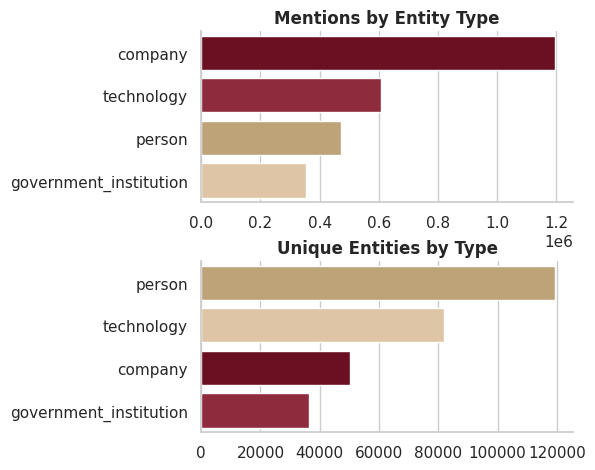

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(
    2, 1,
    figsize=(4.8, 5.2),
    gridspec_kw={"hspace":0.35}
)

# Mentions
sns.barplot(
    data=mentions_by_type,
    x="mentions",
    y="final_type",
    palette=["#7A0019","#9E1B32","#C9A66B","#E6C79C"],
    ax=axes[0]
)

axes[0].set_title("Mentions by Entity Type", fontsize=12, weight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("")
axes[0].spines[['top','right']].set_visible(False)

# Unique entities
sns.barplot(
    data=unique_by_type,
    x="unique_entities",
    y="final_type",
    palette=["#C9A66B","#E6C79C","#7A0019","#9E1B32"],
    ax=axes[1]
)

axes[1].set_title("Unique Entities by Type", fontsize=12, weight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()

In [56]:
# ---------------------------------------------------------
# Slide 16 — Load company/entity assets
# ---------------------------------------------------------

company_summary_path = BASE_DIR / "output/04_entity_extraction/04B_analysis_entities/entity_analysis_summary.parquet"
entity_sent_path = BASE_DIR / "output/05_sentiment_inference/entity_sentiment_summary.parquet"
entity_ctx_path = BASE_DIR / "output/04_entity_extraction/04B_analysis_entities/entity_contexts_final.parquet"

df_entity_summary = pd.read_parquet(company_summary_path)
df_entity_sent = pd.read_parquet(entity_sent_path)
df_entity_ctx = pd.read_parquet(entity_ctx_path)

print("entity_summary:", df_entity_summary.shape)
print(df_entity_summary.columns.tolist())
print()

print("entity_sentiment_summary:", df_entity_sent.shape)
print(df_entity_sent.columns.tolist())
print()

print("entity_contexts_final:", df_entity_ctx.shape)
print(df_entity_ctx.columns.tolist())

display(df_entity_summary.head(3))
display(df_entity_sent.head(3))
display(df_entity_ctx.head(3))

entity_summary: (288026, 7)
['canonical_entity', 'final_type', 'n_docs', 'n_rows', 'n_domains', 'confidence_mean', 'keep_for_analysis']

entity_sentiment_summary: (264291, 18)
['canonical_entity', 'final_type', 'n_rows', 'n_docs', 'n_domains', 'mention_confidence_mean', 'pred_confidence_mean', 'prob_negative_mean', 'prob_mixed_or_unclear_mean', 'prob_positive_mean', 'mixed_or_unclear', 'negative', 'positive', 'hard_label_mode', 'sentiment_index', 'directional_confidence', 'impact_score', 'abs_sentiment_index']

entity_contexts_final: (614840, 11)
['canonical_entity', 'final_type', 'domain', 'title', 'date', 'clean_block_text', 'confidence', 'doc_id', 'block_id', 'url', 'clean_block_len']


,canonical_entity,final_type,n_docs,n_rows,n_domains,confidence_mean,keep_for_analysis
0,OpenAI,company,36066,143535,2581,0.791745,True
1,Google,company,26450,95393,2436,0.830863,True
2,United States,government_institution,22616,43770,2379,0.758239,True


,canonical_entity,final_type,n_rows,n_docs,n_domains,mention_confidence_mean,pred_confidence_mean,prob_negative_mean,prob_mixed_or_unclear_mean,prob_positive_mean,mixed_or_unclear,negative,positive,hard_label_mode,sentiment_index,directional_confidence,impact_score,abs_sentiment_index
0,LLMs,technology,15,15,10,0.839356,0.810735,0.202896,0.179877,0.617227,2,2,11,positive,0.414331,0.820123,0.942131,0.414331
1,Attorney Steven Schwartz,person,8,8,8,0.881408,0.995679,0.995679,0.002651,0.001670,0,8,0,negative,-0.994009,0.997349,-2.178273,0.994009
2,Hugging Face Platform,company,8,8,8,0.711709,0.995786,0.995786,0.002434,0.001780,0,8,0,negative,-0.994006,0.997566,-2.178738,0.994006


,canonical_entity,final_type,domain,title,date,clean_block_text,confidence,doc_id,block_id,url,clean_block_len
0,#17 Mike’s Famous Philly,government_institution,businesswire.com,SoundHound And Jersey Mike’s Introduce Voice AI Phone Ordering | Business Wire,2024-01-24,"Initially live at 50 locations, SoundHound’s voice technology has been trained on the entirety of Jersey Mike’s menu – from the #17 Mike’s Famous Philly through to the #9 Club Supreme – and uses advanced AI to recognize items instantly ...",0.477525,47114,5,https://www.businesswire.com/news/home/20240124752799/en/SoundHound-And-Jersey-Mike%E2%80%99s-Introduce-Voice-AI-Phone-Ordering/?feedref=JjAwJuNHiystnCoBq_hl-d0q77hRjGWvCunvqSsMC5PkKuEqWGdtYcKRejd3o8qMqnKfqP6Z7nZVMLG-WqUNUuIFBOuQU34x9_q...,351
1,#9 Club Supreme,government_institution,businesswire.com,SoundHound And Jersey Mike’s Introduce Voice AI Phone Ordering | Business Wire,2024-01-24,"Initially live at 50 locations, SoundHound’s voice technology has been trained on the entirety of Jersey Mike’s menu – from the #17 Mike’s Famous Philly through to the #9 Club Supreme – and uses advanced AI to recognize items instantly ...",0.745871,47114,5,https://www.businesswire.com/news/home/20240124752799/en/SoundHound-And-Jersey-Mike%E2%80%99s-Introduce-Voice-AI-Phone-Ordering/?feedref=JjAwJuNHiystnCoBq_hl-d0q77hRjGWvCunvqSsMC5PkKuEqWGdtYcKRejd3o8qMqnKfqP6Z7nZVMLG-WqUNUuIFBOuQU34x9_q...,351
2,$100B+ Life Sciences Market,government_institution,finanznachrichten.de,"Super Micro Computer, Inc.: Supermicro Unveils Industry's Broadest Enterprise AI Solution Portfolio for NVIDIA Blackwell Architecture to Accelerate AI Factory Deployments in European Market",2025-06-11,"Delivers high-performing AI infrastructure through NVIDIA DGX Cloud Lepton to portfolio companies, creating a powerful competitive advantage in $100B+ life sciences market",0.454479,153982,6,https://www.finanznachrichten.de/nachrichten-2025-06/65636708-super-micro-computer-inc-supermicro-unveils-industry-s-broadest-enterprise-ai-solution-portfolio-for-nvidia-blackwell-architecture-to-accelerate-ai-008.htm,171


In [57]:
# ---------------------------------------------------------
# Slide 16 — Build company-only analysis table
# ---------------------------------------------------------

summary = df_entity_summary.copy()
sent = df_entity_sent.copy()
ctx = df_entity_ctx.copy()

# company-only + analysis-ready
summary_company = summary.loc[
    (summary["final_type"] == "company") &
    (summary["keep_for_analysis"].fillna(False))
].copy()

sent_company = sent.loc[
    sent["final_type"] == "company"
].copy()

ctx_company = ctx.loc[
    ctx["final_type"] == "company"
].copy()

# representative context count
ctx_counts = (
    ctx_company.groupby("canonical_entity")
    .size()
    .reset_index(name="representative_context_count")
)

# merge
company_tbl = (
    summary_company.merge(
        sent_company[
            [
                "canonical_entity",
                "n_rows",
                "n_docs",
                "n_domains",
                "mention_confidence_mean",
                "pred_confidence_mean",
                "prob_negative_mean",
                "prob_mixed_or_unclear_mean",
                "prob_positive_mean",
                "hard_label_mode",
                "sentiment_index",
                "directional_confidence",
                "impact_score",
                "abs_sentiment_index"
            ]
        ],
        on="canonical_entity",
        how="left",
        suffixes=("_summary", "_sent")
    )
    .merge(ctx_counts, on="canonical_entity", how="left")
)

company_tbl["representative_context_count"] = company_tbl["representative_context_count"].fillna(0)

# prefer summary-side coverage columns
company_tbl["n_docs_final"] = company_tbl["n_docs_summary"]
company_tbl["n_domains_final"] = company_tbl["n_domains_summary"]

# optional stability filter to avoid tiny weird entities
company_tbl = company_tbl.loc[company_tbl["n_docs_final"] >= 100].copy()

# final ranking
company_tbl = company_tbl.sort_values(
    ["n_docs_final", "n_domains_final", "representative_context_count"],
    ascending=[False, False, False]
).reset_index(drop=True)

display(
    company_tbl[
        [
            "canonical_entity",
            "n_docs_final",
            "n_domains_final",
            "sentiment_index",
            "impact_score",
            "representative_context_count",
            "hard_label_mode"
        ]
    ].head(15)
)

,canonical_entity,n_docs_final,n_domains_final,sentiment_index,impact_score,representative_context_count,hard_label_mode
0,OpenAI,36066,2581,NaN,NaN,8,NaN
1,Google,26450,2436,-0.017041,-0.034318,8,negative
2,Microsoft,22556,2131,0.616448,1.309446,8,positive
3,Nvidia,11569,1354,-0.060909,-0.132015,8,negative
4,Meta,9346,1561,-0.330331,-0.518767,8,negative
5,Apple,7978,1373,0.103394,0.116198,8,mixed_or_unclear
6,Amazon,7279,1434,-0.023195,-0.013150,8,mixed_or_unclear
7,Anthropic,4989,1117,0.033642,0.065971,8,positive
8,Facebook,4695,1345,-0.095079,-0.103742,8,mixed_or_unclear
9,Alphabet,3422,771,0.155310,0.260005,8,positive


In [58]:
# ---------------------------------------------------------
# Slide 16 — PPT summary table
# ---------------------------------------------------------

slide16_table = company_tbl[
    [
        "canonical_entity",
        "n_docs_final",
        "n_domains_final",
        "sentiment_index",
        "impact_score",
        "representative_context_count"
    ]
].head(8).copy()

slide16_table = slide16_table.rename(columns={
    "canonical_entity": "Company",
    "n_docs_final": "Documents",
    "n_domains_final": "Domains",
    "sentiment_index": "Sentiment Index",
    "impact_score": "Impact Score",
    "representative_context_count": "Contexts"
})

display(slide16_table)

save_table_path = TAB_DIR / "slide_16_top_companies_table.csv"
slide16_table.to_csv(save_table_path, index=False)
print("Saved:", save_table_path)

,Company,Documents,Domains,Sentiment Index,Impact Score,Contexts
0,OpenAI,36066,2581,NaN,NaN,8
1,Google,26450,2436,-0.017041,-0.034318,8
2,Microsoft,22556,2131,0.616448,1.309446,8
3,Nvidia,11569,1354,-0.060909,-0.132015,8
4,Meta,9346,1561,-0.330331,-0.518767,8
5,Apple,7978,1373,0.103394,0.116198,8
6,Amazon,7279,1434,-0.023195,-0.013150,8
7,Anthropic,4989,1117,0.033642,0.065971,8


Saved: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/tables/slide_16_top_companies_table.csv


Saved: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/figures/slide_16_top_companies_lollipop.png


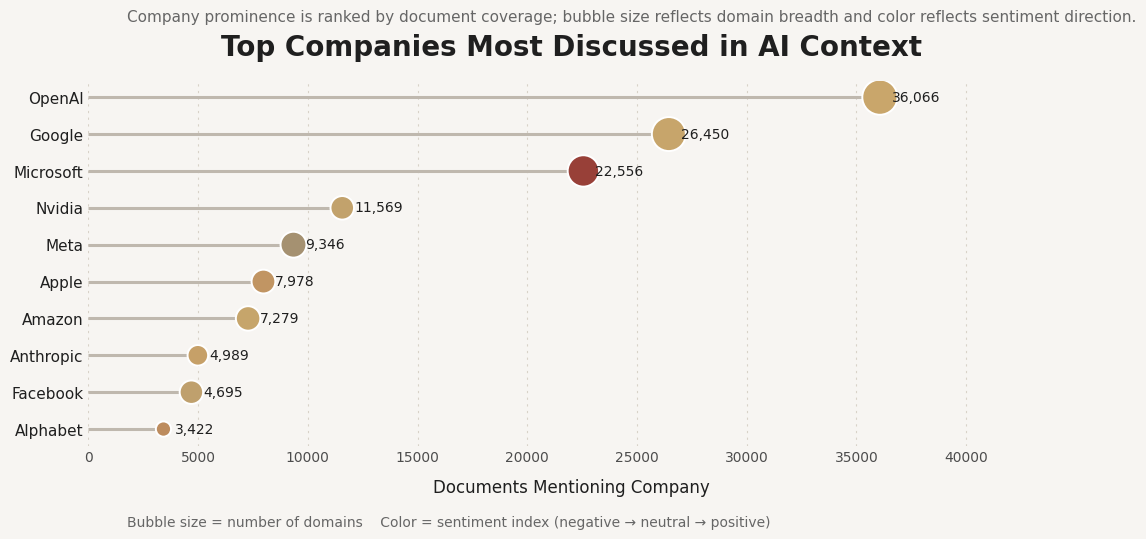

In [59]:
# ---------------------------------------------------------
# Slide 16 — Presentation-grade lollipop chart
# ---------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

plot_tbl = company_tbl.head(10).copy()

bg = "#F7F5F2"
text_dark = "#1F1F1F"
grid = "#D8D2C8"
neg_color = "#5C677D"   # slate
neu_color = "#C9A66B"   # muted gold
pos_color = "#7A0019"   # maroon

plot_tbl["company_short"] = plot_tbl["canonical_entity"].astype(str).map(
    lambda x: x if len(x) <= 22 else x[:19] + "..."
)

# bubble size = domains
dmin = plot_tbl["n_domains_final"].min()
dmax = plot_tbl["n_domains_final"].max()
if dmax > dmin:
    bubble_size = 120 + 520 * (plot_tbl["n_domains_final"] - dmin) / (dmax - dmin)
else:
    bubble_size = np.repeat(260, len(plot_tbl))

# color = sentiment index
vals = plot_tbl["sentiment_index"].fillna(0).to_numpy()

def sentiment_to_color(v, vmin=-1.0, vmax=1.0):
    v = max(vmin, min(vmax, v))
    if v < 0:
        t = (v - vmin) / (0 - vmin)
        a = np.array(mcolors.to_rgb(neg_color))
        b = np.array(mcolors.to_rgb(neu_color))
    else:
        t = (v - 0) / (vmax - 0) if vmax > 0 else 0.5
        a = np.array(mcolors.to_rgb(neu_color))
        b = np.array(mcolors.to_rgb(pos_color))
    return tuple((1 - t) * a + t * b)

colors = [sentiment_to_color(v) for v in vals]

fig, ax = plt.subplots(figsize=(10.8, 5.8), facecolor=bg)
ax.set_facecolor(bg)

y = np.arange(len(plot_tbl))[::-1]
x = plot_tbl["n_docs_final"].to_numpy()

# stems
for yi, xi in zip(y, x):
    ax.hlines(yi, 0, xi, color="#BFB8AE", linewidth=2.2, zorder=1)

# dots
ax.scatter(
    x, y,
    s=bubble_size,
    color=colors,
    edgecolor="white",
    linewidth=1.4,
    zorder=3
)

ax.set_yticks(y)
ax.set_yticklabels(plot_tbl["company_short"], fontsize=11, color=text_dark)
ax.set_xlabel("Documents Mentioning Company", fontsize=12, color=text_dark, labelpad=10)
ax.set_title("Top Companies Most Discussed in AI Context", fontsize=20, fontweight="bold", color=text_dark, pad=18)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

ax.xaxis.grid(True, linestyle=(0, (2, 4)), linewidth=0.8, color=grid)
ax.yaxis.grid(False)
ax.set_axisbelow(True)
ax.tick_params(axis="x", labelsize=10, colors="#4D4D4D", length=0)
ax.tick_params(axis="y", length=0)

# value labels
xmax = x.max()
for yi, xi in zip(y, x):
    ax.text(
        xi + xmax * 0.015,
        yi,
        f"{xi:,.0f}",
        va="center",
        ha="left",
        fontsize=10,
        color=text_dark
    )

# subtitle
fig.text(
    0.125, 0.91,
    "Company prominence is ranked by document coverage; bubble size reflects domain breadth and color reflects sentiment direction.",
    fontsize=11,
    color="#666666"
)

# simple legend as caption-like text
fig.text(0.125, 0.04, "Bubble size = number of domains    Color = sentiment index (negative → neutral → positive)", fontsize=10, color="#666666")

ax.set_xlim(0, xmax * 1.22)

plt.tight_layout(rect=[0, 0.06, 1, 0.92])

save_path = FIG_DIR / "slide_16_top_companies_lollipop.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor=bg)
print("Saved:", save_path)

plt.show()

In [60]:
# ---------------------------------------------------------
# Slide 17 — Build top technology table
# ---------------------------------------------------------

summary = df_entity_summary.copy()
sent = df_entity_sent.copy()
ctx = df_entity_ctx.copy()

# technology-only + analysis-ready
summary_tech = summary.loc[
    (summary["final_type"] == "technology") &
    (summary["keep_for_analysis"].fillna(False))
].copy()

sent_tech = sent.loc[
    sent["final_type"] == "technology"
].copy()

ctx_tech = ctx.loc[
    ctx["final_type"] == "technology"
].copy()

# representative context count
ctx_counts = (
    ctx_tech.groupby("canonical_entity")
    .size()
    .reset_index(name="representative_context_count")
)

# merge
tech_tbl = (
    summary_tech.merge(
        sent_tech[
            [
                "canonical_entity",
                "n_rows",
                "n_docs",
                "n_domains",
                "prob_negative_mean",
                "prob_mixed_or_unclear_mean",
                "prob_positive_mean",
                "hard_label_mode",
                "sentiment_index",
                "directional_confidence",
                "impact_score",
                "abs_sentiment_index"
            ]
        ],
        on="canonical_entity",
        how="left",
        suffixes=("_summary", "_sent")
    )
    .merge(ctx_counts, on="canonical_entity", how="left")
)

tech_tbl["representative_context_count"] = tech_tbl["representative_context_count"].fillna(0)
tech_tbl["n_docs_final"] = tech_tbl["n_docs_summary"]
tech_tbl["n_domains_final"] = tech_tbl["n_domains_summary"]

# optional minimum threshold
tech_tbl = tech_tbl.loc[tech_tbl["n_docs_final"] >= 100].copy()

# ranking
tech_tbl = tech_tbl.sort_values(
    ["n_docs_final", "impact_score", "n_domains_final"],
    ascending=[False, False, False]
).reset_index(drop=True)

display(
    tech_tbl[
        [
            "canonical_entity",
            "n_docs_final",
            "impact_score",
            "prob_positive_mean",
            "prob_mixed_or_unclear_mean",
            "prob_negative_mean",
            "representative_context_count"
        ]
    ].head(15)
)

,canonical_entity,n_docs_final,impact_score,prob_positive_mean,prob_mixed_or_unclear_mean,prob_negative_mean,representative_context_count
0,ChatGPT,18994,NaN,NaN,NaN,NaN,8
1,Generative Ai,14046,0.416332,0.474162,0.337827,0.188011,8
2,Machine Learning,12633,0.153683,0.267821,0.689942,0.042237,8
3,GPT-4,3950,1.051650,0.731925,0.094933,0.173142,8
4,Gemini,3212,0.664802,0.581942,0.228077,0.189980,8
5,Chatbots,3170,0.917631,0.687213,0.136793,0.175994,8
6,Llms,2798,NaN,NaN,NaN,NaN,8
7,AI Agents,2693,1.115959,0.759648,0.180561,0.059791,8
8,Large Language Models,2611,-0.048351,0.022790,0.827126,0.150084,8
9,Bard,2409,0.902706,0.700366,0.136496,0.163137,8


In [61]:
# ---------------------------------------------------------
# Slide 17 — Display names
# ---------------------------------------------------------

tech_display_map = {
    "Chatgpt": "ChatGPT",
    "Generative Ai": "Generative AI",
    "Machine Learning": "Machine Learning",
    "GPT-4": "GPT-4",
    "LLMs": "LLMs",
    "Artificial Intelligence": "Artificial Intelligence",
    "Computer Vision": "Computer Vision",
    "Deep Learning": "Deep Learning",
    "Large Language Models": "Large Language Models",
}

tech_tbl["display_name"] = tech_tbl["canonical_entity"].replace(tech_display_map)
tech_tbl["display_name"] = tech_tbl["display_name"].fillna(tech_tbl["canonical_entity"])

In [62]:
# ---------------------------------------------------------
# Slide 17 — PPT summary table
# ---------------------------------------------------------

slide17_table = tech_tbl[
    [
        "display_name",
        "n_docs_final",
        "impact_score",
        "prob_positive_mean",
        "prob_mixed_or_unclear_mean",
        "prob_negative_mean"
    ]
].head(8).copy()

slide17_table = slide17_table.rename(columns={
    "display_name": "Technology",
    "n_docs_final": "Docs",
    "impact_score": "Impact",
    "prob_positive_mean": "Positive",
    "prob_mixed_or_unclear_mean": "Mixed",
    "prob_negative_mean": "Negative"
})

# prettier formatting
for col in ["Impact", "Positive", "Mixed", "Negative"]:
    slide17_table[col] = slide17_table[col].round(2)

display(slide17_table)

save_table_path = TAB_DIR / "slide_17_top_technologies_table.csv"
slide17_table.to_csv(save_table_path, index=False)
print("Saved:", save_table_path)

,Technology,Docs,Impact,Positive,Mixed,Negative
0,ChatGPT,18994,NaN,NaN,NaN,NaN
1,Generative AI,14046,0.42,0.47,0.34,0.19
2,Machine Learning,12633,0.15,0.27,0.69,0.04
3,GPT-4,3950,1.05,0.73,0.09,0.17
4,Gemini,3212,0.66,0.58,0.23,0.19
5,Chatbots,3170,0.92,0.69,0.14,0.18
6,Llms,2798,NaN,NaN,NaN,NaN
7,AI Agents,2693,1.12,0.76,0.18,0.06


Saved: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/tables/slide_17_top_technologies_table.csv


In [65]:
drop_tech = {"GPT-4", "Gemini", "Bard"}
tech_tbl = tech_tbl.loc[
    tech_tbl["display_name"].notna() &
    tech_tbl["impact_score"].notna() &
    (~tech_tbl["display_name"].isin(drop_tech))
].copy()

tech_tbl["display_name"] = tech_tbl["display_name"].replace({
    "Llms": "LLMs"
})

Saved: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/figures/slide_17_top_technologies_bar.png


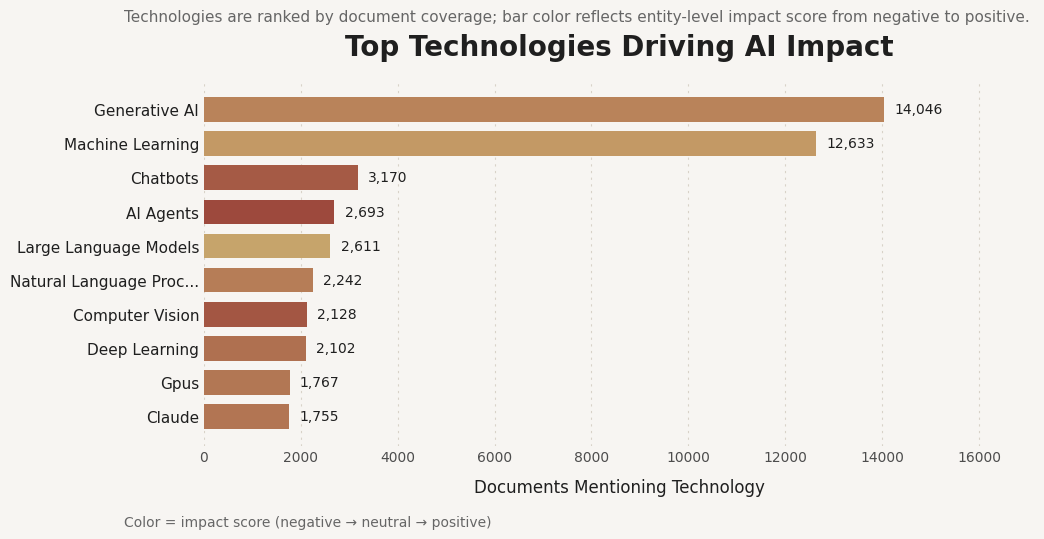

In [66]:
# ---------------------------------------------------------
# Slide 17 — Presentation-grade technology impact chart
# ---------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

plot_tbl = tech_tbl.head(10).copy()

bg = "#F7F5F2"
text_dark = "#1F1F1F"
grid = "#D8D2C8"
neg_color = "#5C677D"   # slate
neu_color = "#C9A66B"   # muted gold
pos_color = "#7A0019"   # maroon

plot_tbl["tech_short"] = plot_tbl["display_name"].astype(str).map(
    lambda x: x if len(x) <= 24 else x[:21] + "..."
)

vals = plot_tbl["impact_score"].fillna(0).to_numpy()

def impact_to_color(v, vmin=-2.0, vmax=2.0):
    v = max(vmin, min(vmax, v))
    if v < 0:
        t = (v - vmin) / (0 - vmin)
        a = np.array(mcolors.to_rgb(neg_color))
        b = np.array(mcolors.to_rgb(neu_color))
    else:
        t = (v - 0) / (vmax - 0) if vmax > 0 else 0.5
        a = np.array(mcolors.to_rgb(neu_color))
        b = np.array(mcolors.to_rgb(pos_color))
    return tuple((1 - t) * a + t * b)

colors = [impact_to_color(v) for v in vals]

fig, ax = plt.subplots(figsize=(10.6, 5.8), facecolor=bg)
ax.set_facecolor(bg)

y = np.arange(len(plot_tbl))[::-1]
x = plot_tbl["n_docs_final"].to_numpy()

bars = ax.barh(
    y, x,
    color=colors,
    edgecolor="none",
    height=0.72
)

ax.set_yticks(y)
ax.set_yticklabels(plot_tbl["tech_short"], fontsize=11, color=text_dark)
ax.set_xlabel("Documents Mentioning Technology", fontsize=12, color=text_dark, labelpad=10)
ax.set_title("Top Technologies Driving AI Impact", fontsize=20, fontweight="bold", color=text_dark, pad=18)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

ax.xaxis.grid(True, linestyle=(0, (2, 4)), linewidth=0.8, color=grid)
ax.yaxis.grid(False)
ax.set_axisbelow(True)
ax.tick_params(axis="x", labelsize=10, colors="#4D4D4D", length=0)
ax.tick_params(axis="y", length=0)

xmax = x.max()
for yi, xi in zip(y, x):
    ax.text(
        xi + xmax * 0.015,
        yi,
        f"{xi:,.0f}",
        va="center",
        ha="left",
        fontsize=10,
        color=text_dark
    )

fig.text(
    0.125, 0.91,
    "Technologies are ranked by document coverage; bar color reflects entity-level impact score from negative to positive.",
    fontsize=11,
    color="#666666"
)

fig.text(
    0.125, 0.04,
    "Color = impact score (negative → neutral → positive)",
    fontsize=10,
    color="#666666"
)

ax.set_xlim(0, xmax * 1.22)

plt.tight_layout(rect=[0, 0.06, 1, 0.92])

save_path = FIG_DIR / "slide_17_top_technologies_bar.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor=bg)
print("Saved:", save_path)

plt.show()

In [67]:
# ---------------------------------------------------------
# Slide 19 — Load validation predictions
# ---------------------------------------------------------

val_pred_path = BASE_DIR / "output/05_sentiment_model/validation_predictions.parquet"
df_val = pd.read_parquet(val_pred_path)

print("validation_predictions shape:", df_val.shape)
print("columns:", df_val.columns.tolist())

display(df_val.head(5))

validation_predictions shape: (1625, 33)
columns: ['sample_id', 'sample_source', 'doc_id', 'block_id', 'date', 'time_bucket', 'domain', 'title', 'url', 'canonical_entity', 'canonical_key', 'final_type', 'context_text', 'n_docs', 'n_rows', 'n_domains', 'confidence_mean', 'entity_doc_bucket', 'sentiment_label', 'confidence', 'reason_short', 'model_input', 'label_id', 'entity_group_id', 'input_hash', 'pred_id', 'pred_label', 'true_label', 'pred_confidence', 'prob_positive', 'prob_negative', 'prob_mixed_or_unclear', 'is_correct']


,sample_id,sample_source,doc_id,block_id,date,time_bucket,domain,title,url,canonical_entity,...,entity_group_id,input_hash,pred_id,pred_label,true_label,pred_confidence,prob_positive,prob_negative,prob_mixed_or_unclear,is_correct
0,23534||3||howard lutnick||person,person_stratified_context_pool,23534,3,2025-01-30,2025Q1,devdiscourse.com,Commerce Nominee's Tough Stance on Trade and AI | Education,https://www.devdiscourse.com/article/education/3244833-commerce-nominees-tough-stance-on-trade-and-ai,Howard Lutnick,...,howard lutnick|||person,056059283a74f83f93c10fef2b8893c595f7f708,0,positive,mixed_or_unclear,0.411515,0.411515,0.223191,0.365294,False
1,14701||10||sora 2||technology,technology_stratified_context_pool,14701,10,2025-10-09,2025Q4,tolerance.ca,Tolerance.ca® - OpenAI’s newly launched Sora 2 makes AI’s environmental impact impossible to ignore,https://www.tolerance.ca/ArticleExt.aspx?ID=589498&L=en,Sora 2,...,sora 2|||technology,78e3d78da331536e67831c16ffa5d5f7cf55a376,0,positive,negative,0.412586,0.412586,0.214675,0.372740,False
2,134639||10||deepfake||technology,technology_stratified_context_pool,134639,10,2024-05-02,2024Q2,zawya.com,931 tertiary education scholars trained in Artificial Intelligence — Nigeria,https://www.zawya.com/en/world/africa/931-tertiary-education-scholars-trained-in-artificial-intelligence-nigeria-h9o4twnb,Deepfake,...,deepfake|||technology,3982acef51ec1c28265cd7d066f6258869d909b5,1,negative,positive,0.450264,0.282181,0.450264,0.267555,False
3,193420||6||cloud computing||technology,technology_stratified_context_pool,193420,6,2024-11-25,2024Q4,breitbart.com,A Single AI Data Center Could Soon Consume Twice the Electricity of Pittsburgh,https://www.breitbart.com/tech/2024/11/25/a-single-ai-data-center-could-soon-consume-twice-the-electricity-of-pittsburgh/,Cloud Computing,...,cloud computing|||technology,133370492d0b8d1c31b6f1502fc5fef1334bd2be,2,mixed_or_unclear,negative,0.455395,0.202278,0.342327,0.455395,False
4,126137||13||wi fi||technology,technology_stratified_context_pool,126137,13,2023-07-18,2023Q3,stuff.tv,Volumio Integro streamer uses AI to choose your tunes | Stuff,https://www.stuff.tv/hot-stuff/volumio-integro-streamer-uses-ai-to-choose-your-tunes/,Wi-Fi,...,wi-fi|||technology,2034883558201d93117bf1f01cfb482e36044686,0,positive,mixed_or_unclear,0.467479,0.467479,0.089920,0.442601,False


In [68]:
# ---------------------------------------------------------
# Detect evaluation columns
# ---------------------------------------------------------

true_col_candidates = ["true_label", "gold_label", "label", "y_true"]
pred_col_candidates = ["pred_label", "pred_sentiment_label", "prediction", "y_pred", "hard_label_mode"]
type_col_candidates = ["final_type", "entity_type", "type"]

true_col = next((c for c in true_col_candidates if c in df_val.columns), None)
pred_col = next((c for c in pred_col_candidates if c in df_val.columns), None)
type_col = next((c for c in type_col_candidates if c in df_val.columns), None)

assert true_col is not None, f"No ground-truth label column found. Columns: {df_val.columns.tolist()}"
assert pred_col is not None, f"No prediction column found. Columns: {df_val.columns.tolist()}"

print("true label column:", true_col)
print("prediction column:", pred_col)
print("type column:", type_col)

true label column: true_label
prediction column: pred_label
type column: final_type


In [69]:
# ---------------------------------------------------------
# Normalize labels and compute metrics
# ---------------------------------------------------------

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import numpy as np

def normalize_label(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    mapping = {
        "pos": "positive",
        "positive": "positive",
        "1": "positive",
        "mix": "mixed_or_unclear",
        "mixed": "mixed_or_unclear",
        "mixed_or_unclear": "mixed_or_unclear",
        "mixed/unclear": "mixed_or_unclear",
        "unclear": "mixed_or_unclear",
        "neutral": "mixed_or_unclear",
        "0": "mixed_or_unclear",
        "neg": "negative",
        "negative": "negative",
        "-1": "negative",
    }
    return mapping.get(s, s)

df_eval = df_val.copy()
df_eval["true_norm"] = df_eval[true_col].map(normalize_label)
df_eval["pred_norm"] = df_eval[pred_col].map(normalize_label)

df_eval = df_eval.dropna(subset=["true_norm", "pred_norm"]).copy()

labels = ["positive", "mixed_or_unclear", "negative"]

accuracy = accuracy_score(df_eval["true_norm"], df_eval["pred_norm"])
macro_f1 = f1_score(df_eval["true_norm"], df_eval["pred_norm"], average="macro")
weighted_f1 = f1_score(df_eval["true_norm"], df_eval["pred_norm"], average="weighted")
cm = confusion_matrix(df_eval["true_norm"], df_eval["pred_norm"], labels=labels)

print("Accuracy:", accuracy)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)
print("Eval samples:", len(df_eval))
print(cm)

Accuracy: 0.8541538461538462
Macro F1: 0.8244049281569065
Weighted F1: 0.8552139050224516
Eval samples: 1625
[[861  87  12]
 [ 64 355  53]
 [  1  20 172]]


In [70]:
# ---------------------------------------------------------
# By-type performance
# ---------------------------------------------------------

by_type = None

if type_col is not None:
    by_type = (
        df_eval.groupby(type_col)
        .apply(lambda x: f1_score(x["true_norm"], x["pred_norm"], average="macro"))
        .reset_index(name="macro_f1")
        .sort_values("macro_f1", ascending=False)
    )
    display(by_type)
else:
    print("No entity type column found in validation predictions; skipping by-type performance.")

/tmp/ipykernel_6365/261781757.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: f1_score(x["true_norm"], x["pred_norm"], average="macro"))


,final_type,macro_f1
1,government_institution,0.839563
0,company,0.823511
3,technology,0.822643
2,person,0.794859


/tmp/ipykernel_6365/2175356962.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.91])


Saved: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/figures/slide_19_sentiment_model_performance.png


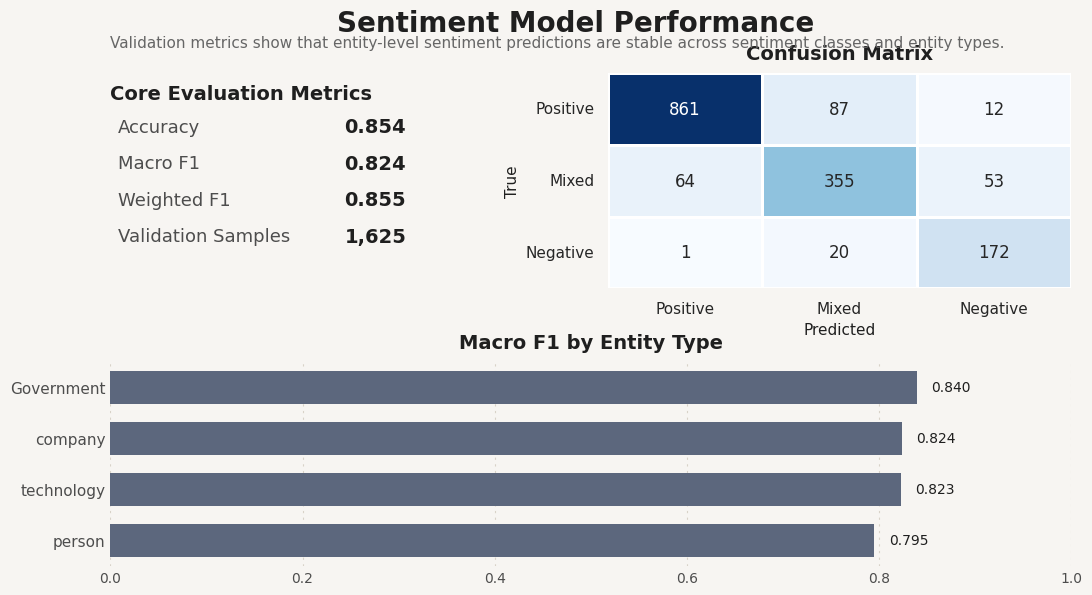

In [71]:
# ---------------------------------------------------------
# Slide 19 — PPT-ready performance panel
# ---------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

bg = "#F7F5F2"
text_dark = "#1F1F1F"
grid = "#D8D2C8"
maroon = "#7A0019"
gold = "#C9A66B"
slate = "#5C677D"

fig = plt.figure(figsize=(12.4, 6.4), facecolor=bg)
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 0.95], width_ratios=[0.9, 1.1], hspace=0.35, wspace=0.28)

# -----------------------------
# panel 1: metrics box
# -----------------------------
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(bg)
ax1.axis("off")

metrics_lines = [
    ("Accuracy", f"{accuracy:.3f}"),
    ("Macro F1", f"{macro_f1:.3f}"),
    ("Weighted F1", f"{weighted_f1:.3f}"),
    ("Validation Samples", f"{len(df_eval):,}")
]

ax1.text(0.00, 0.95, "Core Evaluation Metrics", fontsize=14, fontweight="bold", color=text_dark, va="top")

y = 0.75
for k, v in metrics_lines:
    ax1.text(0.02, y, k, fontsize=13, color="#4D4D4D", va="center")
    ax1.text(0.78, y, v, fontsize=14, fontweight="bold", color=text_dark, va="center", ha="right")
    y -= 0.17

# -----------------------------
# panel 2: confusion matrix
# -----------------------------
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(bg)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.8,
    linecolor="white",
    xticklabels=["Positive", "Mixed", "Negative"],
    yticklabels=["Positive", "Mixed", "Negative"],
    ax=ax2
)

ax2.set_title("Confusion Matrix", fontsize=14, fontweight="bold", color=text_dark, pad=10)
ax2.set_xlabel("Predicted", fontsize=11, color=text_dark)
ax2.set_ylabel("True", fontsize=11, color=text_dark)
ax2.tick_params(axis="x", labelrotation=0)
ax2.tick_params(axis="y", labelrotation=0)

# -----------------------------
# panel 3: by-type performance
# -----------------------------
ax3 = fig.add_subplot(gs[1, :])
ax3.set_facecolor(bg)

if by_type is not None and len(by_type) > 0:
    by_type_plot = by_type.copy()
    by_type_plot[type_col] = by_type_plot[type_col].astype(str).replace({
        "government_institution": "Government"
    })

    ax3.barh(
        by_type_plot[type_col][::-1],
        by_type_plot["macro_f1"][::-1],
        color=slate,
        edgecolor="none",
        height=0.65
    )

    ax3.set_title("Macro F1 by Entity Type", fontsize=14, fontweight="bold", color=text_dark, pad=10)
    ax3.set_xlim(0, 1.0)

    for i, v in enumerate(by_type_plot["macro_f1"][::-1]):
        ax3.text(v + 0.015, i, f"{v:.3f}", va="center", ha="left", fontsize=10, color=text_dark)

    ax3.xaxis.grid(True, linestyle=(0, (2, 4)), linewidth=0.8, color=grid)
    ax3.yaxis.grid(False)
    ax3.set_axisbelow(True)
    ax3.tick_params(axis="x", labelsize=10, colors="#4D4D4D", length=0)
    ax3.tick_params(axis="y", labelsize=11, colors="#4D4D4D", length=0)

    for spine in ["top", "right", "left", "bottom"]:
        ax3.spines[spine].set_visible(False)
else:
    ax3.axis("off")
    ax3.text(0.0, 0.8, "By-type performance unavailable in validation predictions.", fontsize=12, color="#666666")

# overall title
fig.suptitle("Sentiment Model Performance", fontsize=20, fontweight="bold", color=text_dark, y=0.98)
fig.text(
    0.125, 0.92,
    "Validation metrics show that entity-level sentiment predictions are stable across sentiment classes and entity types.",
    fontsize=11,
    color="#666666"
)

plt.tight_layout(rect=[0, 0, 1, 0.91])

save_path = FIG_DIR / "slide_19_sentiment_model_performance.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor=bg)
print("Saved:", save_path)

plt.show()

In [72]:
# ---------------------------------------------------------
# Slide 20 — Overall sentiment distribution
# ---------------------------------------------------------

pred_path = BASE_DIR / "output/05_sentiment_inference/entity_context_sentiment_predictions.parquet"
df_pred = pd.read_parquet(pred_path)

print("shape:", df_pred.shape)
print("columns:", df_pred.columns.tolist())

display(df_pred.head(3))

shape: (560998, 19)
columns: ['row_uid', 'doc_id', 'block_id', 'date', 'year_month', 'domain', 'title', 'url', 'canonical_entity', 'final_type', 'mention_confidence', 'context_text', 'pred_label_id', 'pred_sentiment_label', 'pred_confidence', 'pred_margin', 'prob_negative', 'prob_mixed_or_unclear', 'prob_positive']


,row_uid,doc_id,block_id,date,year_month,domain,title,url,canonical_entity,final_type,mention_confidence,context_text,pred_label_id,pred_sentiment_label,pred_confidence,pred_margin,prob_negative,prob_mixed_or_unclear,prob_positive
0,32770||1||SABI AI Corp||company||0,32770,1,2022-03-21,2022-03,uppermichiganssource.com,Skin Inc Supplement Bar in Collaboration with +SABI AI Corp Unveils the World's First 360 Wellness and Skin Health Coach App,https://www.uppermichiganssource.com/prnewswire/2022/03/21/skin-inc-supplement-bar-collaboration-with-sabi-ai-corp-unveils-worlds-first-360-wellness-skin-health-coach-app/,SABI AI Corp,company,0.706290,"Mar. 21, 2022 at 7:00 AM EDT|Updated: 1 hour agoLaunches with New Tri-light Skintech Device SINGAPORE & NEW YORK, March 21, 2022 /PRNewswire/ -- Skin Inc Supplement Bar, the global leader in data-driven, customized skin-tech products an...",0,positive,0.923650,0.869887,0.053763,0.022587,0.923650
1,82917||1||SABI AI Corp||company||0,82917,1,2022-03-21,2022-03,wdtv.com,Skin Inc Supplement Bar in Collaboration with +SABI AI Corp Unveils the World's First 360 Wellness and Skin Health Coach App,https://www.wdtv.com/prnewswire/2022/03/21/skin-inc-supplement-bar-collaboration-with-sabi-ai-corp-unveils-worlds-first-360-wellness-skin-health-coach-app/,SABI AI Corp,company,0.706290,"Mar. 21, 2022 at 7:00 AM EDT|Updated: 1 hour agoLaunches with New Tri-light Skintech Device SINGAPORE & NEW YORK, March 21, 2022 /PRNewswire/ -- Skin Inc Supplement Bar, the global leader in data-driven, customized skin-tech products an...",0,positive,0.923455,0.869493,0.053962,0.022583,0.923455
2,197140||1||SABI AI Corp||company||0,197140,1,2022-03-21,2022-03,walb.com,Skin Inc Supplement Bar in Collaboration with +SABI AI Corp Unveils the World's First 360 Wellness and Skin Health Coach App,https://www.walb.com/prnewswire/2022/03/21/skin-inc-supplement-bar-collaboration-with-sabi-ai-corp-unveils-worlds-first-360-wellness-skin-health-coach-app/,SABI AI Corp,company,0.705873,"Mar. 21, 2022 at 7:00 AM EDT|Updated: 58 minutes agoLaunches with New Tri-light Skintech Device SINGAPORE & NEW YORK, March 21, 2022 /PRNewswire/ -- Skin Inc Supplement Bar, the global leader in data-driven, customized skin-tech product...",0,positive,0.924199,0.870823,0.053376,0.022425,0.924199


In [73]:
# ---------------------------------------------------------
# Overall distribution
# ---------------------------------------------------------

overall_dist = (
    df_pred["pred_sentiment_label"]
    .value_counts(dropna=False)
    .rename_axis("sentiment")
    .reset_index(name="n_rows")
)

overall_dist["share"] = overall_dist["n_rows"] / overall_dist["n_rows"].sum()

label_order = ["positive", "mixed_or_unclear", "negative"]
overall_dist["sentiment"] = pd.Categorical(
    overall_dist["sentiment"],
    categories=label_order,
    ordered=True
)
overall_dist = overall_dist.sort_values("sentiment").reset_index(drop=True)

display(overall_dist)

,sentiment,n_rows,share
0,positive,330451,0.589041
1,mixed_or_unclear,172097,0.306769
2,negative,58450,0.104189


In [74]:
# ---------------------------------------------------------
# By entity type
# ---------------------------------------------------------

by_type = (
    df_pred.groupby(["final_type", "pred_sentiment_label"])
    .size()
    .reset_index(name="n_rows")
)

by_type["type_total"] = by_type.groupby("final_type")["n_rows"].transform("sum")
by_type["share"] = by_type["n_rows"] / by_type["type_total"]

by_type["pred_sentiment_label"] = pd.Categorical(
    by_type["pred_sentiment_label"],
    categories=label_order,
    ordered=True
)

by_type = by_type.sort_values(["final_type", "pred_sentiment_label"]).reset_index(drop=True)

display(by_type.head(12))

,final_type,pred_sentiment_label,n_rows,type_total,share
0,company,positive,98308,131873,0.745475
1,company,mixed_or_unclear,27313,131873,0.207116
2,company,negative,6252,131873,0.047409
3,government_institution,positive,35576,73583,0.483481
4,government_institution,mixed_or_unclear,27448,73583,0.373021
5,government_institution,negative,10559,73583,0.143498
6,person,positive,94968,208911,0.454586
7,person,mixed_or_unclear,84015,208911,0.402157
8,person,negative,29928,208911,0.143257
9,technology,positive,101599,146631,0.692889


/tmp/ipykernel_6365/1065283439.py:133: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


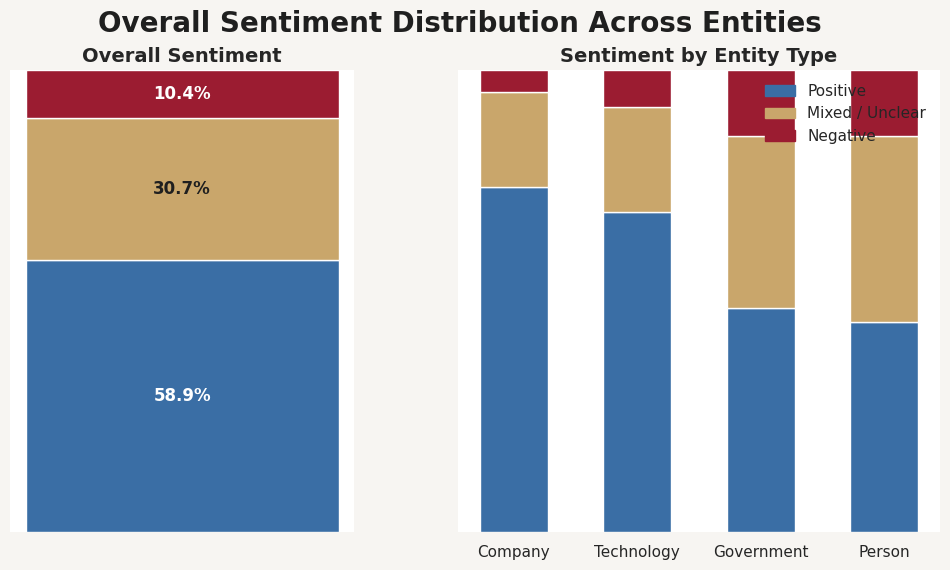

In [75]:
# ---------------------------------------------------------
# Slide 20 — Improved sentiment distribution figure
# ---------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

bg = "#F7F5F2"
text_dark = "#1F1F1F"

# 更直觉的颜色
palette = {
    "positive": "#3A6EA5",
    "mixed_or_unclear": "#C9A66B",
    "negative": "#9B1C31"
}

pretty = {
    "positive": "Positive",
    "mixed_or_unclear": "Mixed / Unclear",
    "negative": "Negative",
    "company": "Company",
    "technology": "Technology",
    "government_institution": "Government",
    "person": "Person"
}

fig = plt.figure(figsize=(12,6), facecolor=bg)
gs = fig.add_gridspec(1,2, width_ratios=[1,1.4], wspace=0.25)

# ---------------------------------------------------------
# LEFT: overall vertical stacked bar
# ---------------------------------------------------------

ax1 = fig.add_subplot(gs[0,0])

bottom = 0

for s in ["positive","mixed_or_unclear","negative"]:
    share = overall_dist.loc[overall_dist.sentiment==s,"share"].values[0]

    ax1.bar(
        "Overall",
        share,
        bottom=bottom,
        color=palette[s],
        width=0.55,
        edgecolor="white"
    )

    ax1.text(
        0,
        bottom + share/2,
        f"{share:.1%}",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        color="white" if s!="mixed_or_unclear" else text_dark
    )

    bottom += share

ax1.set_ylim(0,1)
ax1.set_title("Overall Sentiment",fontsize=14,fontweight="bold")

ax1.set_xticks([])
ax1.set_yticks([])

for spine in ax1.spines.values():
    spine.set_visible(False)

# ---------------------------------------------------------
# RIGHT: entity type vertical bars
# ---------------------------------------------------------

ax2 = fig.add_subplot(gs[0,1])

types = ["company","technology","government_institution","person"]

for i,t in enumerate(types):

    subset = by_type[by_type.final_type==t]

    bottom = 0

    for s in ["positive","mixed_or_unclear","negative"]:

        share = subset.loc[
            subset.pred_sentiment_label==s,"share"
        ].values[0]

        ax2.bar(
            pretty[t],
            share,
            bottom=bottom,
            color=palette[s],
            width=0.55,
            edgecolor="white"
        )

        bottom += share

ax2.set_ylim(0,1)
ax2.set_title("Sentiment by Entity Type",fontsize=14,fontweight="bold")

ax2.set_yticks([])
for spine in ax2.spines.values():
    spine.set_visible(False)

# legend
handles = [
    plt.Rectangle((0,0),1,1,color=palette[s])
    for s in ["positive","mixed_or_unclear","negative"]
]

ax2.legend(
    handles,
    [pretty[s] for s in ["positive","mixed_or_unclear","negative"]],
    frameon=False,
    loc="upper right"
)

# title
fig.suptitle(
    "Overall Sentiment Distribution Across Entities",
    fontsize=20,
    fontweight="bold",
    color=text_dark
)

plt.tight_layout()

save_path = FIG_DIR / "slide_20_sentiment_distribution_improved.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor=bg)

plt.show()

In [76]:
# ---------------------------------------------------------
# Slide 21 — Recover dominant doc-topic table from Stage 03
# ---------------------------------------------------------

from pathlib import Path
import pandas as pd

topic_dir = BASE_DIR / "output" / "03_topic_modeling"

# 1) try to find a precomputed dominant doc-topic file
candidate_files = []
for pattern in [
    "*dominant*topic*.parquet",
    "*dominant*topic*.csv",
    "*doc*topic*.parquet",
    "*doc*topic*.csv",
]:
    candidate_files.extend(topic_dir.rglob(pattern))

candidate_files = sorted(set(candidate_files))
print("Topic candidates:")
for p in candidate_files:
    print(p)

dominant_doc_topic = None

# Prefer files that look like dominant doc-topic outputs
preferred = [p for p in candidate_files if "dominant" in p.name.lower()]
fallbacks = [p for p in candidate_files if p not in preferred]

for p in preferred + fallbacks:
    try:
        if p.suffix.lower() == ".parquet":
            tmp = pd.read_parquet(p)
        else:
            tmp = pd.read_csv(p)

        print("\nLoaded:", p)
        print("shape:", tmp.shape)
        print("columns:", tmp.columns.tolist())

        # Need at least doc_id + topic_id
        if {"doc_id", "topic_id"}.issubset(tmp.columns):
            dominant_doc_topic = tmp.copy()
            break
    except Exception as e:
        print("skip:", p, "|", e)

# 2) if still missing, rebuild from df_doc_topics file
if dominant_doc_topic is None:
    doc_topic_candidates = []
    for pattern in ["*doc_topics*.parquet", "*doc_topics*.csv"]:
        doc_topic_candidates.extend(topic_dir.rglob(pattern))

    doc_topic_candidates = sorted(set(doc_topic_candidates))
    print("\nDoc-topic candidates for rebuild:")
    for p in doc_topic_candidates:
        print(p)

    df_doc_topics = None
    for p in doc_topic_candidates:
        try:
            if p.suffix.lower() == ".parquet":
                tmp = pd.read_parquet(p)
            else:
                tmp = pd.read_csv(p)

            print("\nLoaded doc-topics:", p)
            print("shape:", tmp.shape)
            print("columns:", tmp.columns.tolist())

            if {"doc_id", "topic_id"}.issubset(tmp.columns):
                df_doc_topics = tmp.copy()
                break
        except Exception as e:
            print("skip:", p, "|", e)

    assert df_doc_topics is not None, "Could not locate any doc-topic output in 03_topic_modeling."

    # Rebuild dominant doc-topic:
    # prefer highest topic_block_share_within_doc, then mean_topic_prob, then n_blocks
    sort_cols = [c for c in [
        "topic_block_share_within_doc",
        "mean_topic_prob",
        "n_blocks"
    ] if c in df_doc_topics.columns]

    assert sort_cols, "df_doc_topics found, but no ranking columns available to rebuild dominant topics."

    dominant_doc_topic = (
        df_doc_topics
        .sort_values(sort_cols, ascending=[False] * len(sort_cols))
        .drop_duplicates(subset=["doc_id"], keep="first")
        .copy()
    )

    print("\nRebuilt dominant_doc_topic from df_doc_topics.")

print("\ndominant_doc_topic shape:", dominant_doc_topic.shape)
print("columns:", dominant_doc_topic.columns.tolist())
display(dominant_doc_topic.head(5))

Topic candidates:
/content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/output/03_topic_modeling/docs_with_topic_distribution.parquet

Loaded: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/output/03_topic_modeling/docs_with_topic_distribution.parquet
shape: (271309, 9)
columns: ['doc_id', 'topic_id', 'n_blocks', 'n_domains', 'mean_topic_prob', 'mean_block_len', 'sum_topic_text_len', 'doc_topic_total_blocks', 'topic_block_share_within_doc']

dominant_doc_topic shape: (271309, 9)
columns: ['doc_id', 'topic_id', 'n_blocks', 'n_domains', 'mean_topic_prob', 'mean_block_len', 'sum_topic_text_len', 'doc_topic_total_blocks', 'topic_block_share_within_doc']


,doc_id,topic_id,n_blocks,n_domains,mean_topic_prob,mean_block_len,sum_topic_text_len,doc_topic_total_blocks,topic_block_share_within_doc
0,0,10,1,1,0.88899,1977.000000,1977,1,1.0
1,1,-1,3,1,0.00000,429.333333,1288,3,1.0
2,2,-1,3,1,0.00000,677.000000,2031,3,1.0
3,3,-1,1,1,0.00000,3325.000000,3325,1,1.0
4,4,-1,1,1,0.00000,3705.000000,3705,1,1.0


In [77]:
# ---------------------------------------------------------
# Slide 21 — Rebuild topic-level sentiment summary
# ---------------------------------------------------------

pred_path = BASE_DIR / "output" / "05_sentiment_inference" / "entity_context_sentiment_predictions.parquet"
df_pred = pd.read_parquet(pred_path)

topic_cols = ["doc_id", "topic_id"]
if "topic_name" in dominant_doc_topic.columns:
    topic_cols.append("topic_name")

topic_join = dominant_doc_topic[topic_cols].drop_duplicates()

df_topic_pred = df_pred.merge(topic_join, on="doc_id", how="inner")

print("joined shape:", df_topic_pred.shape)
print("joined columns:", df_topic_pred.columns.tolist())
display(df_topic_pred.head(3))

topic_sent_rebuilt = (
    df_topic_pred
    .groupby(["topic_id"] + (["topic_name"] if "topic_name" in df_topic_pred.columns else []), as_index=False)
    .agg(
        n_rows=("row_uid", "size"),
        n_docs=("doc_id", "nunique"),
        prob_negative_mean=("prob_negative", "mean"),
        prob_mixed_or_unclear_mean=("prob_mixed_or_unclear", "mean"),
        prob_positive_mean=("prob_positive", "mean"),
    )
)

topic_sent_rebuilt["sentiment_index"] = (
    topic_sent_rebuilt["prob_positive_mean"] - topic_sent_rebuilt["prob_negative_mean"]
)

print("topic_sent_rebuilt shape:", topic_sent_rebuilt.shape)
display(topic_sent_rebuilt.sort_values("n_rows", ascending=False).head(10))

joined shape: (1205714, 20)
joined columns: ['row_uid', 'doc_id', 'block_id', 'date', 'year_month', 'domain', 'title', 'url', 'canonical_entity', 'final_type', 'mention_confidence', 'context_text', 'pred_label_id', 'pred_sentiment_label', 'pred_confidence', 'pred_margin', 'prob_negative', 'prob_mixed_or_unclear', 'prob_positive', 'topic_id']


,row_uid,doc_id,block_id,date,year_month,domain,title,url,canonical_entity,final_type,mention_confidence,context_text,pred_label_id,pred_sentiment_label,pred_confidence,pred_margin,prob_negative,prob_mixed_or_unclear,prob_positive,topic_id
0,161802||13||01.ai||company||0,161802,13,2025-01-24,2025-01,nbcmiami.com,How China’s new AI model DeepSeek is threatening U.S. dominance – NBC 6 South Florida,https://www.nbcmiami.com/news/business/money-report/how-chinas-new-ai-model-deepseek-is-threatening-u-s-dominance/3524822/,01.ai,company,0.780757,"1 hour ago The No. 1 mistake people make when trying to live a meaningful life with zero regrets, from a hospice doctor ""They can take a really good, big model and use a process called distillation,"" said Benchmark General Partner Cheta...",2,mixed_or_unclear,0.481885,0.012998,0.049228,0.481885,0.468887,-1
1,161802||13||01.ai||company||0,161802,13,2025-01-24,2025-01,nbcmiami.com,How China’s new AI model DeepSeek is threatening U.S. dominance – NBC 6 South Florida,https://www.nbcmiami.com/news/business/money-report/how-chinas-new-ai-model-deepseek-is-threatening-u-s-dominance/3524822/,01.ai,company,0.780757,"1 hour ago The No. 1 mistake people make when trying to live a meaningful life with zero regrets, from a hospice doctor ""They can take a really good, big model and use a process called distillation,"" said Benchmark General Partner Cheta...",2,mixed_or_unclear,0.481885,0.012998,0.049228,0.481885,0.468887,23
2,150400||13||01.ai||company||0,150400,13,2025-01-24,2025-01,nbcdfw.com,How China’s new AI model DeepSeek is threatening U.S. dominance – NBC 5 Dallas-Fort Worth,https://www.nbcdfw.com/news/business/money-report/how-chinas-new-ai-model-deepseek-is-threatening-u-s-dominance/3749579/,01.ai,company,0.750218,"45 mins ago Here's what CEOs are saying about DEI at Davos ""They can take a really good, big model and use a process called distillation,"" said Benchmark General Partner Chetan Puttagunta. ""Basically you use a very large model to help y...",0,positive,0.483866,0.020351,0.052618,0.463516,0.483866,-1


topic_sent_rebuilt shape: (72, 7)


,topic_id,n_rows,n_docs,prob_negative_mean,prob_mixed_or_unclear_mean,prob_positive_mean,sentiment_index
0,-1,404348,81913,0.147273,0.298358,0.554369,0.407097
2,1,55782,9933,0.096482,0.237471,0.666047,0.569565
1,0,47201,10050,0.119135,0.294043,0.586822,0.467688
3,2,42651,9144,0.179820,0.364755,0.455425,0.275604
6,5,28592,4675,0.113644,0.274912,0.611444,0.497799
15,14,25643,3373,0.198479,0.263855,0.537666,0.339188
12,11,22817,3798,0.199752,0.430911,0.369337,0.169585
4,3,20930,4567,0.465477,0.356625,0.177898,-0.287579
5,4,20674,4560,0.168730,0.333127,0.498142,0.329412
7,6,20450,3868,0.201449,0.350813,0.447737,0.246288


Saved: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/figures/slide_21_topic_level_sentiment_analysis_rebuilt.png


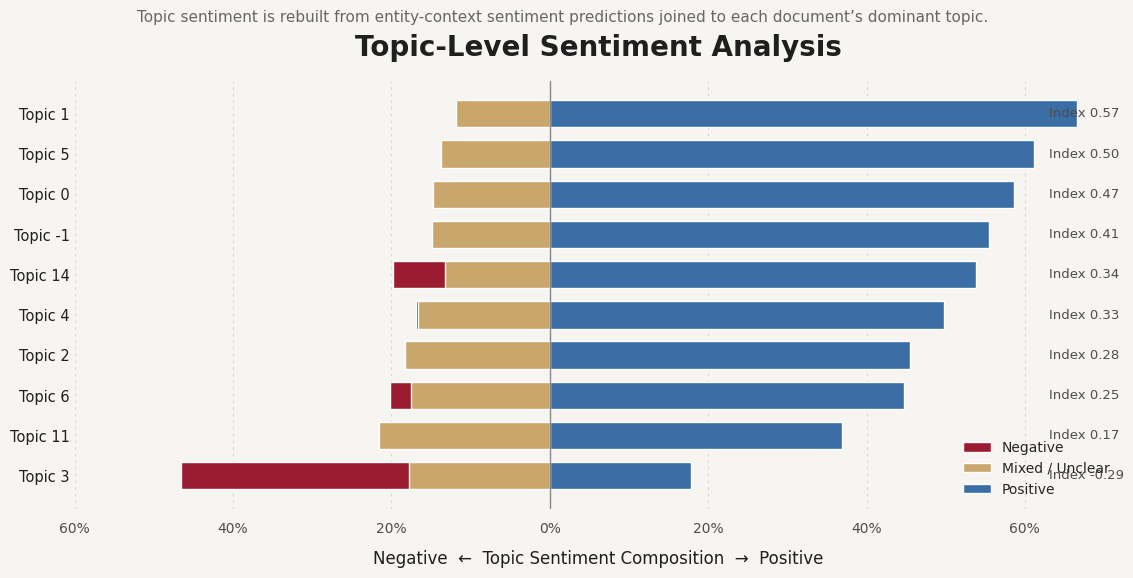

In [78]:
# ---------------------------------------------------------
# Slide 21 — Topic-level sentiment diverging bar (rebuilt)
# ---------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np

# join topic summary for better labels if available
topic_summary_candidates = sorted(set((BASE_DIR / "output" / "03_topic_modeling").rglob("*topic*summary*.parquet")))
df_topic_summary_full = None
for p in topic_summary_candidates:
    try:
        df_topic_summary_full = pd.read_parquet(p)
        if "topic_id" in df_topic_summary_full.columns:
            break
    except:
        pass

topic_tbl = topic_sent_rebuilt.copy()

if df_topic_summary_full is not None:
    extra_cols = [c for c in ["topic_name", "human_label", "n_blocks", "include_in_analysis"] if c in df_topic_summary_full.columns]
    if extra_cols:
        topic_tbl = topic_tbl.merge(
            df_topic_summary_full[["topic_id"] + extra_cols].drop_duplicates("topic_id"),
            on="topic_id",
            how="left",
            suffixes=("", "_summary")
        )

if "include_in_analysis" in topic_tbl.columns:
    topic_tbl = topic_tbl.loc[topic_tbl["include_in_analysis"].fillna(True)].copy()

if "human_label" in topic_tbl.columns and topic_tbl["human_label"].notna().any():
    topic_tbl["topic_display"] = topic_tbl["human_label"].fillna(topic_tbl.get("topic_name"))
elif "topic_name" in topic_tbl.columns:
    topic_tbl["topic_display"] = topic_tbl["topic_name"]
else:
    topic_tbl["topic_display"] = "Topic " + topic_tbl["topic_id"].astype(str)

topic_tbl["topic_short"] = topic_tbl["topic_display"].astype(str).map(
    lambda x: x if len(x) <= 34 else x[:31] + "..."
)

rank_col = "n_rows"
if "n_blocks" in topic_tbl.columns:
    rank_col = "n_blocks"

topic_tbl = topic_tbl.sort_values(rank_col, ascending=False).head(10).copy()
topic_tbl = topic_tbl.sort_values("sentiment_index", ascending=True).reset_index(drop=True)

bg = "#F7F5F2"
text_dark = "#1F1F1F"
grid = "#D8D2C8"

palette = {
    "positive": "#3A6EA5",
    "mixed_or_unclear": "#C9A66B",
    "negative": "#9B1C31"
}

neg = topic_tbl["prob_negative_mean"].to_numpy()
mix = topic_tbl["prob_mixed_or_unclear_mean"].to_numpy()
pos = topic_tbl["prob_positive_mean"].to_numpy()
labels = topic_tbl["topic_short"].tolist()
y = np.arange(len(topic_tbl))

fig, ax = plt.subplots(figsize=(11.6, 6.2), facecolor=bg)
ax.set_facecolor(bg)

# negative left
ax.barh(y, -neg, color=palette["negative"], edgecolor="white", height=0.68, label="Negative")
# mixed centered
ax.barh(y, mix, left=-mix/2, color=palette["mixed_or_unclear"], edgecolor="white", height=0.68, label="Mixed / Unclear")
# positive right
ax.barh(y, pos, color=palette["positive"], edgecolor="white", height=0.68, label="Positive")

ax.axvline(0, color="#888888", linewidth=1.0)

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=10.5, color=text_dark)
ax.set_title("Topic-Level Sentiment Analysis", fontsize=20, fontweight="bold", color=text_dark, pad=18)
ax.set_xlabel("Negative  ←  Topic Sentiment Composition  →  Positive", fontsize=12, color=text_dark, labelpad=10)

xticks = np.array([-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6])
ax.set_xticks(xticks)
ax.set_xticklabels([f"{abs(x):.0%}" if x != 0 else "0%" for x in xticks], fontsize=10, color="#4D4D4D")

for yi, s in zip(y, topic_tbl["sentiment_index"]):
    ax.text(0.63, yi, f"Index {s:.2f}", va="center", ha="left", fontsize=9.5, color="#4D4D4D")

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

ax.xaxis.grid(True, linestyle=(0, (2, 4)), linewidth=0.8, color=grid)
ax.yaxis.grid(False)
ax.set_axisbelow(True)
ax.tick_params(axis="y", length=0)

ax.legend(loc="lower right", frameon=False, fontsize=10)

fig.text(
    0.125, 0.91,
    "Topic sentiment is rebuilt from entity-context sentiment predictions joined to each document’s dominant topic.",
    fontsize=11,
    color="#666666"
)

plt.tight_layout(rect=[0, 0, 1, 0.92])

save_path = FIG_DIR / "slide_21_topic_level_sentiment_analysis_rebuilt.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor=bg)
print("Saved:", save_path)

plt.show()

In [79]:
# ---------------------------------------------------------
# Slide 21 — Super-topic mapping
# ---------------------------------------------------------

SUPER_TOPIC_MAP = {
    0:  "AI Infrastructure & Compute",
    1:  "Healthcare & Life Sciences",
    2:  "Chatbots, Assistants & Consumer AI",
    3:  "Synthetic Media, Misinformation & Platforms",
    4:  "Consumer AI Features & Search",
    5:  "AI Infrastructure & Compute",
    6:  "Work, Skills & Automation",
    7:  "Chatbots, Assistants & Consumer AI",
    8:  "Synthetic Media, Creator Tools & Content",
    9:  "Chatbots, Assistants & Consumer AI",
    10: "Agents, Frontier Models & AGI",
    11: "Agents, Frontier Models & AGI",
    12: "Education & Knowledge Work",
    13: "Agents, Frontier Models & AGI",
    14: "Governance, Safety & Security",
    15: "Governance, Regulation & Policy",
    16: "Enterprise Platforms & Adoption",
    17: "Synthetic Media, Creator Tools & Content",
    18: "Chatbots, Assistants & Consumer AI",
    19: "Chatbots, Assistants & Consumer AI",
    20: "Enterprise Platforms & Adoption",
    21: "Synthetic Media, Creator Tools & Content",
    22: "Automation, Robotics & Autonomous Systems",
    23: "Enterprise Platforms & Adoption",
    24: "Agents, Frontier Models & AGI",
    25: "Finance, Analytics & Decision Support",
    26: "Governance, Regulation & Policy",
    27: "Other Topics",
    28: "Governance, Safety & Security",
    29: "Consumer AI Features & Search",
    30: "Enterprise Platforms & Adoption",
    31: "Defense, Cyber & Security Applications",
    32: "Governance, Regulation & Policy",
    33: "Chatbots, Assistants & Consumer AI",
    34: "AI Infrastructure & Compute",
    35: "Enterprise Platforms & Adoption",
    36: "Automation, Robotics & Autonomous Systems",
    37: "Governance, Regulation & Policy",
    38: "Synthetic Media, Creator Tools & Content",
    39: "Enterprise Platforms & Adoption",
    40: "Enterprise Readiness & Implementation",
    41: "Consumer AI Features & Search",
    42: "Chatbots, Assistants & Consumer AI",
    43: "Consumer AI Features & Search",
    44: "AI Infrastructure & Compute",
    45: "Enterprise Platforms & Adoption",
    46: "Agents, Frontier Models & AGI",
    47: "Enterprise Platforms & Adoption",
    48: "Chatbots, Assistants & Consumer AI",
    49: "Computer Vision, Interfaces & Integration",
    50: "Other Topics",
    51: "Governance, Regulation & Policy",
    52: "Chatbots, Assistants & Consumer AI",
    53: "Gaming & Interactive AI",
    54: "Automation, Robotics & Autonomous Systems",
    55: "AI Market & Industry Solutions",
    56: "Other Topics",
    57: "Agents, Frontier Models & AGI",
    58: "AI Infrastructure & Compute",
    59: "Governance, Regulation & Policy",
    60: "AI Market & Industry Solutions",
    61: "Synthetic Media, Creator Tools & Content",
    62: "Agents, Frontier Models & AGI",
    63: "Governance, Safety & Security",
    64: "Chatbots, Assistants & Consumer AI",
    65: "Chatbots, Assistants & Consumer AI",
    66: "Governance, Safety & Security",
    67: "AI Market & Industry Solutions",
    68: "Synthetic Media, Creator Tools & Content",
    69: "Finance, Analytics & Decision Support",
    70: "AI Coding & Developer Tools",
}

In [80]:
# ---------------------------------------------------------
# Slide 21 — Aggregate topic sentiment to super topics
# ---------------------------------------------------------

topic_sent_super = topic_sent_rebuilt.copy()

topic_sent_super["super_topic"] = topic_sent_super["topic_id"].map(SUPER_TOPIC_MAP).fillna("Other Topics")

# weighted aggregation by topic size
topic_sent_super = (
    topic_sent_super
    .assign(
        w_pos=lambda x: x["prob_positive_mean"] * x["n_rows"],
        w_mix=lambda x: x["prob_mixed_or_unclear_mean"] * x["n_rows"],
        w_neg=lambda x: x["prob_negative_mean"] * x["n_rows"],
    )
    .groupby("super_topic", as_index=False)
    .agg(
        n_rows=("n_rows", "sum"),
        n_docs=("n_docs", "sum"),
        w_pos=("w_pos", "sum"),
        w_mix=("w_mix", "sum"),
        w_neg=("w_neg", "sum"),
    )
)

topic_sent_super["prob_positive_mean"] = topic_sent_super["w_pos"] / topic_sent_super["n_rows"]
topic_sent_super["prob_mixed_or_unclear_mean"] = topic_sent_super["w_mix"] / topic_sent_super["n_rows"]
topic_sent_super["prob_negative_mean"] = topic_sent_super["w_neg"] / topic_sent_super["n_rows"]
topic_sent_super["sentiment_index"] = (
    topic_sent_super["prob_positive_mean"] - topic_sent_super["prob_negative_mean"]
)

topic_sent_super = topic_sent_super.drop(columns=["w_pos", "w_mix", "w_neg"])

# remove very small / residual buckets if needed
topic_sent_super = topic_sent_super.loc[
    topic_sent_super["super_topic"] != "Other Topics"
].copy()

topic_sent_super = topic_sent_super.sort_values("n_rows", ascending=False).reset_index(drop=True)

display(topic_sent_super)

,super_topic,n_rows,n_docs,prob_positive_mean,prob_mixed_or_unclear_mean,prob_negative_mean,sentiment_index
0,"Chatbots, Assistants & Consumer AI",131056,24040,0.485064,0.337388,0.177549,0.307515
1,AI Infrastructure & Compute,100226,18551,0.563327,0.315762,0.120912,0.442415
2,"Agents, Frontier Models & AGI",88720,14242,0.514138,0.335900,0.149962,0.364175
3,Enterprise Platforms & Adoption,80605,11526,0.633704,0.243071,0.123225,0.510478
4,Healthcare & Life Sciences,55782,9933,0.666047,0.237471,0.096482,0.569565
5,"Synthetic Media, Creator Tools & Content",47154,8400,0.428402,0.362991,0.208607,0.219795
6,"Governance, Regulation & Policy",46639,8843,0.351417,0.442541,0.206043,0.145374
7,"Governance, Safety & Security",42477,6626,0.446510,0.314975,0.238515,0.207996
8,Consumer AI Features & Search,35796,7709,0.552157,0.307384,0.140460,0.411697
9,"Automation, Robotics & Autonomous Systems",34047,4739,0.578153,0.315956,0.105892,0.472261


Saved: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/figures/slide_21_super_topic_sentiment_analysis.png


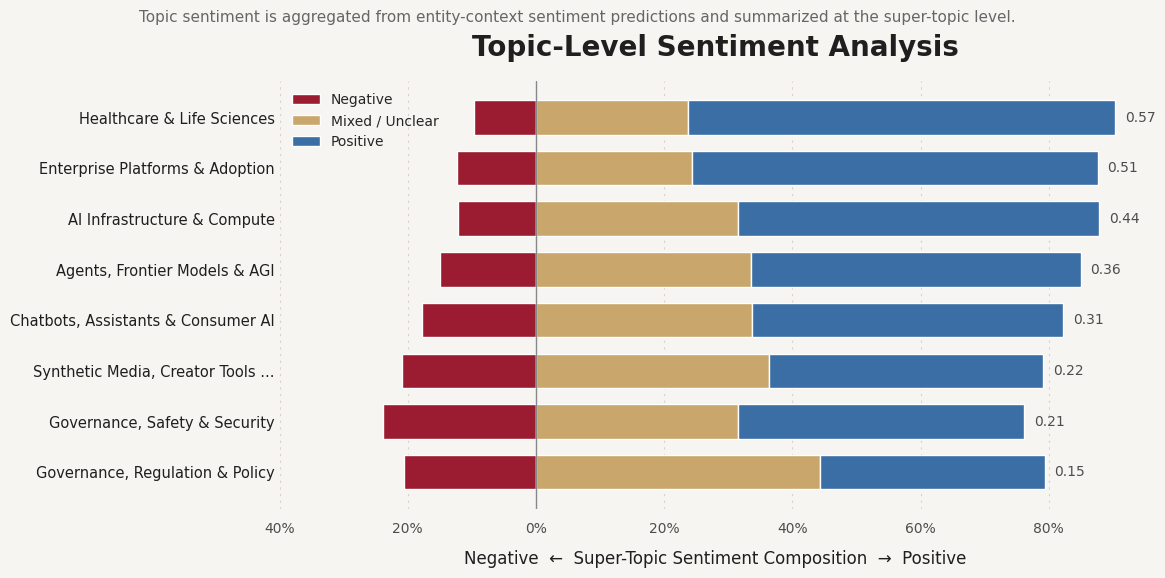

In [81]:
# ---------------------------------------------------------
# Slide 21 — Super-topic sentiment diverging bar
# ---------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np

plot_tbl = topic_sent_super.copy()

# 只保留主要 super topics，避免太挤
plot_tbl = plot_tbl.sort_values("n_rows", ascending=False).head(8).copy()

# 为了视觉对比，可以按 sentiment_index 排序
plot_tbl = plot_tbl.sort_values("sentiment_index", ascending=True).reset_index(drop=True)

bg = "#F7F5F2"
text_dark = "#1F1F1F"
grid = "#D8D2C8"

palette = {
    "positive": "#3A6EA5",
    "mixed_or_unclear": "#C9A66B",
    "negative": "#9B1C31"
}

plot_tbl["super_topic_short"] = plot_tbl["super_topic"].map(
    lambda x: x if len(x) <= 34 else x[:31] + "..."
)

neg = plot_tbl["prob_negative_mean"].to_numpy()
mix = plot_tbl["prob_mixed_or_unclear_mean"].to_numpy()
pos = plot_tbl["prob_positive_mean"].to_numpy()

labels = plot_tbl["super_topic_short"].tolist()
y = np.arange(len(plot_tbl))

fig, ax = plt.subplots(figsize=(11.8, 6.2), facecolor=bg)
ax.set_facecolor(bg)

# negative left
ax.barh(
    y,
    -neg,
    color=palette["negative"],
    edgecolor="white",
    height=0.68,
    label="Negative"
)

# mixed starts at 0
ax.barh(
    y,
    mix,
    left=0,
    color=palette["mixed_or_unclear"],
    edgecolor="white",
    height=0.68,
    label="Mixed / Unclear"
)

# positive extends to the right of mixed
ax.barh(
    y,
    pos,
    left=mix,
    color=palette["positive"],
    edgecolor="white",
    height=0.68,
    label="Positive"
)

ax.axvline(0, color="#888888", linewidth=1.0)

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=10.5, color=text_dark)
ax.set_title("Topic-Level Sentiment Analysis", fontsize=20, fontweight="bold", color=text_dark, pad=18)
ax.set_xlabel("Negative  ←  Super-Topic Sentiment Composition  →  Positive", fontsize=12, color=text_dark, labelpad=10)

xticks = np.array([-0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8])
ax.set_xticks(xticks)
ax.set_xticklabels([f"{abs(x):.0%}" if x != 0 else "0%" for x in xticks], fontsize=10, color="#4D4D4D")

# sentiment index label at bar end
for yi, mix_i, pos_i, s in zip(y, mix, pos, plot_tbl["sentiment_index"]):
    ax.text(
        mix_i + pos_i + 0.015,
        yi,
        f"{s:.2f}",
        va="center",
        ha="left",
        fontsize=10,
        color="#4D4D4D"
    )

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

ax.xaxis.grid(True, linestyle=(0, (2, 4)), linewidth=0.8, color=grid)
ax.yaxis.grid(False)
ax.set_axisbelow(True)
ax.tick_params(axis="y", length=0)

ax.legend(loc="upper left", frameon=False, fontsize=10)

fig.text(
    0.125, 0.91,
    "Topic sentiment is aggregated from entity-context sentiment predictions and summarized at the super-topic level.",
    fontsize=11,
    color="#666666"
)

plt.tight_layout(rect=[0, 0, 1, 0.92])

save_path = FIG_DIR / "slide_21_super_topic_sentiment_analysis.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor=bg)
print("Saved:", save_path)

plt.show()

In [82]:
# ---------------------------------------------------------
# Slide 22 — Load entity type sentiment summary
# ---------------------------------------------------------

etype_path = BASE_DIR / "output/05_sentiment_inference/entity_type_sentiment_summary.parquet"
df_etype = pd.read_parquet(etype_path)

print("shape:", df_etype.shape)
print("columns:", df_etype.columns.tolist())

display(df_etype)

shape: (4, 17)
columns: ['final_type', 'n_rows', 'n_docs', 'n_domains', 'mention_confidence_mean', 'pred_confidence_mean', 'prob_negative_mean', 'prob_mixed_or_unclear_mean', 'prob_positive_mean', 'mixed_or_unclear', 'negative', 'positive', 'hard_label_mode', 'sentiment_index', 'directional_confidence', 'impact_score', 'abs_sentiment_index']


,final_type,n_rows,n_docs,n_domains,mention_confidence_mean,pred_confidence_mean,prob_negative_mean,prob_mixed_or_unclear_mean,prob_positive_mean,mixed_or_unclear,negative,positive,hard_label_mode,sentiment_index,directional_confidence,impact_score,abs_sentiment_index
0,person,208911,98601,4640,0.868538,0.845963,0.186766,0.384602,0.428632,84015,29928,94968,positive,0.241866,0.615398,1.711533,0.241866
1,company,131873,57163,3102,0.801551,0.871440,0.100937,0.215452,0.683612,27313,6252,98308,positive,0.582675,0.784548,5.007331,0.582675
2,technology,146631,55619,3422,0.713391,0.859716,0.130310,0.239508,0.630182,33321,11711,101599,positive,0.499872,0.760492,4.153617,0.499872
3,government_institution,73583,40753,3652,0.741925,0.838197,0.190242,0.369079,0.440680,27448,10559,35576,positive,0.250438,0.630921,1.677289,0.250438


In [83]:
# ---------------------------------------------------------
# Slide 22 — Prepare display table
# ---------------------------------------------------------

required_cols = ["final_type", "sentiment_index", "directional_confidence", "impact_score"]
for c in required_cols:
    assert c in df_etype.columns, f"Missing required column: {c}"

plot_tbl = df_etype[required_cols].copy()

label_map = {
    "company": "Company",
    "technology": "Technology",
    "government_institution": "Government",
    "person": "Person"
}

plot_tbl["entity_type"] = plot_tbl["final_type"].map(label_map).fillna(plot_tbl["final_type"])

# keep presentation order
type_order = ["Company", "Technology", "Government", "Person"]
plot_tbl["entity_type"] = pd.Categorical(plot_tbl["entity_type"], categories=type_order, ordered=True)
plot_tbl = plot_tbl.sort_values("entity_type").reset_index(drop=True)

display(plot_tbl)

,final_type,sentiment_index,directional_confidence,impact_score,entity_type
0,company,0.582675,0.784548,5.007331,Company
1,technology,0.499872,0.760492,4.153617,Technology
2,government_institution,0.250438,0.630921,1.677289,Government
3,person,0.241866,0.615398,1.711533,Person


Saved: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/figures/slide_22_entity_type_comparison.png


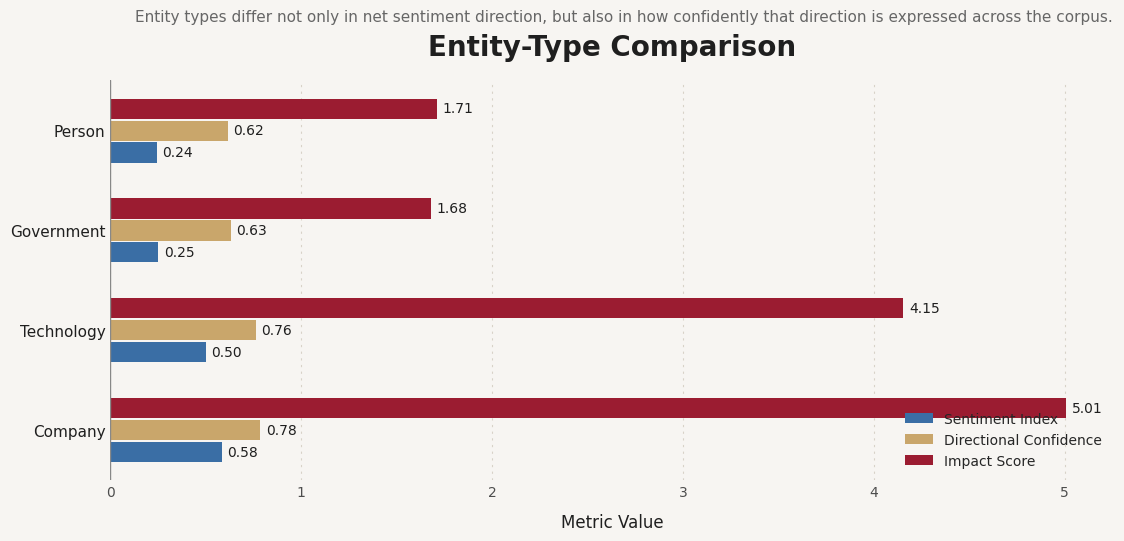

In [84]:
# ---------------------------------------------------------
# Slide 22 — Presentation-grade entity type comparison
# ---------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np

bg = "#F7F5F2"
text_dark = "#1F1F1F"
grid = "#D8D2C8"

metric_colors = {
    "sentiment_index": "#3A6EA5",          # blue
    "directional_confidence": "#C9A66B",   # gold
    "impact_score": "#9B1C31"              # maroon
}

pretty_metric = {
    "sentiment_index": "Sentiment Index",
    "directional_confidence": "Directional Confidence",
    "impact_score": "Impact Score"
}

metrics = ["sentiment_index", "directional_confidence", "impact_score"]
y_base = np.arange(len(plot_tbl))
bar_h = 0.22
offsets = [-bar_h, 0, bar_h]

fig, ax = plt.subplots(figsize=(11.4, 5.8), facecolor=bg)
ax.set_facecolor(bg)

for metric, off in zip(metrics, offsets):
    vals = plot_tbl[metric].to_numpy()
    ax.barh(
        y_base + off,
        vals,
        height=bar_h * 0.92,
        color=metric_colors[metric],
        edgecolor="none",
        label=pretty_metric[metric]
    )

    for yi, v in zip(y_base + off, vals):
        ax.text(
            v + (0.03 if v >= 0 else -0.03),
            yi,
            f"{v:.2f}",
            va="center",
            ha="left" if v >= 0 else "right",
            fontsize=10,
            color=text_dark
        )

ax.set_yticks(y_base)
ax.set_yticklabels(plot_tbl["entity_type"], fontsize=11, color=text_dark)
ax.set_title("Entity-Type Comparison", fontsize=20, fontweight="bold", color=text_dark, pad=18)
ax.set_xlabel("Metric Value", fontsize=12, color=text_dark, labelpad=10)

# zero line for metrics that can go negative
ax.axvline(0, color="#888888", linewidth=1.0)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

ax.xaxis.grid(True, linestyle=(0, (2, 4)), linewidth=0.8, color=grid)
ax.yaxis.grid(False)
ax.set_axisbelow(True)
ax.tick_params(axis="x", labelsize=10, colors="#4D4D4D", length=0)
ax.tick_params(axis="y", length=0)

ax.legend(loc="lower right", frameon=False, fontsize=10)

fig.text(
    0.125, 0.91,
    "Entity types differ not only in net sentiment direction, but also in how confidently that direction is expressed across the corpus.",
    fontsize=11,
    color="#666666"
)

plt.tight_layout(rect=[0, 0, 1, 0.92])

save_path = FIG_DIR / "slide_22_entity_type_comparison.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor=bg)
print("Saved:", save_path)

plt.show()

In [85]:
# ---------------------------------------------------------
# Slide 23 — Load entity time sentiment summary
# ---------------------------------------------------------

time_path = BASE_DIR / "output/05_sentiment_inference/entity_time_sentiment_summary.parquet"
df_time = pd.read_parquet(time_path)

print("shape:", df_time.shape)
print("columns:", df_time.columns.tolist())

display(df_time.head(5))

shape: (377732, 19)
columns: ['canonical_entity', 'final_type', 'year_month', 'n_rows', 'n_docs', 'n_domains', 'mention_confidence_mean', 'pred_confidence_mean', 'prob_negative_mean', 'prob_mixed_or_unclear_mean', 'prob_positive_mean', 'mixed_or_unclear', 'negative', 'positive', 'hard_label_mode', 'sentiment_index', 'directional_confidence', 'impact_score', 'abs_sentiment_index']


,canonical_entity,final_type,year_month,n_rows,n_docs,n_domains,mention_confidence_mean,pred_confidence_mean,prob_negative_mean,prob_mixed_or_unclear_mean,prob_positive_mean,mixed_or_unclear,negative,positive,hard_label_mode,sentiment_index,directional_confidence,impact_score,abs_sentiment_index
0,01.ai,company,2024-05,1,1,1,0.889000,0.848588,0.069656,0.081755,0.848588,0,0,1,positive,0.778932,0.918245,0.495774,0.778932
1,01.ai,company,2025-01,2,2,2,0.765487,0.482876,0.050923,0.472700,0.476377,1,0,1,mixed_or_unclear,0.425454,0.527300,0.246465,0.425454
2,01AI_Yi,company,2023-11,1,1,1,0.807887,0.914405,0.056657,0.028938,0.914405,0,0,1,positive,0.857747,0.971062,0.577340,0.857747
3,0G Foundation,company,2025-06,1,1,1,0.610548,0.892482,0.048422,0.059096,0.892482,0,0,1,positive,0.844061,0.940904,0.550484,0.844061
4,0G Labs,company,2024-03,1,1,1,0.867815,0.926496,0.055858,0.017645,0.926496,0,0,1,positive,0.870638,0.982355,0.592832,0.870638


In [86]:
# ---------------------------------------------------------
# Prepare time-series table
# ---------------------------------------------------------

required_cols = ["year_month", "final_type", "sentiment_index"]
for c in required_cols:
    assert c in df_time.columns, f"Missing required column: {c}"

plot_tbl = df_time.copy()

# keep the two most relevant entity types
plot_tbl = plot_tbl.loc[
    plot_tbl["final_type"].isin(["company", "technology"])
].copy()

# normalize month
plot_tbl["year_month"] = pd.to_datetime(plot_tbl["year_month"])

label_map = {
    "company": "Company",
    "technology": "Technology"
}
plot_tbl["entity_type"] = plot_tbl["final_type"].map(label_map)

display(plot_tbl.head(5))

,canonical_entity,final_type,year_month,n_rows,n_docs,n_domains,mention_confidence_mean,pred_confidence_mean,prob_negative_mean,prob_mixed_or_unclear_mean,prob_positive_mean,mixed_or_unclear,negative,positive,hard_label_mode,sentiment_index,directional_confidence,impact_score,abs_sentiment_index,entity_type
0,01.ai,company,2024-05-01,1,1,1,0.889000,0.848588,0.069656,0.081755,0.848588,0,0,1,positive,0.778932,0.918245,0.495774,0.778932,Company
1,01.ai,company,2025-01-01,2,2,2,0.765487,0.482876,0.050923,0.472700,0.476377,1,0,1,mixed_or_unclear,0.425454,0.527300,0.246465,0.425454,Company
2,01AI_Yi,company,2023-11-01,1,1,1,0.807887,0.914405,0.056657,0.028938,0.914405,0,0,1,positive,0.857747,0.971062,0.577340,0.857747,Company
3,0G Foundation,company,2025-06-01,1,1,1,0.610548,0.892482,0.048422,0.059096,0.892482,0,0,1,positive,0.844061,0.940904,0.550484,0.844061,Company
4,0G Labs,company,2024-03-01,1,1,1,0.867815,0.926496,0.055858,0.017645,0.926496,0,0,1,positive,0.870638,0.982355,0.592832,0.870638,Company


In [87]:
# ---------------------------------------------------------
# Aggregate by month and entity type
# ---------------------------------------------------------

time_agg = (
    plot_tbl
    .groupby(["year_month", "entity_type"], as_index=False)
    .agg(
        sentiment_index=("sentiment_index", "mean")
    )
)

# pivot for plotting
pivot = (
    time_agg
    .pivot(index="year_month", columns="entity_type", values="sentiment_index")
    .sort_index()
)

display(pivot.head())

entity_type,Company,Technology
year_month,,
2022-01-01,0.544868,0.539163
2022-02-01,0.610770,0.526304
2022-03-01,0.602205,0.573767
2022-04-01,0.587665,0.535096
2022-05-01,0.577200,0.429942


In [88]:
# ---------------------------------------------------------
# Smooth series
# ---------------------------------------------------------

pivot_smooth = pivot.rolling(window=3, min_periods=1).mean()

display(pivot_smooth.head())

entity_type,Company,Technology
year_month,,
2022-01-01,0.544868,0.539163
2022-02-01,0.577819,0.532733
2022-03-01,0.585948,0.546411
2022-04-01,0.600214,0.545056
2022-05-01,0.589024,0.512935


Saved: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/figures/slide_23_time_series_ai_impact.png


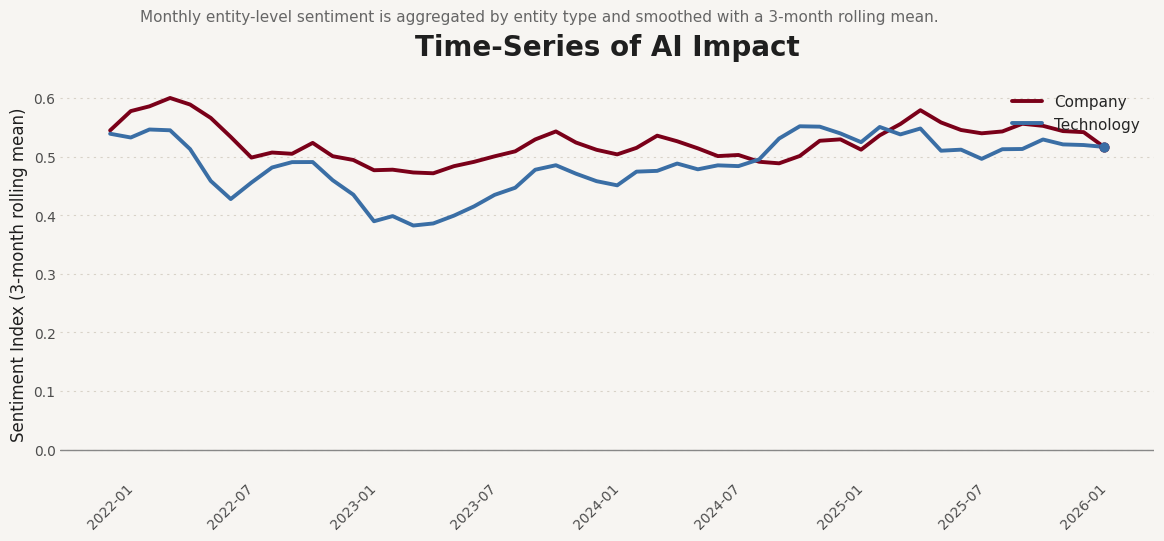

In [89]:
# ---------------------------------------------------------
# Slide 23 — Presentation-grade time-series plot
# ---------------------------------------------------------

import matplotlib.pyplot as plt

bg = "#F7F5F2"
text_dark = "#1F1F1F"
grid = "#D8D2C8"

line_colors = {
    "Company": "#7A0019",     # maroon
    "Technology": "#3A6EA5"   # blue
}

fig, ax = plt.subplots(figsize=(11.8, 5.8), facecolor=bg)
ax.set_facecolor(bg)

for col in ["Company", "Technology"]:
    if col in pivot_smooth.columns:
        ax.plot(
            pivot_smooth.index,
            pivot_smooth[col],
            linewidth=2.8,
            color=line_colors[col],
            label=col
        )

        # mark last point
        if pivot_smooth[col].notna().any():
            last_idx = pivot_smooth[col].dropna().index[-1]
            last_val = pivot_smooth.loc[last_idx, col]
            ax.scatter(last_idx, last_val, s=40, color=line_colors[col], zorder=3)

ax.axhline(0, color="#888888", linewidth=1.0, linestyle="-")

ax.set_title("Time-Series of AI Impact", fontsize=20, fontweight="bold", color=text_dark, pad=18)
ax.set_ylabel("Sentiment Index (3-month rolling mean)", fontsize=12, color=text_dark)
ax.set_xlabel("", fontsize=12, color=text_dark)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

ax.yaxis.grid(True, linestyle=(0, (2, 4)), linewidth=0.8, color=grid)
ax.xaxis.grid(False)
ax.set_axisbelow(True)
ax.tick_params(axis="x", labelsize=10, colors="#4D4D4D", rotation=45)
ax.tick_params(axis="y", labelsize=10, colors="#4D4D4D", length=0)

ax.legend(loc="upper right", frameon=False, fontsize=11)

fig.text(
    0.125, 0.91,
    "Monthly entity-level sentiment is aggregated by entity type and smoothed with a 3-month rolling mean.",
    fontsize=11,
    color="#666666"
)

plt.tight_layout(rect=[0, 0, 1, 0.92])

save_path = FIG_DIR / "slide_23_time_series_ai_impact.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor=bg)
print("Saved:", save_path)

plt.show()

# Slide 25 — Industry Mapping and Evidence Assets (Refactored)

This refactored section keeps the same input/output contract while removing repeated setup, redundant rebuilds, and fragile reruns.

Design principles:
- reuse existing globals and cached artifacts whenever possible
- rebuild only when a required artifact is missing or explicitly invalid
- keep DeepSeek labels resumable and reusable through JSONL + parquet caches
- preserve the existing slide-25 output paths and downstream variable names


In [91]:

# =========================================================
# Slide 25 — Shared setup and reusable paths
# =========================================================

import os
import re
import gc
import json
import math
import time
import asyncio
import hashlib
from pathlib import Path
from typing import Dict, List, Optional, Any

import aiohttp
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import nest_asyncio
nest_asyncio.apply()

# Reuse earlier notebook globals when present; otherwise create safe fallbacks.
if 'BASE_DIR' not in globals():
    BASE_DIR = Path('/content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen')
if 'OUT_DIR' not in globals() and 'OUTPUT_DIR' not in globals():
    OUT_DIR = BASE_DIR / 'output'
if 'OUTPUT_DIR' not in globals():
    OUTPUT_DIR = OUT_DIR if 'OUT_DIR' in globals() else BASE_DIR / 'output'
if 'PRESENTATION_DIR' not in globals():
    PRESENTATION_DIR = BASE_DIR / 'presentation_assets'
if 'FIG_DIR' not in globals():
    FIG_DIR = PRESENTATION_DIR / 'figures'
if 'TAB_DIR' not in globals():
    TAB_DIR = PRESENTATION_DIR / 'tables'

SLIDE25_DIR = OUTPUT_DIR / '06_industry_mapping'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)
SLIDE25_DIR.mkdir(parents=True, exist_ok=True)

try:
    from google.colab import userdata
except Exception:
    userdata = None

DEEPSEEK_BASE_URL = 'https://api.deepseek.com'
DEEPSEEK_ENDPOINT = f'{DEEPSEEK_BASE_URL}/chat/completions'
DEEPSEEK_MODEL = 'deepseek-chat'

if userdata is not None:
    DEEPSEEK_API_KEY = userdata.get('DEEPSEEK_API_KEY')
else:
    DEEPSEEK_API_KEY = os.environ.get('DEEPSEEK_API_KEY')

WORKERS = 64
QUEUE_SIZE = 256
HTTP_LIMIT = 128
HTTP_PER_HOST = 64
HTTP_TIMEOUT = 90
MAX_RETRIES = 6
JSONL_FLUSH_EVERY = 100

TARGET_N = 15000
MAX_CONTEXT_SNIPPETS = 3
MAX_CONTEXT_CHARS = 320
MAX_TOTAL_CONTEXT_CHARS = 1200

LABELS = [
    'Office / Enterprise Software',
    'Legal / Compliance',
    'Healthcare Support / Diagnostics',
    'Media / Design / Content',
    'Finance / Analytics',
    'Education / Knowledge Work',
    'Manufacturing / Industrial Robotics',
    'Government / Public Sector',
    'Other / Unclear',
]

LABELING_JSONL = SLIDE25_DIR / 'slide25_industry_labels.jsonl'
LABELING_PARQUET = SLIDE25_DIR / 'slide25_industry_labels.parquet'
DOC_BUNDLES_PARQUET = SLIDE25_DIR / 'slide25_doc_bundles.parquet'
DOC_SAMPLE_PARQUET = SLIDE25_DIR / 'slide25_doc_sample.parquet'

RANKING_PNG = FIG_DIR / 'slide_25_industry_ranking.png'
EVIDENCE_TABLE_CSV = TAB_DIR / 'slide_25_industry_evidence_table.csv'

print('BASE_DIR:', BASE_DIR)
print('SLIDE25_DIR:', SLIDE25_DIR)
print('Target labels:', LABELS)


BASE_DIR: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen
SLIDE25_DIR: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/output/06_industry_mapping
Target labels: ['Office / Enterprise Software', 'Legal / Compliance', 'Healthcare Support / Diagnostics', 'Media / Design / Content', 'Finance / Analytics', 'Education / Knowledge Work', 'Manufacturing / Industrial Robotics', 'Government / Public Sector', 'Other / Unclear']


In [95]:
  # =========================================================
  # Slide 25 — Reusable helpers
  # =========================================================

  def path_exists_and_nonempty(path: Path) -> bool:
      return path.exists() and path.stat().st_size > 0


  def safe_read_parquet(path: Path) -> pd.DataFrame:
      if path_exists_and_nonempty(path):
          return pd.read_parquet(path)
      return pd.DataFrame()


  def safe_read_csv(path: Path) -> pd.DataFrame:
      if path_exists_and_nonempty(path):
          return pd.read_csv(path)
      return pd.DataFrame()


  def truncate_text(text: str, max_chars: int) -> str:
      if pd.isna(text):
          return ''
      text = re.sub(r'\s+', ' ', str(text)).strip()
      return text[:max_chars].strip()


  def load_entity_context_predictions() -> pd.DataFrame:
      pred_path = OUTPUT_DIR / '05_sentiment_inference' / 'entity_context_sentiment_predictions.parquet'
      assert pred_path.exists(), f'Missing file: {pred_path}'
      df_pred_local = pd.read_parquet(pred_path)
      df_pred_local['doc_id'] = pd.to_numeric(df_pred_local['doc_id'], errors='coerce').astype('Int64')
      if 'year_month' in df_pred_local.columns:
          df_pred_local['year_month'] = pd.to_datetime(df_pred_local['year_month'], errors='coerce')
      if 'date' in df_pred_local.columns:
          df_pred_local['date'] = pd.to_datetime(df_pred_local['date'], errors='coerce')
      return df_pred_local


  def discover_topic_artifacts() -> tuple[pd.DataFrame, pd.DataFrame]:
      topic_dir = OUTPUT_DIR / '03_topic_modeling'
      topic_summary_candidates = sorted(set(topic_dir.rglob('*topic*summary*.parquet')))
      doc_topic_candidates = sorted(set(topic_dir.rglob('*doc*topic*.parquet'))) + sorted(set(topic_dir.rglob('*doc*topic*.csv')))

      df_topic_summary_local = None
      for p in topic_summary_candidates:
          try:
              tmp = pd.read_parquet(p)
              if 'topic_id' in tmp.columns:
                  df_topic_summary_local = tmp.copy()
                  print('Loaded topic summary:', p)
                  break
          except Exception as e:
              print('skip topic summary:', p, '|', e)

      df_doc_topics_local = None
      for p in doc_topic_candidates:
          try:
              tmp = pd.read_parquet(p) if p.suffix.lower() == '.parquet' else pd.read_csv(p)
              if {'doc_id', 'topic_id'}.issubset(tmp.columns):
                  df_doc_topics_local = tmp.copy()
                  print('Loaded doc-topic file:', p)
                  break
          except Exception as e:
              print('skip doc-topic:', p, '|', e)

      return df_topic_summary_local, df_doc_topics_local


  def build_dominant_doc_topic(df_doc_topics_local: Optional[pd.DataFrame], df_topic_summary_local: Optional[pd.DataFrame]) -> Optional[pd.DataFrame]:
      if df_doc_topics_local is None or len(df_doc_topics_local) == 0:
          return None
      rank_cols = [c for c in ['topic_block_share_within_doc', 'mean_topic_prob', 'n_blocks'] if c in df_doc_topics_local.columns]
      assert rank_cols, 'Found doc-topic file but no usable ranking columns.'

      dominant = (
          df_doc_topics_local
          .copy()
          .assign(doc_id=lambda x: pd.to_numeric(x['doc_id'], errors='coerce').astype('Int64'))
          .sort_values(rank_cols, ascending=[False] * len(rank_cols))
          .drop_duplicates(subset=['doc_id'], keep='first')
      )

      if df_topic_summary_local is not None and len(df_topic_summary_local) > 0:
          extra_cols = [c for c in ['topic_name', 'human_label', 'super_topic', 'include_in_analysis'] if c in df_topic_summary_local.columns]
          if extra_cols:
              dominant = dominant.merge(
                  df_topic_summary_local[['topic_id'] + extra_cols].drop_duplicates('topic_id'),
                  on='topic_id',
                  how='left'
              )
      return dominant


  def build_doc_bundles(df_pred_local: pd.DataFrame, dominant_doc_topic_local: Optional[pd.DataFrame]) -> pd.DataFrame:
      df_work = df_pred_local.copy()

      doc_companies = (
          df_work.loc[df_work['final_type'] == 'company']
          .groupby(['doc_id', 'canonical_entity'], as_index=False)
          .size()
          .rename(columns={'size': 'n'})
          .sort_values(['doc_id', 'n'], ascending=[True, False])
          .groupby('doc_id', as_index=False)
          .head(5)
          .groupby('doc_id')['canonical_entity']
          .apply(list)
          .reset_index(name='top_companies')
      )

      doc_tech = (
          df_work.loc[df_work['final_type'] == 'technology']
          .groupby(['doc_id', 'canonical_entity'], as_index=False)
          .size()
          .rename(columns={'size': 'n'})
          .sort_values(['doc_id', 'n'], ascending=[True, False])
          .groupby('doc_id', as_index=False)
          .head(5)
          .groupby('doc_id')['canonical_entity']
          .apply(list)
          .reset_index(name='top_technologies')
      )

      df_work['snippet'] = df_work['context_text'].map(lambda x: truncate_text(x, MAX_CONTEXT_CHARS))
      doc_snippets = (
          df_work.loc[df_work['snippet'].str.len() > 30]
          .groupby('doc_id', as_index=False)
          .head(MAX_CONTEXT_SNIPPETS)
          .groupby('doc_id')['snippet']
          .apply(list)
          .reset_index(name='snippets')
      )

      doc_sent = (
          df_work
          .groupby('doc_id', as_index=False)
          .agg(
              date=('date', 'first'),
              year_month=('year_month', 'first'),
              domain=('domain', 'first'),
              title=('title', 'first'),
              url=('url', 'first'),
              n_rows=('row_uid', 'size'),
              n_entities=('canonical_entity', 'nunique'),
              prob_negative_mean=('prob_negative', 'mean'),
              prob_mixed_or_unclear_mean=('prob_mixed_or_unclear', 'mean'),
              prob_positive_mean=('prob_positive', 'mean'),
          )
      )
      doc_sent['sentiment_index'] = doc_sent['prob_positive_mean'] - doc_sent['prob_negative_mean']
      doc_sent['uncertainty'] = doc_sent['prob_mixed_or_unclear_mean']

      bundles = doc_sent.merge(doc_companies, on='doc_id', how='left')
      bundles = bundles.merge(doc_tech, on='doc_id', how='left')
      bundles = bundles.merge(doc_snippets, on='doc_id', how='left')

      if dominant_doc_topic_local is not None and len(dominant_doc_topic_local) > 0:
          topic_cols = ['doc_id'] + [c for c in ['topic_id', 'topic_name', 'human_label', 'super_topic'] if c in dominant_doc_topic_local.columns]
          bundles = bundles.merge(dominant_doc_topic_local[topic_cols], on='doc_id', how='left')

      bundles['top_companies'] = bundles['top_companies'].apply(lambda x: x if isinstance(x, list) else [])
      bundles['top_technologies'] = bundles['top_technologies'].apply(lambda x: x if isinstance(x, list) else [])
      bundles['snippets'] = bundles['snippets'].apply(lambda x: x if isinstance(x, list) else [])
      bundles['super_topic_display'] = bundles['super_topic'] if 'super_topic' in bundles.columns else None
      if 'human_label' in bundles.columns:
          bundles['topic_display'] = bundles['human_label'].fillna(bundles.get('topic_name'))
      elif 'topic_name' in bundles.columns:
          bundles['topic_display'] = bundles['topic_name']
      else:
          bundles['topic_display'] = None
      bundles['bundle_id'] = bundles['doc_id'].astype(str)
      return bundles


  def build_doc_sample(doc_bundles_local: pd.DataFrame, target_n: int) -> pd.DataFrame:
      sample_base = doc_bundles_local.copy()
      sample_base = sample_base.loc[
          (sample_base['n_rows'] >= 2) &
          ((sample_base['top_companies'].map(len) + sample_base['top_technologies'].map(len) + sample_base['snippets'].map(len)) >= 2)
      ].copy()

      if 'super_topic_display' in sample_base.columns and sample_base['super_topic_display'].notna().any():
          sample_base['strata'] = sample_base['super_topic_display'].fillna('Unknown')
      elif 'topic_display' in sample_base.columns and sample_base['topic_display'].notna().any():
          sample_base['strata'] = sample_base['topic_display'].fillna('Unknown')
      else:
          sample_base['strata'] = sample_base['year_month'].astype(str)
      sample_base['strata'] = sample_base['strata'].fillna('Unknown')

      group_counts = sample_base['strata'].value_counts()
      n_total = min(target_n, len(sample_base))
      alloc = ((group_counts / group_counts.sum() * n_total).round().astype(int).clip(lower=20))

      while alloc.sum() > n_total:
          idx = alloc.idxmax()
          if alloc[idx] > 20:
              alloc[idx] -= 1
          else:
              break
      while alloc.sum() < n_total:
          idx = group_counts.idxmax()
          alloc[idx] += 1

      frames = []
      for strata, n_take in tqdm(alloc.items(), total=len(alloc), desc='Sampling strata'):
          sub = sample_base.loc[sample_base['strata'] == strata]
          n_take = min(n_take, len(sub))
          if n_take > 0:
              frames.append(sub.sample(n=n_take, random_state=SEED))

      doc_sample_local = pd.concat(frames, ignore_index=True).drop_duplicates('doc_id') if frames else sample_base.head(0).copy()
      if len(doc_sample_local) > n_total:
          doc_sample_local = doc_sample_local.sample(n=n_total, random_state=SEED).copy()
      return doc_sample_local.sort_values(['strata', 'doc_id']).reset_index(drop=True)


  def make_user_prompt(row: pd.Series) -> str:
      parts = []
      title = truncate_text(row.get('title', ''), 180)
      domain = row.get('domain', '')
      topic = row.get('topic_display', None)
      super_topic = row.get('super_topic_display', None)
      comps = row.get('top_companies', [])
      techs = row.get('top_technologies', [])
      snippets = row.get('snippets', [])

      parts.append(f'Title: {title}')
      parts.append(f'Domain: {domain}')
      if pd.notna(super_topic):
          parts.append(f'Super topic: {super_topic}')
      if pd.notna(topic):
          parts.append(f'Topic label: {topic}')
      parts.append(f"Top companies: {', '.join(comps[:5]) if comps else 'None'}")
      parts.append(f"Top technologies: {', '.join(techs[:5]) if techs else 'None'}")
      parts.append(
          f"Document-level sentiment summary: positive={row['prob_positive_mean']:.2f}, "
          f"mixed={row['prob_mixed_or_unclear_mean']:.2f}, negative={row['prob_negative_mean']:.2f}, "
          f"sentiment_index={row['sentiment_index']:.2f}"
      )
      parts.append('Representative context snippets:')
      for i, s in enumerate(snippets[:MAX_CONTEXT_SNIPPETS], start=1):
          parts.append(f'{i}. {truncate_text(s, MAX_CONTEXT_CHARS)}')
      parts.append('Task: Assign the most likely impacted industry category.')
      return '\n'.join(parts)


  SYSTEM_PROMPT = """You are labeling AI-related news evidence into industry impact categories.

  Your task is to infer which industry is most directly being affected by the AI-related development described in the evidence bundle.

  Allowed labels:
  1. Office / Enterprise Software
  2. Legal / Compliance
  3. Healthcare Support / Diagnostics
  4. Media / Design / Content
  5. Finance / Analytics
  6. Education / Knowledge Work
  7. Manufacturing / Industrial Robotics
  8. Government / Public Sector
  9. Other / Unclear

  Rules:
  - Focus on the downstream application industry most directly affected by the AI use case.
  - Use topic semantics, company evidence, technology evidence, and context together.
  - Prefer the industry of adoption/use over the general infrastructure supplier when possible.
  - If evidence is ambiguous, use Other / Unclear.
  - Return exactly one primary industry and optionally one secondary industry.
  - Do not invent facts beyond the evidence.

  Return JSON only in this schema:
  {
    "primary_industry": "...",
    "secondary_industry": "... or null",
    "confidence": 0.0,
    "is_mappable": true,
    "rationale": "one short sentence"
  }
  """


  def safe_float(x, default=None):
      try:
          return float(x)
      except Exception:
          return default


  def extract_json_object(text: str) -> Optional[dict]:
      if text is None:
          return None
      text = text.strip()
      try:
          return json.loads(text)
      except Exception:
          pass
      match = re.search(r'\{.*\}', text, flags=re.DOTALL)
      if match:
          try:
              return json.loads(match.group(0))
          except Exception:
              return None
      return None


  def normalize_label(x: Optional[str]) -> Optional[str]:
      if x is None:
          return None
      x = str(x).strip()
      if x in LABELS:
          return x
      x_low = x.lower()
      for label in LABELS:
          if x_low == label.lower():
              return label
      return 'Other / Unclear'


  def parse_label_response(raw_text: str) -> Dict[str, Any]:
      obj = extract_json_object(raw_text) or {}
      primary = normalize_label(obj.get('primary_industry'))
      secondary = obj.get('secondary_industry')
      secondary = normalize_label(secondary) if secondary not in [None, '', 'null'] else None
      confidence = safe_float(obj.get('confidence'), default=0.0)
      confidence = max(0.0, min(1.0, confidence))
      is_mappable = obj.get('is_mappable')
      if isinstance(is_mappable, str):
          is_mappable = is_mappable.strip().lower() == 'true'
      elif is_mappable is None:
          is_mappable = primary != 'Other / Unclear'
      rationale = str(obj.get('rationale', '')).strip()
      return {
          'primary_industry': primary,
          'secondary_industry': secondary,
          'confidence': confidence,
          'is_mappable': bool(is_mappable),
          'rationale': rationale,
          'raw_response': raw_text,
      }


  async def call_deepseek(session: aiohttp.ClientSession, prompt: str) -> str:
      payload = {
          'model': DEEPSEEK_MODEL,
          'messages': [
              {'role': 'system', 'content': SYSTEM_PROMPT},
              {'role': 'user', 'content': prompt},
          ],
          'temperature': 0.0,
      }
      headers = {
          'Authorization': f'Bearer {DEEPSEEK_API_KEY}',
          'Content-Type': 'application/json',
      }
      async with session.post(DEEPSEEK_ENDPOINT, headers=headers, json=payload) as resp:
          text = await resp.text()
          if resp.status != 200:
              raise RuntimeError(f'HTTP {resp.status}: {text[:500]}')
          data = json.loads(text)
          return data['choices'][0]['message']['content']


  def read_existing_label_jsonl(path: Path) -> pd.DataFrame:
      if not path_exists_and_nonempty(path):
          return pd.DataFrame()
      rows = []
      with open(path, 'r', encoding='utf-8') as f:
          for line in f:
              line = line.strip()
              if line:
                  try:
                      rows.append(json.loads(line))
                  except Exception:
                      pass
      return pd.DataFrame(rows)


In [96]:

# =========================================================
# Slide 25 — Build or reuse cached doc bundles and sample
# =========================================================

assert DEEPSEEK_API_KEY, 'Missing DEEPSEEK_API_KEY in Colab userdata or environment.'

df = load_entity_context_predictions()
print('entity-context predictions:', df.shape)

df_topic_summary, df_doc_topics = discover_topic_artifacts()
dominant_doc_topic = build_dominant_doc_topic(df_doc_topics, df_topic_summary)

# Reuse cached doc bundles whenever possible.
doc_bundles = safe_read_parquet(DOC_BUNDLES_PARQUET)
if doc_bundles.empty:
    doc_bundles = build_doc_bundles(df, dominant_doc_topic)
    doc_bundles.to_parquet(DOC_BUNDLES_PARQUET, index=False)
    print('Built and saved doc bundles:', DOC_BUNDLES_PARQUET)
else:
    print('Reused cached doc bundles:', DOC_BUNDLES_PARQUET)

# Reuse cached sample only when it matches the current target size.
doc_sample = safe_read_parquet(DOC_SAMPLE_PARQUET)
if doc_sample.empty or len(doc_sample) != min(TARGET_N, len(doc_bundles)):
    doc_sample = build_doc_sample(doc_bundles, TARGET_N)
    doc_sample['labeling_prompt'] = doc_sample.apply(make_user_prompt, axis=1)
    doc_sample.to_parquet(DOC_SAMPLE_PARQUET, index=False)
    print('Built and saved doc sample:', DOC_SAMPLE_PARQUET)
else:
    if 'labeling_prompt' not in doc_sample.columns:
        doc_sample['labeling_prompt'] = doc_sample.apply(make_user_prompt, axis=1)
        doc_sample.to_parquet(DOC_SAMPLE_PARQUET, index=False)
    print('Reused cached doc sample:', DOC_SAMPLE_PARQUET)

print('doc_bundles shape:', doc_bundles.shape)
print('doc_sample shape:', doc_sample.shape)
display(doc_sample.head(3))


entity-context predictions: (560998, 19)
Loaded doc-topic file: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/output/03_topic_modeling/docs_with_topic_distribution.parquet
Reused cached doc bundles: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/output/06_industry_mapping/slide25_doc_bundles.parquet


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [97]:

# =========================================================
# Slide 25 — Resume-aware DeepSeek labeling
# =========================================================

existing_labels = safe_read_parquet(LABELING_PARQUET)
if existing_labels.empty:
    existing_labels = read_existing_label_jsonl(LABELING_JSONL)

if not existing_labels.empty:
    existing_labels['doc_id'] = pd.to_numeric(existing_labels['doc_id'], errors='coerce').astype('Int64')
    existing_labels = existing_labels.dropna(subset=['doc_id']).drop_duplicates(subset=['doc_id']).copy()
    existing_labels.to_parquet(LABELING_PARQUET, index=False)

print('Existing labeled docs:', 0 if existing_labels.empty else existing_labels['doc_id'].nunique())

doc_sample['doc_id'] = pd.to_numeric(doc_sample['doc_id'], errors='coerce').astype('Int64')
done_ids = set() if existing_labels.empty else set(existing_labels['doc_id'].dropna().tolist())

to_label = doc_sample.loc[~doc_sample['doc_id'].isin(done_ids)].copy().reset_index(drop=True)
print('Remaining docs to label:', len(to_label))
display(to_label.head(2))


async def worker(name: str, queue: asyncio.Queue, session: aiohttp.ClientSession, out_f):
    n_done = 0
    while True:
        row = await queue.get()
        if row is None:
            queue.task_done()
            return

        doc_id = str(row['doc_id'])
        prompt = row['labeling_prompt']
        err = None
        result = None

        for attempt in range(1, MAX_RETRIES + 1):
            try:
                raw_text = await call_deepseek(session, prompt)
                parsed = parse_label_response(raw_text)
                result = {
                    'doc_id': doc_id,
                    'bundle_id': str(row['bundle_id']),
                    'date': str(row['date']) if pd.notna(row['date']) else None,
                    'year_month': str(row['year_month']) if pd.notna(row['year_month']) else None,
                    'domain': row.get('domain'),
                    'title': row.get('title'),
                    'topic_display': row.get('topic_display'),
                    'super_topic_display': row.get('super_topic_display'),
                    'top_companies': row.get('top_companies', []),
                    'top_technologies': row.get('top_technologies', []),
                    'prob_positive_mean': float(row['prob_positive_mean']),
                    'prob_mixed_or_unclear_mean': float(row['prob_mixed_or_unclear_mean']),
                    'prob_negative_mean': float(row['prob_negative_mean']),
                    'sentiment_index': float(row['sentiment_index']),
                    **parsed,
                }
                break
            except Exception as e:
                err = str(e)
                await asyncio.sleep(min(2 ** attempt, 12))

        if result is None:
            result = {
                'doc_id': doc_id,
                'bundle_id': str(row['bundle_id']),
                'date': str(row['date']) if pd.notna(row['date']) else None,
                'year_month': str(row['year_month']) if pd.notna(row['year_month']) else None,
                'domain': row.get('domain'),
                'title': row.get('title'),
                'topic_display': row.get('topic_display'),
                'super_topic_display': row.get('super_topic_display'),
                'top_companies': row.get('top_companies', []),
                'top_technologies': row.get('top_technologies', []),
                'prob_positive_mean': float(row['prob_positive_mean']),
                'prob_mixed_or_unclear_mean': float(row['prob_mixed_or_unclear_mean']),
                'prob_negative_mean': float(row['prob_negative_mean']),
                'sentiment_index': float(row['sentiment_index']),
                'primary_industry': 'Other / Unclear',
                'secondary_industry': None,
                'confidence': 0.0,
                'is_mappable': False,
                'rationale': f'ERROR: {err}',
                'raw_response': None,
            }

        out_f.write(json.dumps(result, ensure_ascii=False) + '\n')
        n_done += 1
        if n_done % JSONL_FLUSH_EVERY == 0:
            out_f.flush()
        queue.task_done()


async def run_labeling(df_input: pd.DataFrame):
    connector = aiohttp.TCPConnector(limit=HTTP_LIMIT, limit_per_host=HTTP_PER_HOST)
    timeout = aiohttp.ClientTimeout(total=HTTP_TIMEOUT)
    async with aiohttp.ClientSession(connector=connector, timeout=timeout) as session:
        queue = asyncio.Queue(maxsize=QUEUE_SIZE)
        with open(LABELING_JSONL, 'a', encoding='utf-8') as out_f:
            workers = [asyncio.create_task(worker(f'w{i}', queue, session, out_f)) for i in range(WORKERS)]
            for _, row in tqdm(df_input.iterrows(), total=len(df_input), desc='Queueing docs'):
                await queue.put(row)
            for _ in workers:
                await queue.put(None)
            await queue.join()
            for w in workers:
                await w


def run_async_in_notebook(coro):
    try:
        loop = asyncio.get_event_loop()
    except RuntimeError:
        loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
    return loop.run_until_complete(coro)


if len(to_label) > 0:
    run_async_in_notebook(run_labeling(to_label))
else:
    print('No remaining docs to label.')

# Consolidate JSONL -> parquet after each run for full reusability.
df_labels = read_existing_label_jsonl(LABELING_JSONL)
if not df_labels.empty:
    df_labels['doc_id'] = pd.to_numeric(df_labels['doc_id'], errors='coerce').astype('Int64')
    df_labels = df_labels.dropna(subset=['doc_id']).drop_duplicates(subset=['doc_id'], keep='last').copy()
    df_labels.to_parquet(LABELING_PARQUET, index=False)
    print('Saved:', LABELING_PARQUET)

print('labeled rows:', 0 if df_labels.empty else df_labels.shape)
display(df_labels.head(5) if not df_labels.empty else pd.DataFrame())


Existing labeled docs: 15000
Remaining docs to label: 0


,doc_id,date,year_month,domain,title,url,n_rows,n_entities,prob_negative_mean,prob_mixed_or_unclear_mean,...,sentiment_index,uncertainty,top_companies,top_technologies,snippets,topic_id,super_topic_display,topic_display,bundle_id,strata


No remaining docs to label.
Saved: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/output/06_industry_mapping/slide25_industry_labels.parquet
labeled rows: (15000, 20)


,doc_id,bundle_id,date,year_month,domain,title,topic_display,super_topic_display,top_companies,top_technologies,prob_positive_mean,prob_mixed_or_unclear_mean,prob_negative_mean,sentiment_index,primary_industry,secondary_industry,confidence,is_mappable,rationale,raw_response
0,88500,88500,2022-01-20 00:00:00,2022-01-01 00:00:00,wistv.com,OneConnect's AI Open Innovation Platform for Inclusive Finance Receives 2021 Wu Wenjun AI Science and Technology Progress Award,None,None,"[Oneconnect, Peking University, Ping An Group]",[],0.731788,0.201848,0.066363,0.665425,Finance / Analytics,None,0.90,True,"The AI platform is explicitly for inclusive finance, directly targeting the financial services industry.","{\n ""primary_industry"": ""Finance / Analytics"",\n ""secondary_industry"": null,\n ""confidence"": 0.9,\n ""is_mappable"": true,\n ""rationale"": ""The AI platform is explicitly for inclusive finance, directly targeting the financial services..."
1,90157,90157,2022-01-25 00:00:00,2022-01-01 00:00:00,wtop.com,"BioNTech, Google, Deutsche Bahn back African-founded AI firm | WTOP News",None,None,"[Biontech, Deutsche Bahn]",[],0.872944,0.069108,0.057947,0.814997,Other / Unclear,None,0.40,False,The evidence only mentions investment from diverse companies without specifying the AI firm's application domain.,"{\n ""primary_industry"": ""Other / Unclear"",\n ""secondary_industry"": null,\n ""confidence"": 0.4,\n ""is_mappable"": false,\n ""rationale"": ""The evidence only mentions investment from diverse companies without specifying the AI firm's app..."
2,33076,33076,2022-01-09 00:00:00,2022-01-01 00:00:00,brisbanetimes.com.au,New AI health accelerator encourages start-ups to work smarter,None,None,[Max Kelsen],[],0.683290,0.281444,0.035266,0.648024,Healthcare Support / Diagnostics,None,0.90,True,The accelerator is explicitly focused on digital health and the AI revolution in medical practice.,"{\n ""primary_industry"": ""Healthcare Support / Diagnostics"",\n ""secondary_industry"": null,\n ""confidence"": 0.9,\n ""is_mappable"": true,\n ""rationale"": ""The accelerator is explicitly focused on digital health and the AI revolution in ..."
3,18591,18591,2022-01-28 00:00:00,2022-01-01 00:00:00,einpresswire.com,Artificial Intelligence in Medicine Market Announces Positive Topline Results & Future Scenarios,None,None,"[Berg Health, Bioxcel Corporation, Enlitic, Inc, General Vision, Inc, Google Inc]",[],0.104329,0.851915,0.043756,0.060573,Healthcare Support / Diagnostics,None,0.95,True,"The evidence directly discusses the AI in medicine market, personalized medicine, and lists healthcare-focused companies.","{\n ""primary_industry"": ""Healthcare Support / Diagnostics"",\n ""secondary_industry"": null,\n ""confidence"": 0.95,\n ""is_mappable"": true,\n ""rationale"": ""The evidence directly discusses the AI in medicine market, personalized medicine..."
4,64464,64464,2022-01-15 00:00:00,2022-01-01 00:00:00,jimmyspost.com,"The Carl Kruse Blog Invites Everyone To SETI Chat: Artificial Intelligence, Augmenting Humanity For Good - Jimmys Post",None,None,[],[],0.035634,0.943690,0.020676,0.014958,Other / Unclear,None,0.60,False,"The evidence discusses AI's general capabilities and a blog invitation, lacking a specific application or industry context.","{\n ""primary_industry"": ""Other / Unclear"",\n ""secondary_industry"": null,\n ""confidence"": 0.6,\n ""is_mappable"": false,\n ""rationale"": ""The evidence discusses AI's general capabilities and a blog invitation, lacking a specific applic..."


Saved: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/tables/slide_25_industry_evidence_table.csv
Saved: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/figures/slide_25_industry_ranking.png


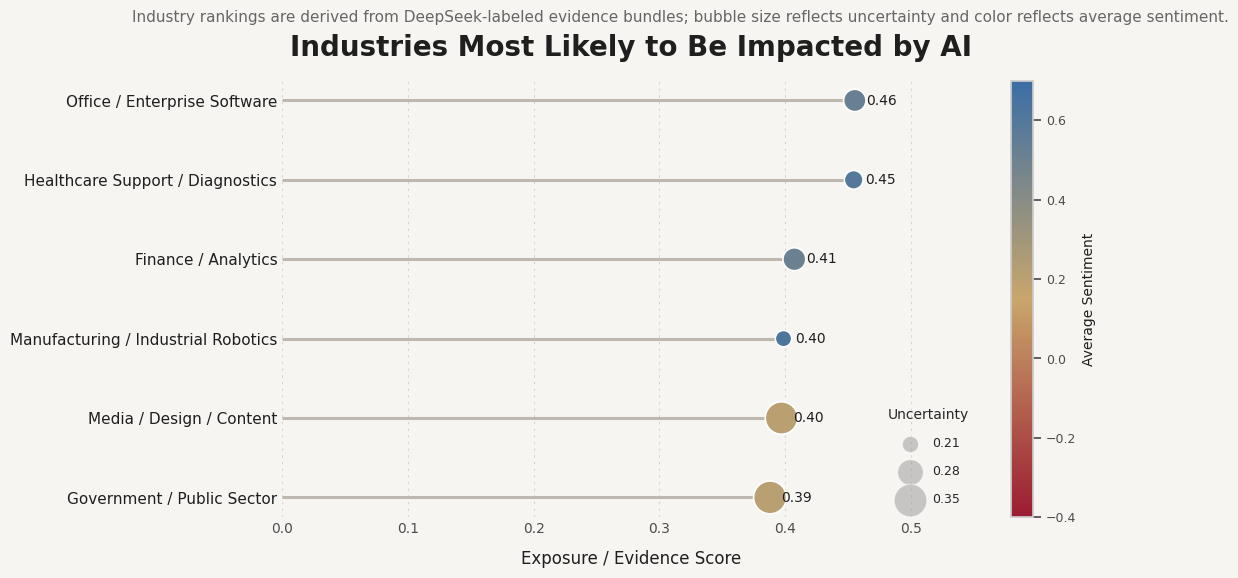

The strongest AI exposure signals are concentrated in Office / Enterprise Software, Healthcare Support / Diagnostics, and Finance / Analytics, where industry-labeled evidence bundles show dense company activity, enabling technologies, and sustained sentiment intensity.


,primary_industry,n_docs,n_rows,mean_confidence,avg_sentiment,avg_uncertainty,doc_share,confidence_weight,sentiment_strength,exposure_score
0,Office / Enterprise Software,2323,2323,0.821954,0.519080,0.251528,0.210150,0.821954,0.519080,0.455477
1,Healthcare Support / Diagnostics,1396,1396,0.908560,0.594420,0.226042,0.126289,0.908560,0.594420,0.454597
2,Finance / Analytics,1104,1104,0.849321,0.513366,0.255470,0.099873,0.849321,0.513366,0.407406
3,Manufacturing / Industrial Robotics,747,747,0.803548,0.619577,0.212251,0.067577,0.803548,0.619577,0.398768
4,Media / Design / Content,2118,2118,0.864589,0.209800,0.344868,0.191605,0.864589,0.209800,0.397139
5,Government / Public Sector,1963,1963,0.854814,0.214057,0.349885,0.177583,0.854814,0.214057,0.388047
6,Education / Knowledge Work,823,823,0.886391,0.377944,0.334805,0.074453,0.886391,0.377944,0.378733
7,Legal / Compliance,580,580,0.864483,-0.082138,0.361337,0.052470,0.864483,0.082138,0.302007


,Industry,Top Companies,Top Technologies,Avg Sentiment,Uncertainty
0,Office / Enterprise Software,"AEO Engine, Alchemyst AI, Jobma","Hybrid Search, Contextual Retrieval, Document AI",0.52,0.25
1,Healthcare Support / Diagnostics,"GN, Healio, Prismecs","Robotic General Surgery, Kernel Methods, HYFT Technology",0.59,0.23
2,Finance / Analytics,"Coginiti, Frogdata, MVSI","AML AI, Data Science Platform, AI MT4",0.51,0.26
3,Manufacturing / Industrial Robotics,"Bluecity, Mobilint, Passivelogic","APC, 3D Printing Technology, PID Control",0.62,0.21
4,Media / Design / Content,"AI Wonder Studios, Creatify, Lableb","DALL-E API, Autoshorts AI, 100% Colour Fidelity",0.21,0.34
5,Government / Public Sector,"Babel Street, Motorola Solutions, Havelsan","Omnilert AI Gun Detection Software, School Security Cameras, AI Detectors",0.21,0.35


In [98]:

# =========================================================
# Slide 25 — Aggregate ranking, evidence table, and chart
# =========================================================

df_labels = safe_read_parquet(LABELING_PARQUET)
assert not df_labels.empty, f'No labels found at {LABELING_PARQUET}'

df_labels['doc_id'] = pd.to_numeric(df_labels['doc_id'], errors='coerce').astype('Int64')
df_labels = df_labels.dropna(subset=['doc_id']).copy()

df_labeled = df_labels.loc[
    df_labels['primary_industry'].isin(LABELS) &
    (df_labels['primary_industry'] != 'Other / Unclear')
].copy()

industry_stats = (
    df_labeled
    .groupby('primary_industry', as_index=False)
    .agg(
        n_docs=('doc_id', 'nunique'),
        n_rows=('doc_id', 'size'),
        mean_confidence=('confidence', 'mean'),
        avg_sentiment=('sentiment_index', 'mean'),
        avg_uncertainty=('prob_mixed_or_unclear_mean', 'mean'),
    )
)
industry_stats['doc_share'] = industry_stats['n_docs'] / industry_stats['n_docs'].sum()
industry_stats['confidence_weight'] = industry_stats['mean_confidence']
industry_stats['sentiment_strength'] = industry_stats['avg_sentiment'].abs()
industry_stats['exposure_score'] = (
    0.50 * industry_stats['doc_share'] +
    0.30 * industry_stats['confidence_weight'] +
    0.20 * industry_stats['sentiment_strength']
)
industry_stats = industry_stats.sort_values('exposure_score', ascending=False).reset_index(drop=True)

# join labeled industries back to row-level evidence
_df_join_base = df.copy()
_df_join_base['doc_id'] = pd.to_numeric(_df_join_base['doc_id'], errors='coerce').astype('Int64')
_df_labeled_join = df_labeled[['doc_id', 'primary_industry']].drop_duplicates().copy()
_df_labeled_join['doc_id'] = pd.to_numeric(_df_labeled_join['doc_id'], errors='coerce').astype('Int64')

df_joined = _df_join_base.merge(_df_labeled_join, on='doc_id', how='inner')

top_companies = (
    df_joined.loc[df_joined['final_type'] == 'company']
    .groupby(['primary_industry', 'canonical_entity'], as_index=False)
    .size()
    .rename(columns={'size': 'n'})
    .sort_values(['primary_industry', 'n'], ascending=[True, False])
    .groupby('primary_industry', as_index=False)
    .head(3)
)

top_tech = (
    df_joined.loc[df_joined['final_type'] == 'technology']
    .groupby(['primary_industry', 'canonical_entity'], as_index=False)
    .size()
    .rename(columns={'size': 'n'})
    .sort_values(['primary_industry', 'n'], ascending=[True, False])
    .groupby('primary_industry', as_index=False)
    .head(3)
)

top_n_industries = 6
ranked_industries = industry_stats['primary_industry'].head(top_n_industries).tolist()

rows = []
for ind in ranked_industries:
    comps = top_companies.loc[top_companies['primary_industry'] == ind, 'canonical_entity'].tolist()
    techs = top_tech.loc[top_tech['primary_industry'] == ind, 'canonical_entity'].tolist()
    sent = industry_stats.loc[industry_stats['primary_industry'] == ind, 'avg_sentiment'].iloc[0]
    unc = industry_stats.loc[industry_stats['primary_industry'] == ind, 'avg_uncertainty'].iloc[0]
    rows.append({
        'Industry': ind,
        'Top Companies': ', '.join(comps[:3]),
        'Top Technologies': ', '.join(techs[:3]),
        'Avg Sentiment': round(float(sent), 2),
        'Uncertainty': round(float(unc), 2),
    })
slide25_table = pd.DataFrame(rows)
slide25_table.to_csv(EVIDENCE_TABLE_CSV, index=False)
print('Saved:', EVIDENCE_TABLE_CSV)

# Plot chart with color + bubble legends.
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

bg = '#F7F5F2'
text_dark = '#1F1F1F'
grid = '#D8D2C8'

plot_tbl = industry_stats.head(top_n_industries).copy()
plot_tbl = plot_tbl.sort_values('exposure_score', ascending=True).reset_index(drop=True)

cmap = mcolors.LinearSegmentedColormap.from_list(
    'sentiment_map',
    ['#9B1C31', '#C9A66B', '#3A6EA5']
)
vmin = min(-0.4, float(plot_tbl['avg_sentiment'].min()))
vmax = max(0.7, float(plot_tbl['avg_sentiment'].max()))
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

u_min = float(plot_tbl['avg_uncertainty'].min())
u_max = float(plot_tbl['avg_uncertainty'].max())
if u_max > u_min:
    bubble_sizes = 140 + 420 * (plot_tbl['avg_uncertainty'] - u_min) / (u_max - u_min)
else:
    bubble_sizes = np.repeat(240.0, len(plot_tbl))

fig, ax = plt.subplots(figsize=(11.2, 6.2), facecolor=bg)
ax.set_facecolor(bg)
y = np.arange(len(plot_tbl))
x = plot_tbl['exposure_score'].to_numpy()
for yi, xi in zip(y, x):
    ax.hlines(yi, 0, xi, color='#BFB8AE', linewidth=2.2, zorder=1)

sc = ax.scatter(
    x, y,
    s=bubble_sizes,
    c=plot_tbl['avg_sentiment'],
    cmap=cmap,
    norm=norm,
    edgecolor='white',
    linewidth=1.2,
    zorder=3
)
ax.set_yticks(y)
ax.set_yticklabels(plot_tbl['primary_industry'], fontsize=11, color=text_dark)
ax.set_xlabel('Exposure / Evidence Score', fontsize=12, color=text_dark, labelpad=10)
ax.set_title('Industries Most Likely to Be Impacted by AI', fontsize=20, fontweight='bold', color=text_dark, pad=18)
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)
ax.xaxis.grid(True, linestyle=(0, (2, 4)), linewidth=0.8, color=grid)
ax.yaxis.grid(False)
ax.set_axisbelow(True)
ax.tick_params(axis='x', labelsize=10, colors='#4D4D4D', length=0)
ax.tick_params(axis='y', length=0)

xmax = float(x.max())
ax.set_xlim(0, xmax * 1.22)
for yi, xi in zip(y, x):
    ax.text(xi + xmax * 0.02, yi, f'{xi:.2f}', va='center', ha='left', fontsize=10, color=text_dark)

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.04)
cbar.set_label('Average Sentiment', fontsize=10, color=text_dark)
cbar.ax.tick_params(labelsize=9, colors='#4D4D4D')

if u_max > u_min:
    size_vals = np.linspace(u_min, u_max, 3)
else:
    size_vals = np.array([u_min, u_min, u_min])
size_handles, size_labels = [], []
for val in size_vals:
    s = 140 + 420 * (val - u_min) / (u_max - u_min) if u_max > u_min else 240.0
    h = ax.scatter([], [], s=s, color='#9E9E9E', alpha=0.55, edgecolor='white', linewidth=1.0)
    size_handles.append(h)
    size_labels.append(f'{val:.2f}')
ax.legend(size_handles, size_labels, title='Uncertainty', loc='lower right', frameon=False, fontsize=9, title_fontsize=10, scatterpoints=1, labelspacing=1.2, borderpad=0.4)

fig.text(
    0.125,
    0.91,
    'Industry rankings are derived from DeepSeek-labeled evidence bundles; bubble size reflects uncertainty and color reflects average sentiment.',
    fontsize=11,
    color='#666666'
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(RANKING_PNG, dpi=300, bbox_inches='tight', facecolor=bg)
print('Saved:', RANKING_PNG)
plt.show()

summary_text = (
    f"The strongest AI exposure signals are concentrated in {industry_stats['primary_industry'].iloc[0]}, "
    f"{industry_stats['primary_industry'].iloc[1]}, and {industry_stats['primary_industry'].iloc[2]}, "
    f"where industry-labeled evidence bundles show dense company activity, enabling technologies, and sustained sentiment intensity."
)
print(summary_text)

display(industry_stats.head(10))
display(slide25_table)


Saved: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/figures/slide_26_mechanism_matrix.png


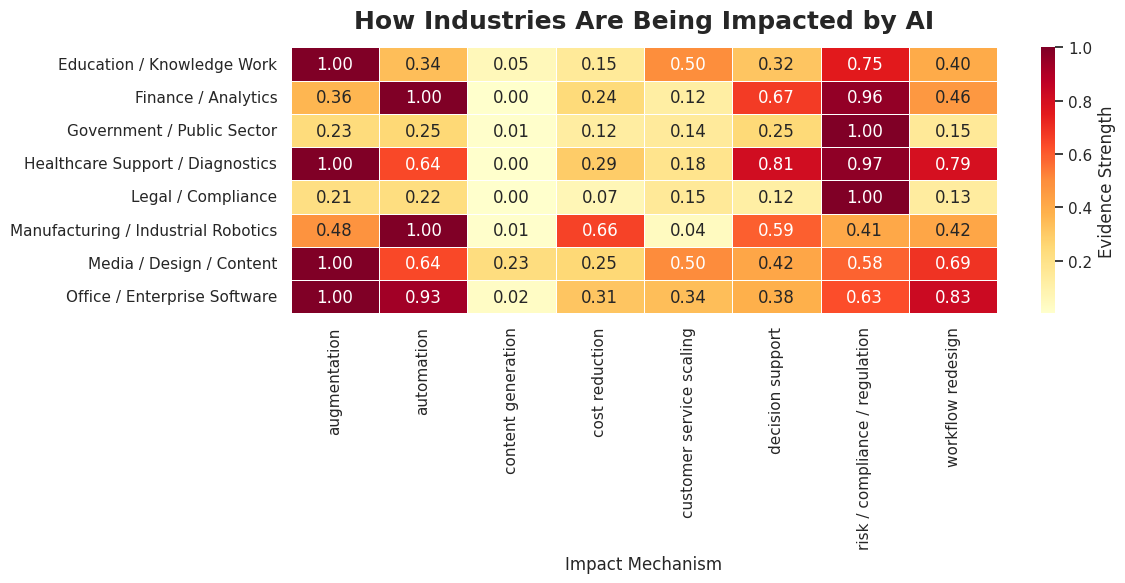

In [99]:
# =========================================================
# Slide 26 — Mechanism Matrix
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# mechanisms definition
mechanisms = {
    "automation": [
        "automate","automation","automated","replace workers","task automation"
    ],
    "augmentation": [
        "assist","copilot","augment","assistant","enhance productivity"
    ],
    "workflow redesign": [
        "workflow","process redesign","pipeline","integration","new workflow"
    ],
    "cost reduction": [
        "cost reduction","reduce costs","efficiency","productivity gains"
    ],
    "customer service scaling": [
        "customer support","chatbot","call center","service automation"
    ],
    "content generation": [
        "generate content","image generation","text generation","creative ai"
    ],
    "decision support": [
        "decision support","analytics","recommendation","predictive"
    ],
    "risk / compliance / regulation": [
        "regulation","compliance","risk","governance","policy"
    ],
}

# restrict to labeled industries
df_mech = df_joined.copy()

# evidence counting
records = []

for industry in df_mech["primary_industry"].unique():

    subset = df_mech[df_mech["primary_industry"] == industry]

    texts = subset["context_text"].str.lower().fillna("")

    for mech, keywords in mechanisms.items():

        count = 0

        for kw in keywords:
            count += texts.str.contains(kw, regex=False).sum()

        records.append({
            "industry": industry,
            "mechanism": mech,
            "evidence": count
        })

mech_df = pd.DataFrame(records)

# normalize evidence strength
mech_df["strength"] = mech_df.groupby("industry")["evidence"].transform(
    lambda x: x / x.max() if x.max() > 0 else x
)

matrix = mech_df.pivot(
    index="industry",
    columns="mechanism",
    values="strength"
).fillna(0)

# -----------------------------
# Plot heatmap
# -----------------------------
plt.figure(figsize=(12,6))

sns.heatmap(
    matrix,
    cmap="YlOrRd",
    linewidths=0.5,
    annot=True,
    fmt=".2f",
    cbar_kws={"label":"Evidence Strength"}
)

plt.title(
    "How Industries Are Being Impacted by AI",
    fontsize=18,
    weight="bold",
    pad=14
)

plt.ylabel("")
plt.xlabel("Impact Mechanism")

plt.tight_layout()

MECH_PNG = "/content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/presentation_assets/figures/slide_26_mechanism_matrix.png"

plt.savefig(MECH_PNG, dpi=300)
print("Saved:", MECH_PNG)

plt.show()